In [1]:
import pandas as pd
from collections import OrderedDict

# Read all sheets from the Excel file into a dictionary
xls = pd.read_excel('MASTER_DF_final.xlsx', sheet_name=None)

# View all available sheet names
sheet_names = list(xls.keys())
print("Sheets found:", sheet_names)

# Dictionary to store OrderedDicts for each trial
ordered_data_by_sheet = OrderedDict()

# Access each sheet individually and convert rows to OrderedDict
df_trial1 = xls.get('Trial1')
df_trial2 = xls.get('Trial2')
df_trial3 = xls.get('Trial3')
df_trial4 = xls.get('Trial4')
df_trial5 = xls.get('Trial5')
df_trial6 = xls.get('Trial6')
df_trial7 = xls.get('Trial7')
df_trial8 = xls.get('Trial8')
df_trial9 = xls.get('Trial9')
df_trial10 = xls.get('Trial10')
df_trial11 = xls.get('Trial11')

# Manually list trials you want to convert
trial_dfs = {
    'Trial1': df_trial1,
    'Trial2': df_trial2,
    'Trial3': df_trial3,
    'Trial4': df_trial4,
    'Trial5': df_trial5,
    'Trial6': df_trial6,
    'Trial7': df_trial7,
    'Trial8': df_trial8,
    'Trial9': df_trial9,
    'Trial10': df_trial10,
    'Trial11': df_trial11
}

# Convert each DataFrame row into OrderedDict and store
for sheet_name, df in trial_dfs.items():
    if df is not None:
        records = [OrderedDict(row.items()) for _, row in df.iterrows()]
        ordered_data_by_sheet[sheet_name] = records


'''
# Optional: print a preview
for sheet, records in ordered_data_by_sheet.items():
    print(f"\nSheet: {sheet}")
    for i, row in enumerate(records[:2]):  # preview first 2 rows per sheet
        print(f" Row {i+1}: {row}")
'''

Sheets found: ['Trial1', 'Trial2', 'Trial3', 'Trial4', 'Trial5', 'Trial6', 'Trial7', 'Trial8', 'Trial9', 'Trial10', 'Trial11']


'\n# Optional: print a preview\nfor sheet, records in ordered_data_by_sheet.items():\n    print(f"\nSheet: {sheet}")\n    for i, row in enumerate(records[:2]):  # preview first 2 rows per sheet\n        print(f" Row {i+1}: {row}")\n'

In [2]:
# Master excel sheet
master = OrderedDict()

for trial_key in ordered_data_by_sheet:
    trial_data = ordered_data_by_sheet[trial_key]
    if trial_key not in master:
        master[trial_key] = OrderedDict()

    for row in trial_data:
        if row.get('Treatment') != 'T4':
            continue

        date = row.get('Date')
        plot_name = row.get('Name of plot')

        if not date or not plot_name:
            continue

        if date not in master[trial_key]:
            master[trial_key][date] = OrderedDict()

        # Build the required output values
        values = OrderedDict({
            #'Plant_H': row.get('Plant height'),
            'PDI_SB_new': row.get('PDI_SB_new'),
            'new_thrips': row.get('new_thrips'),
            'PDI_PB_new': row.get('PDI_PB_new'),
            'PDI_AN_new': row.get('PDI_AN_new')
        })

        master[trial_key][date][plot_name] = values

print (master['Trial1'])

OrderedDict({'28/08/2023': OrderedDict({'R1T4': OrderedDict({'PDI_SB_new': 0, 'new_thrips': 56.5, 'PDI_PB_new': 0, 'PDI_AN_new': 0}), 'R2T4': OrderedDict({'PDI_SB_new': 0, 'new_thrips': 61.1, 'PDI_PB_new': 0, 'PDI_AN_new': 0}), 'R3T4': OrderedDict({'PDI_SB_new': 0, 'new_thrips': 58.4, 'PDI_PB_new': 0, 'PDI_AN_new': 0})}), '07/09/2023': OrderedDict({'R1T4': OrderedDict({'PDI_SB_new': 4, 'new_thrips': 100.7, 'PDI_PB_new': 0, 'PDI_AN_new': 4}), 'R2T4': OrderedDict({'PDI_SB_new': 4, 'new_thrips': 61.6, 'PDI_PB_new': 2, 'PDI_AN_new': 0}), 'R3T4': OrderedDict({'PDI_SB_new': 6, 'new_thrips': 103.8, 'PDI_PB_new': 6, 'PDI_AN_new': 2})}), '14/09/2023': OrderedDict({'R1T4': OrderedDict({'PDI_SB_new': 20, 'new_thrips': 44.8, 'PDI_PB_new': 18, 'PDI_AN_new': 16}), 'R2T4': OrderedDict({'PDI_SB_new': 16, 'new_thrips': 38.8, 'PDI_PB_new': 16, 'PDI_AN_new': 14}), 'R3T4': OrderedDict({'PDI_SB_new': 14, 'new_thrips': 46.3, 'PDI_PB_new': 20, 'PDI_AN_new': 16})}), '25/09/2023': OrderedDict({'R1T4': OrderedD

In [3]:
from collections import OrderedDict

height_dict = OrderedDict()

for trial_key, trial_data in ordered_data_by_sheet.items():
    trial_dict = height_dict.setdefault(trial_key, OrderedDict())

    for row in trial_data:
        if row.get('Treatment') != 'T4':
            continue

        date = row.get('Date')
        plot_name = row.get('Name of plot')
        if not date or not plot_name:
            continue

        date_dict = trial_dict.setdefault(date, OrderedDict())

        # Choose available height key
        height_val = row.get('Plant height') or row.get('Plant height (cm)')
        date_dict[plot_name] = OrderedDict({'Plant_H': height_val})

# Print Trial5 results
print(height_dict['Trial6'])

OrderedDict({'20/10/2023': OrderedDict({'R1T4': OrderedDict({'Plant_H': 14.3}), 'R2T4': OrderedDict({'Plant_H': 18.45}), 'R3T4': OrderedDict({'Plant_H': 15.86})}), '30/10/2023': OrderedDict({'R1T4': OrderedDict({'Plant_H': 12.6}), 'R2T4': OrderedDict({'Plant_H': 16.4}), 'R3T4': OrderedDict({'Plant_H': 28.2})}), '09/11/2023': OrderedDict({'R1T4': OrderedDict({'Plant_H': 30.86}), 'R2T4': OrderedDict({'Plant_H': 35.16}), 'R3T4': OrderedDict({'Plant_H': 33.33})}), '16/11/2023': OrderedDict({'R1T4': OrderedDict({'Plant_H': 41.66}), 'R2T4': OrderedDict({'Plant_H': 43.66}), 'R3T4': OrderedDict({'Plant_H': 45.3})}), '25/11/2023': OrderedDict({'R1T4': OrderedDict({'Plant_H': 55.93}), 'R2T4': OrderedDict({'Plant_H': 53.35}), 'R3T4': OrderedDict({'Plant_H': 55.54})}), '01/12/2023': OrderedDict({'R1T4': OrderedDict({'Plant_H': 53.29}), 'R2T4': OrderedDict({'Plant_H': 47.78}), 'R3T4': OrderedDict({'Plant_H': 49.37})}), '14/12/2023': OrderedDict({'R1T4': OrderedDict({'Plant_H': 55.02}), 'R2T4': Orde

In [4]:
from collections import OrderedDict
from datetime import datetime

combined_data = OrderedDict()

for trial_name in master:
    combined_data[trial_name] = OrderedDict()

    for date_str in master[trial_name]:
        date_obj = datetime.strptime(date_str, "%d/%m/%Y")  # convert to datetime
        for region in master[trial_name][date_str]:
            values = master[trial_name][date_str][region]
            plant_height = None

            # Get plant height from height_dict if exists
            try:
                plant_height = height_dict[trial_name][date_str][region].get('Plant_H')
            except KeyError:
                continue  # skip if height data is missing

            if region not in combined_data[trial_name]:
                combined_data[trial_name][region] = []

            # Create separate records for each attribute with Plant_H
            for attr in ['PDI_SB_new', 'new_thrips', 'PDI_PB_new', 'PDI_AN_new']:
                val = values.get(attr)
                if val is not None:
                    record = {
                        'Date': date_obj,
                        attr: val,
                        'Plant_H': plant_height
                    }
                    combined_data[trial_name][region].append(record)
print (combined_data['Trial1']['R1T4'])

[{'Date': datetime.datetime(2023, 8, 28, 0, 0), 'PDI_SB_new': 0, 'Plant_H': 47.61}, {'Date': datetime.datetime(2023, 8, 28, 0, 0), 'new_thrips': 56.5, 'Plant_H': 47.61}, {'Date': datetime.datetime(2023, 8, 28, 0, 0), 'PDI_PB_new': 0, 'Plant_H': 47.61}, {'Date': datetime.datetime(2023, 8, 28, 0, 0), 'PDI_AN_new': 0, 'Plant_H': 47.61}, {'Date': datetime.datetime(2023, 9, 7, 0, 0), 'PDI_SB_new': 4, 'Plant_H': 44.34}, {'Date': datetime.datetime(2023, 9, 7, 0, 0), 'new_thrips': 100.7, 'Plant_H': 44.34}, {'Date': datetime.datetime(2023, 9, 7, 0, 0), 'PDI_PB_new': 0, 'Plant_H': 44.34}, {'Date': datetime.datetime(2023, 9, 7, 0, 0), 'PDI_AN_new': 4, 'Plant_H': 44.34}, {'Date': datetime.datetime(2023, 9, 14, 0, 0), 'PDI_SB_new': 20, 'Plant_H': 42.65}, {'Date': datetime.datetime(2023, 9, 14, 0, 0), 'new_thrips': 44.8, 'Plant_H': 42.65}, {'Date': datetime.datetime(2023, 9, 14, 0, 0), 'PDI_PB_new': 18, 'Plant_H': 42.65}, {'Date': datetime.datetime(2023, 9, 14, 0, 0), 'PDI_AN_new': 16, 'Plant_H': 42

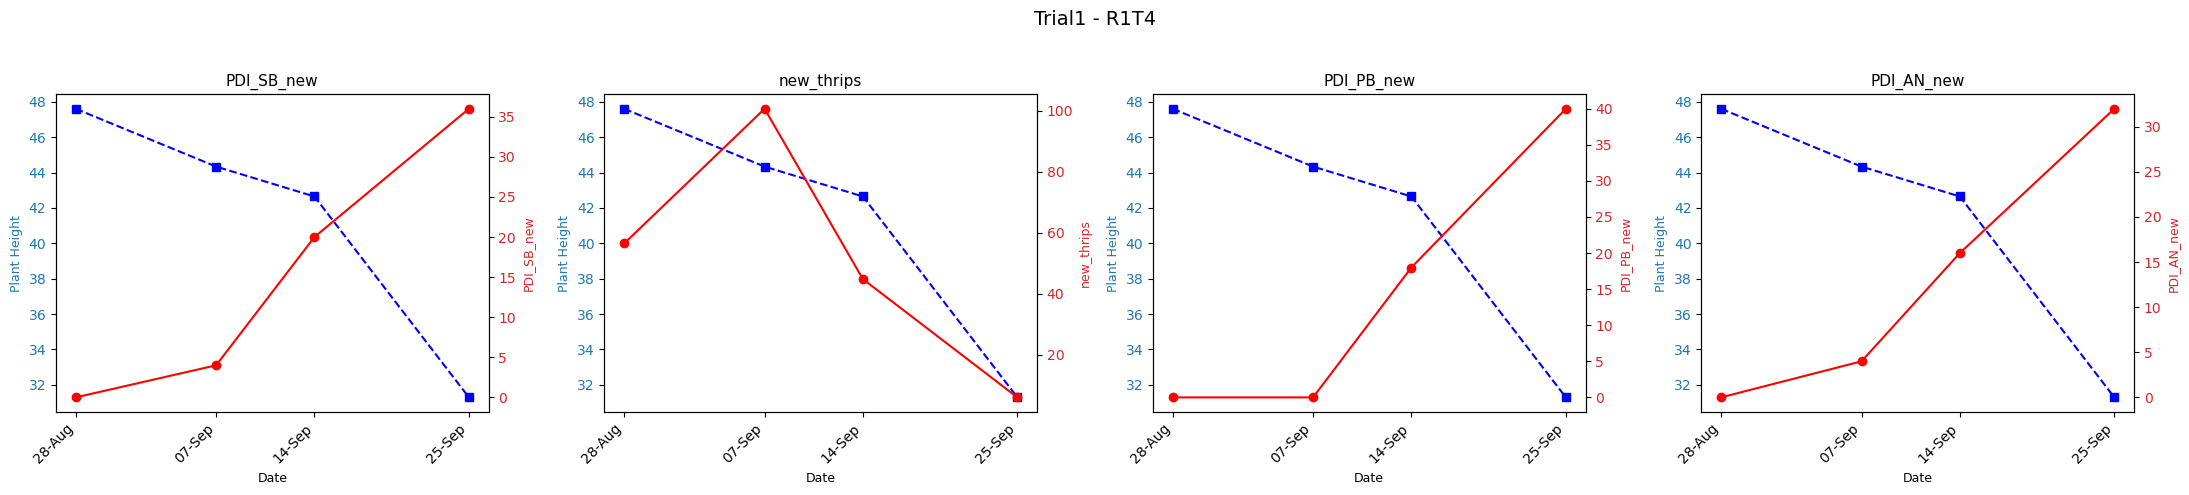

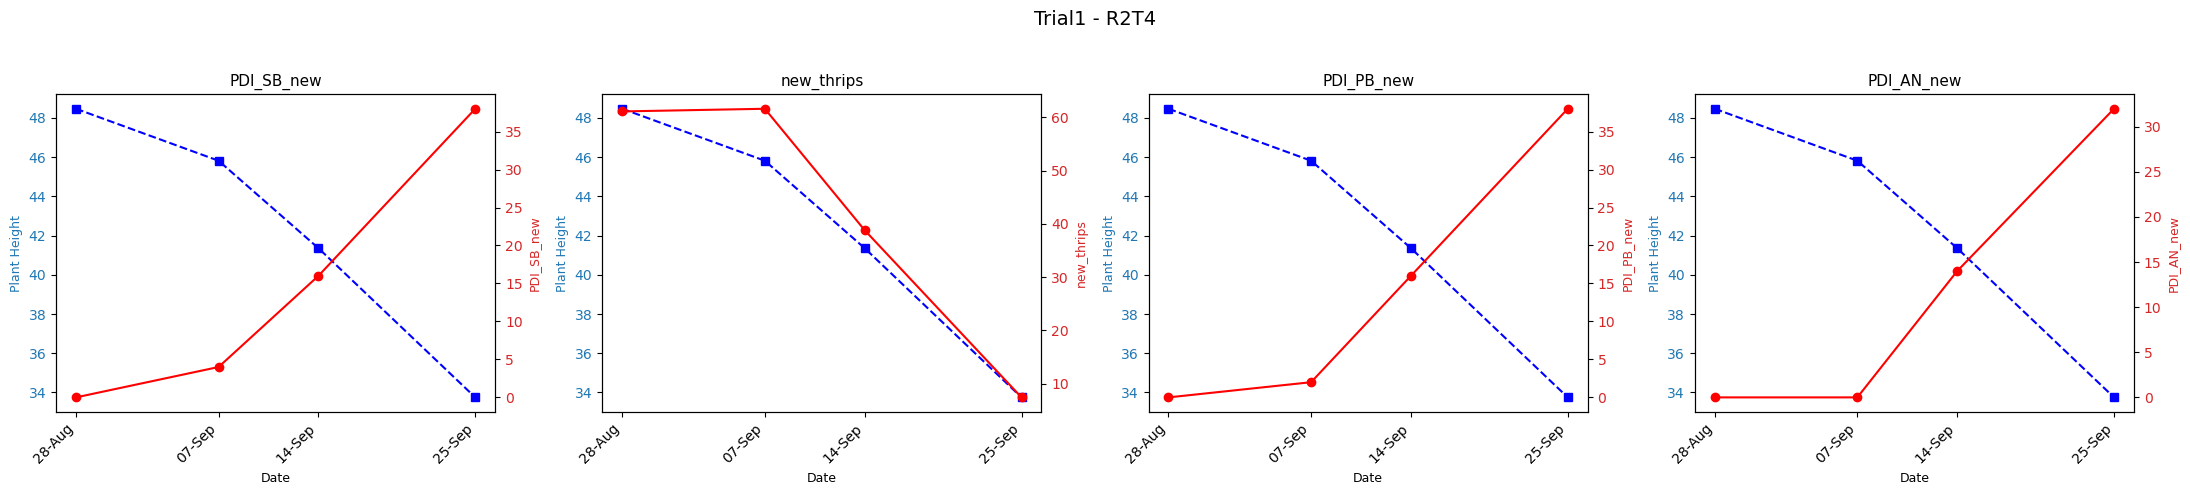

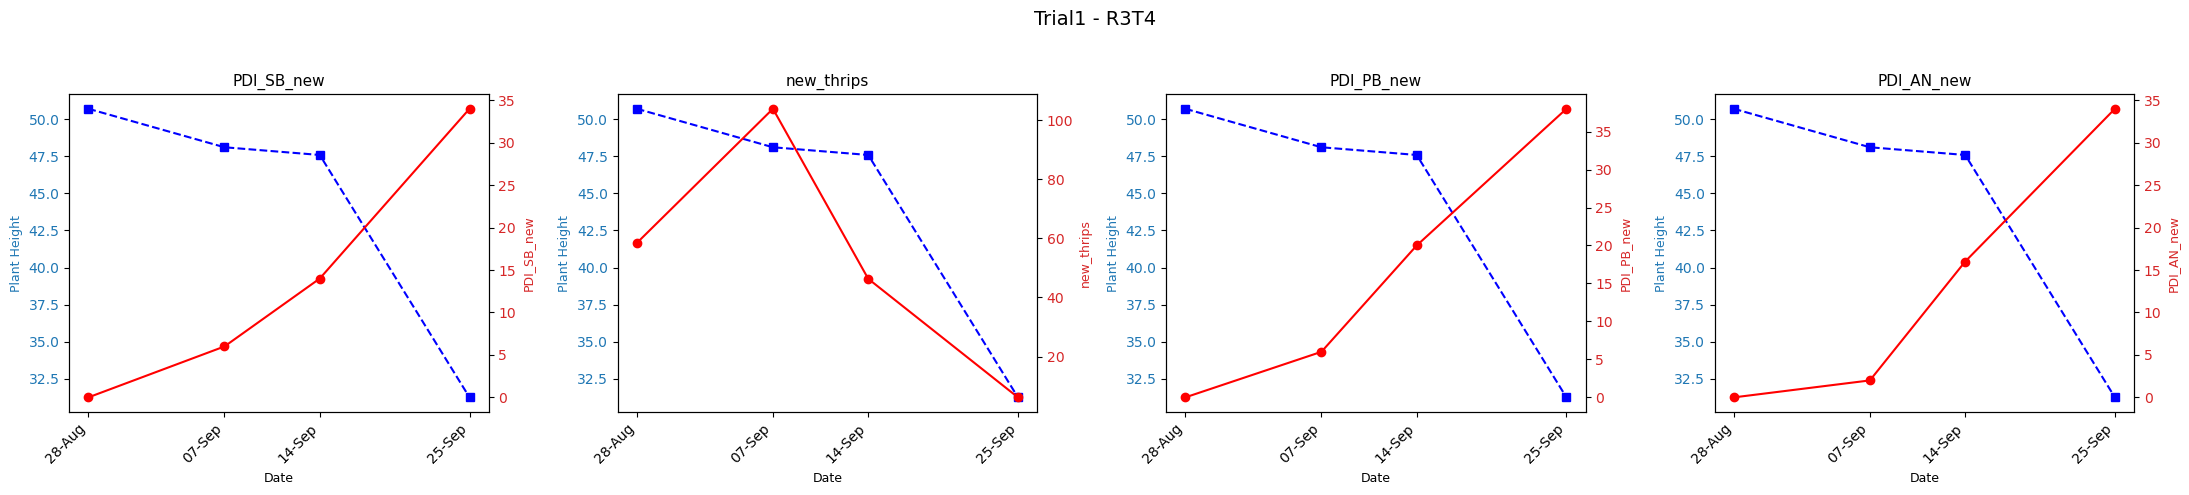

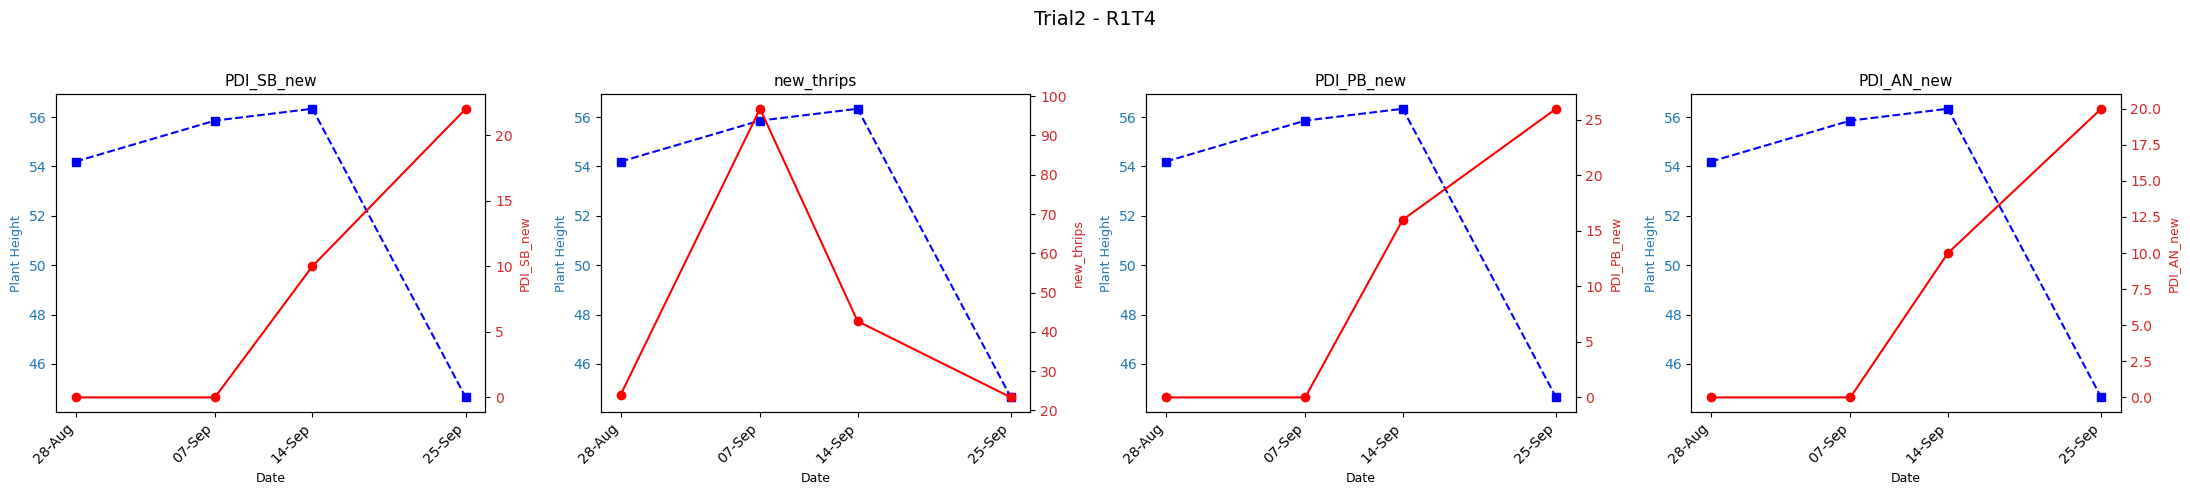

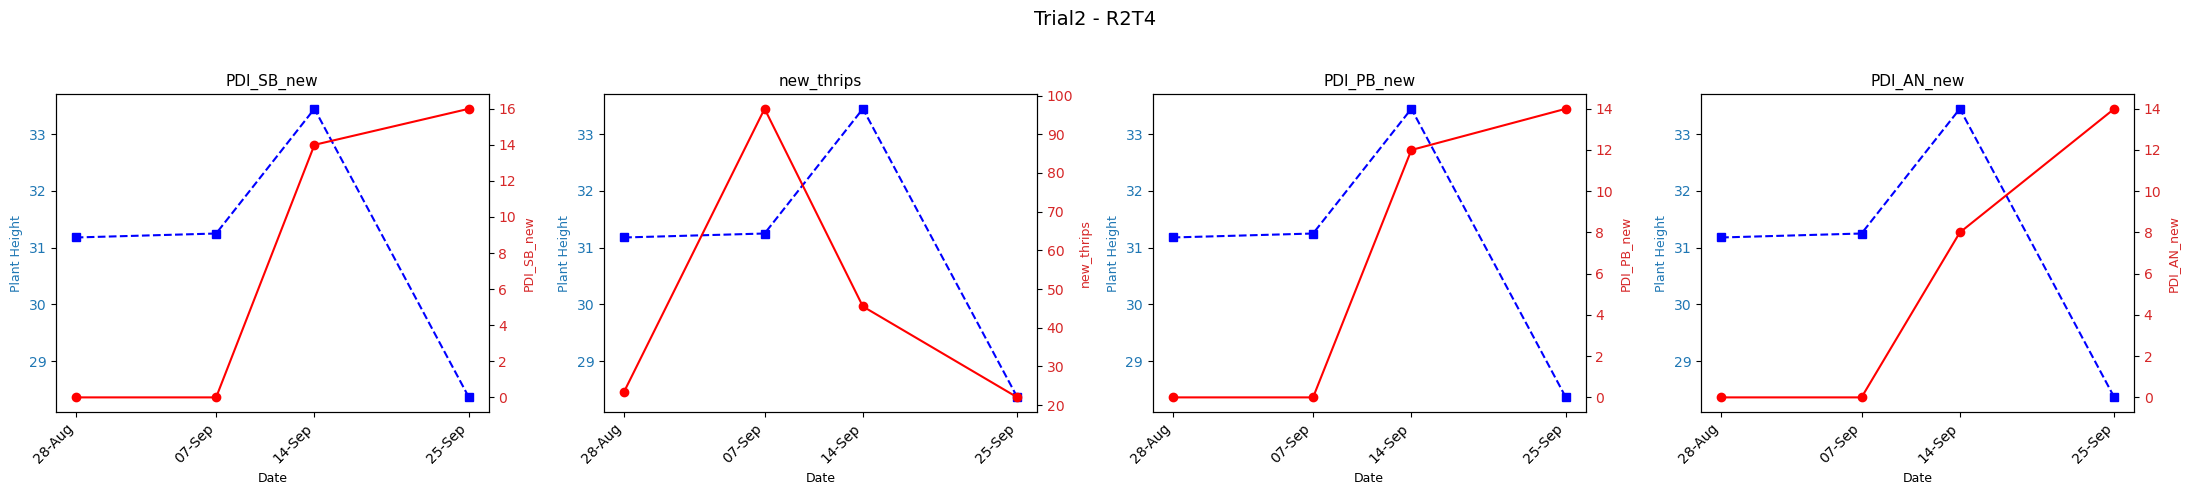

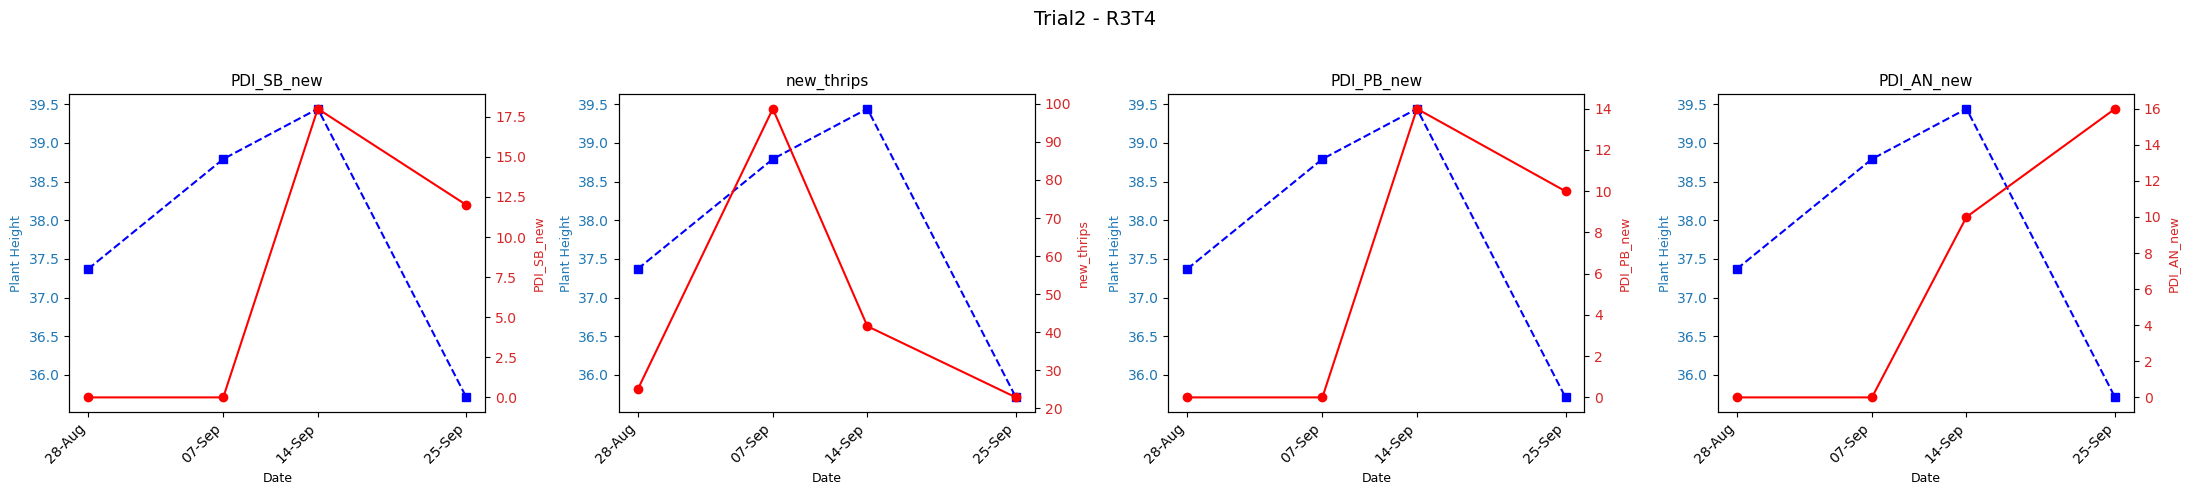

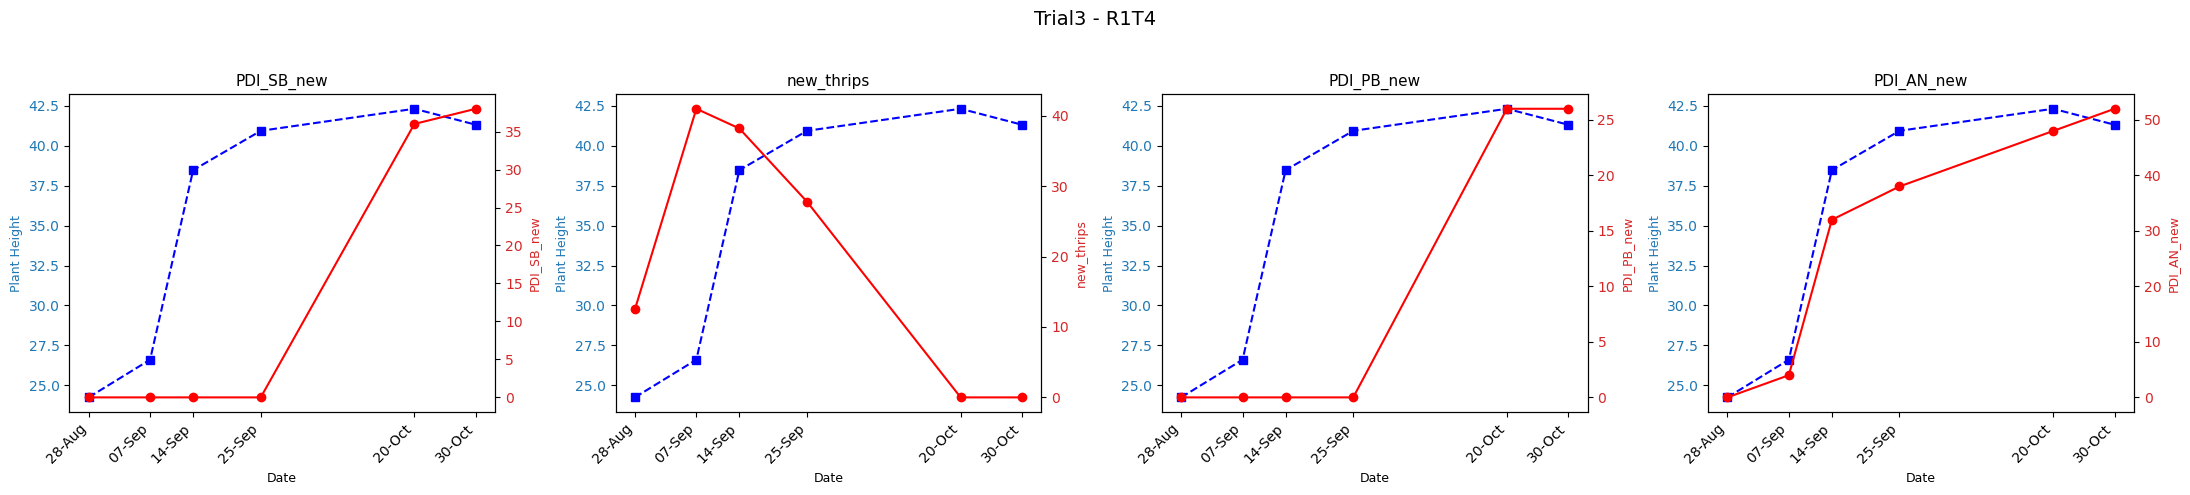

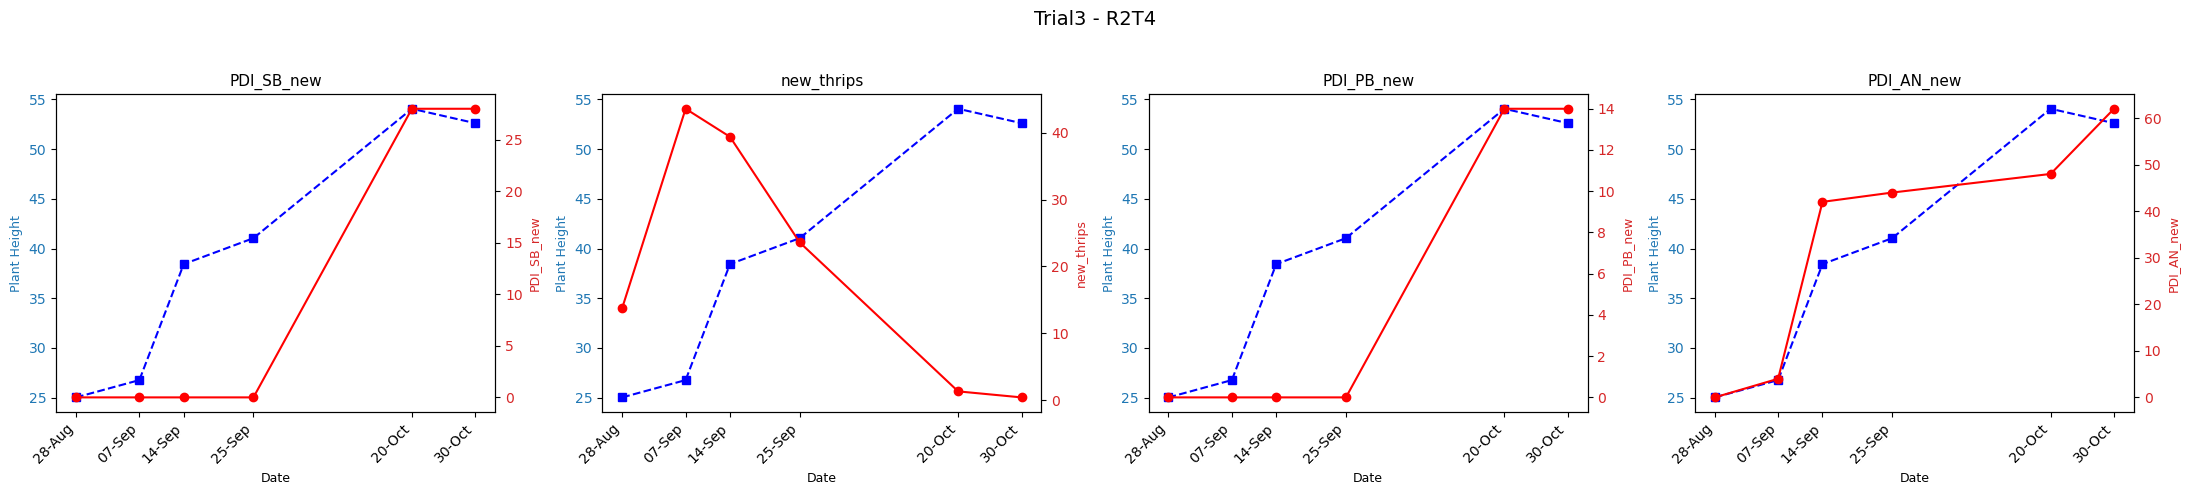

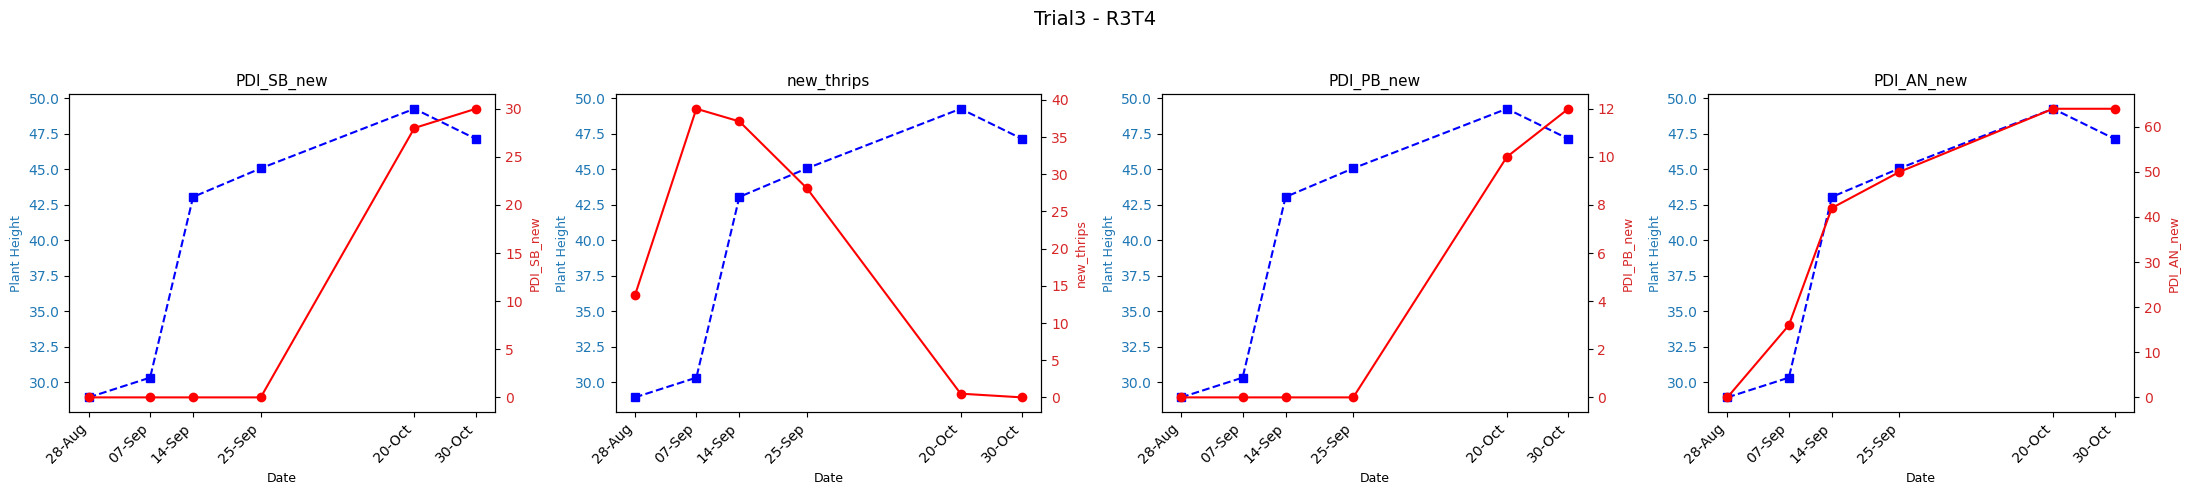

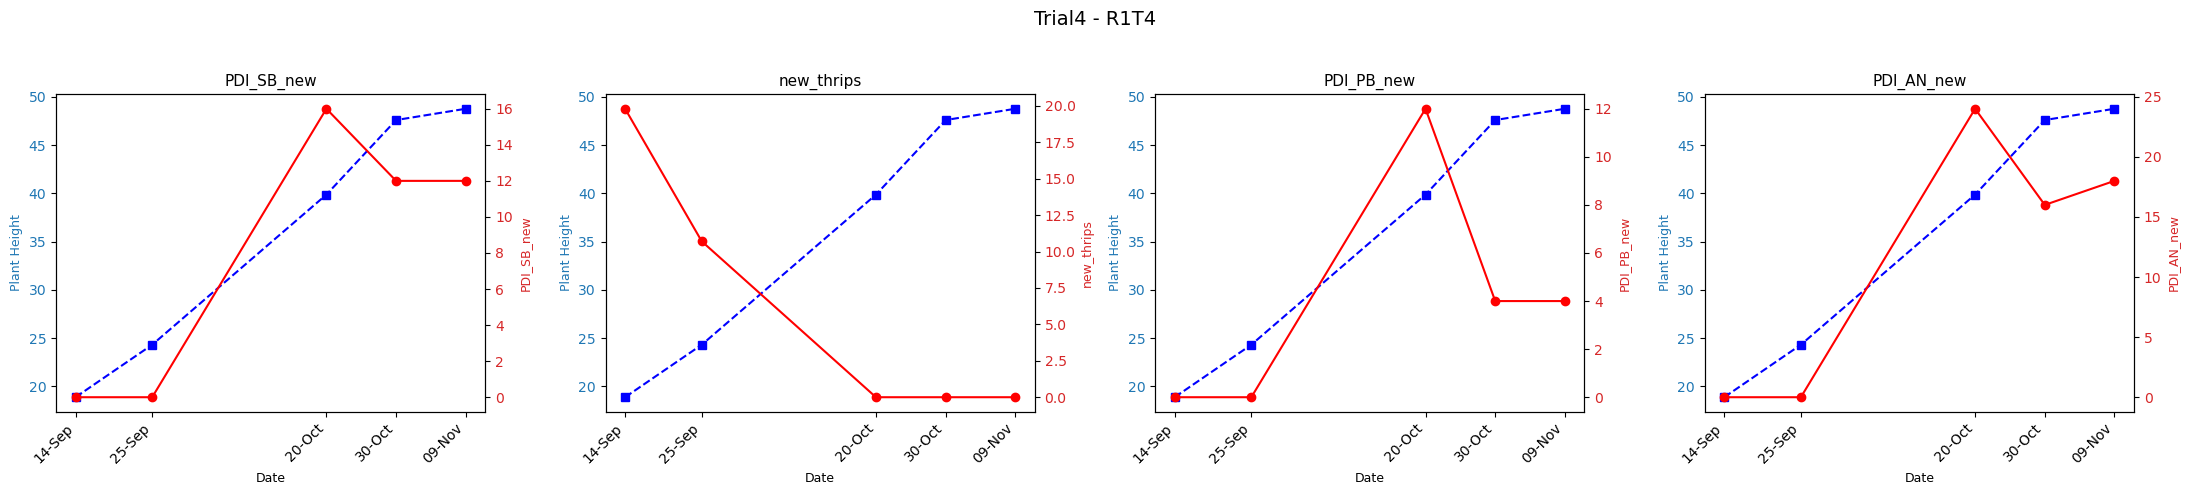

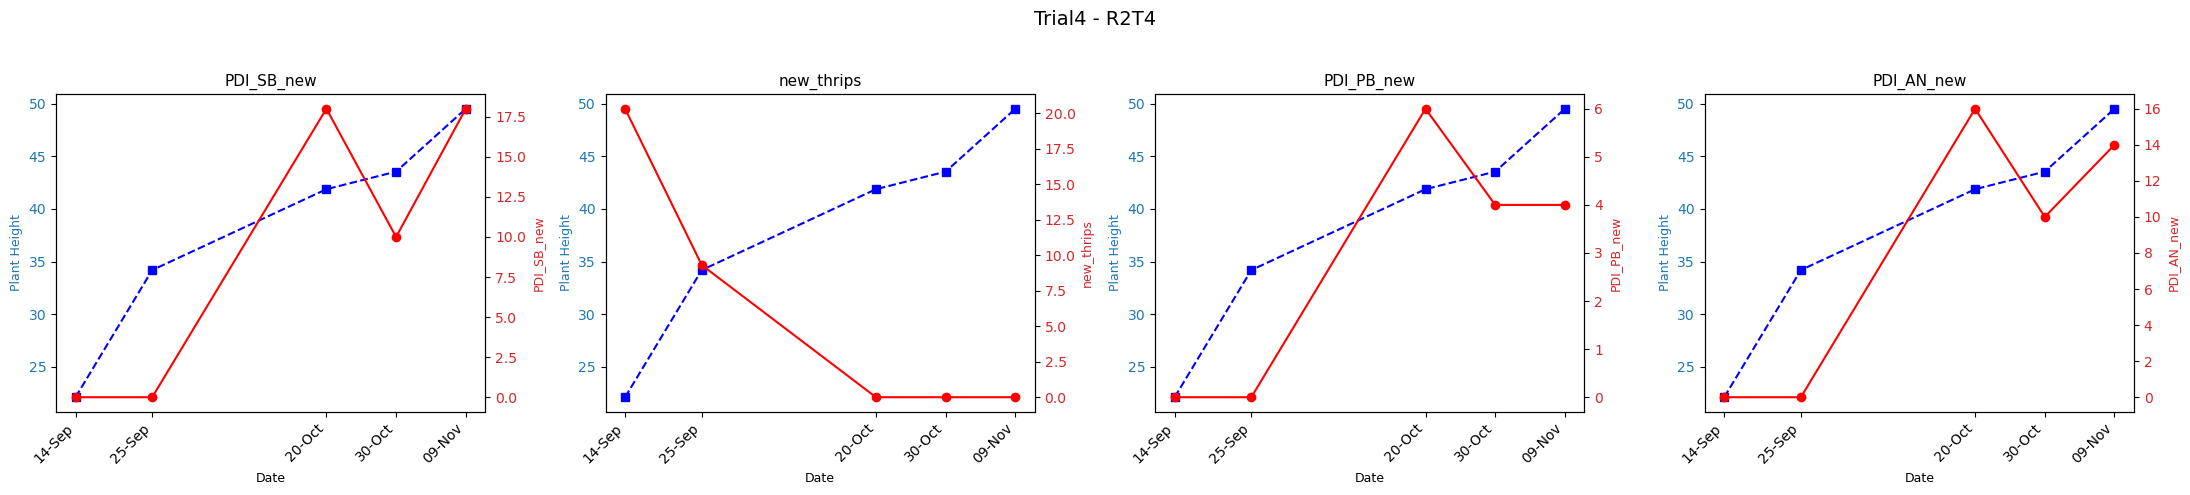

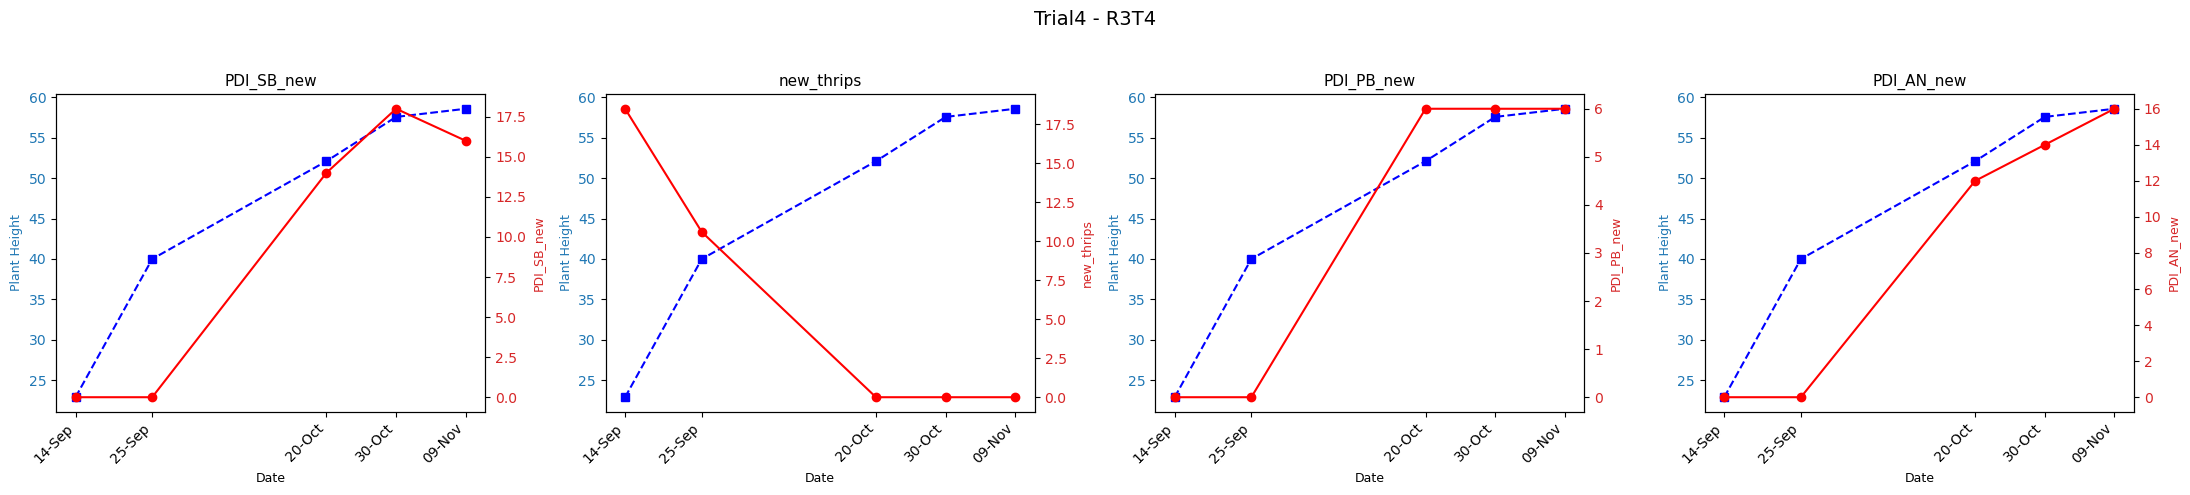

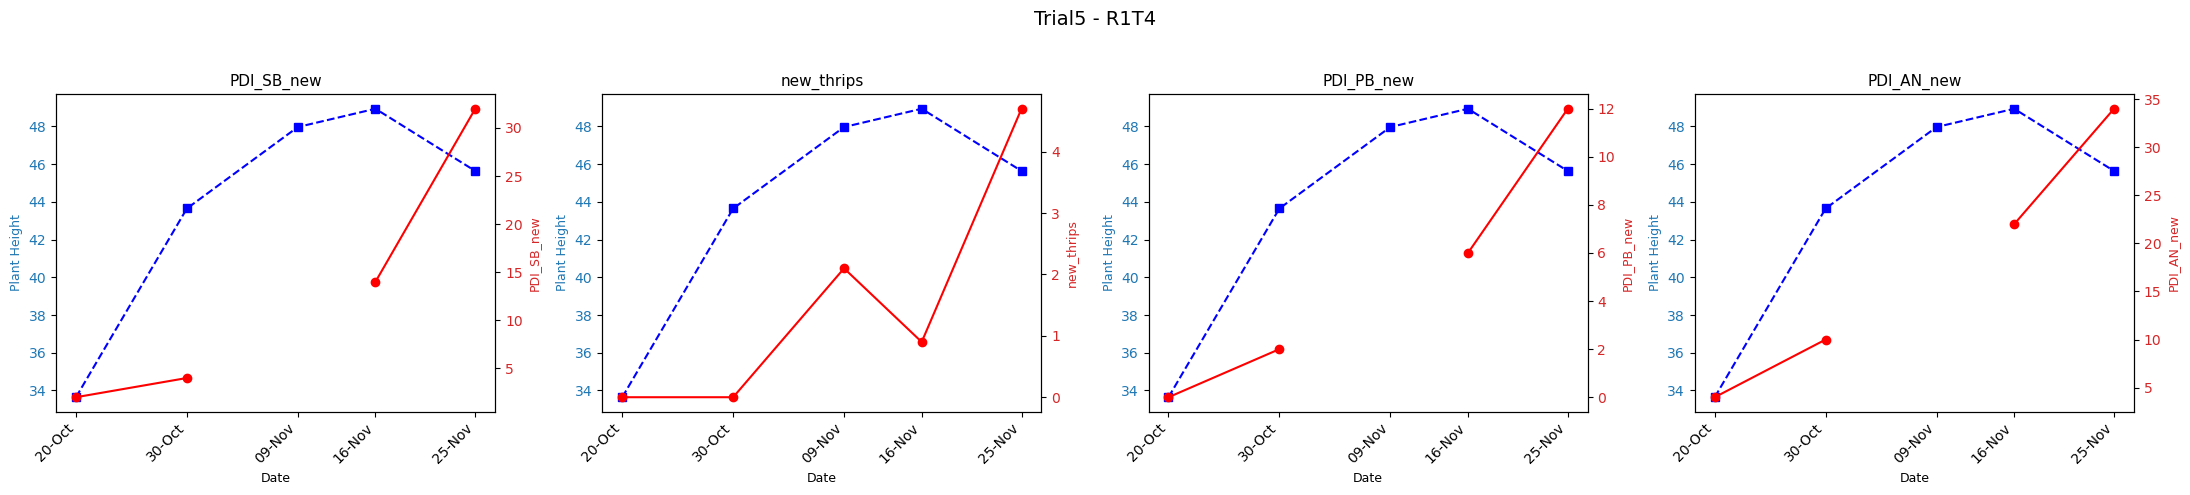

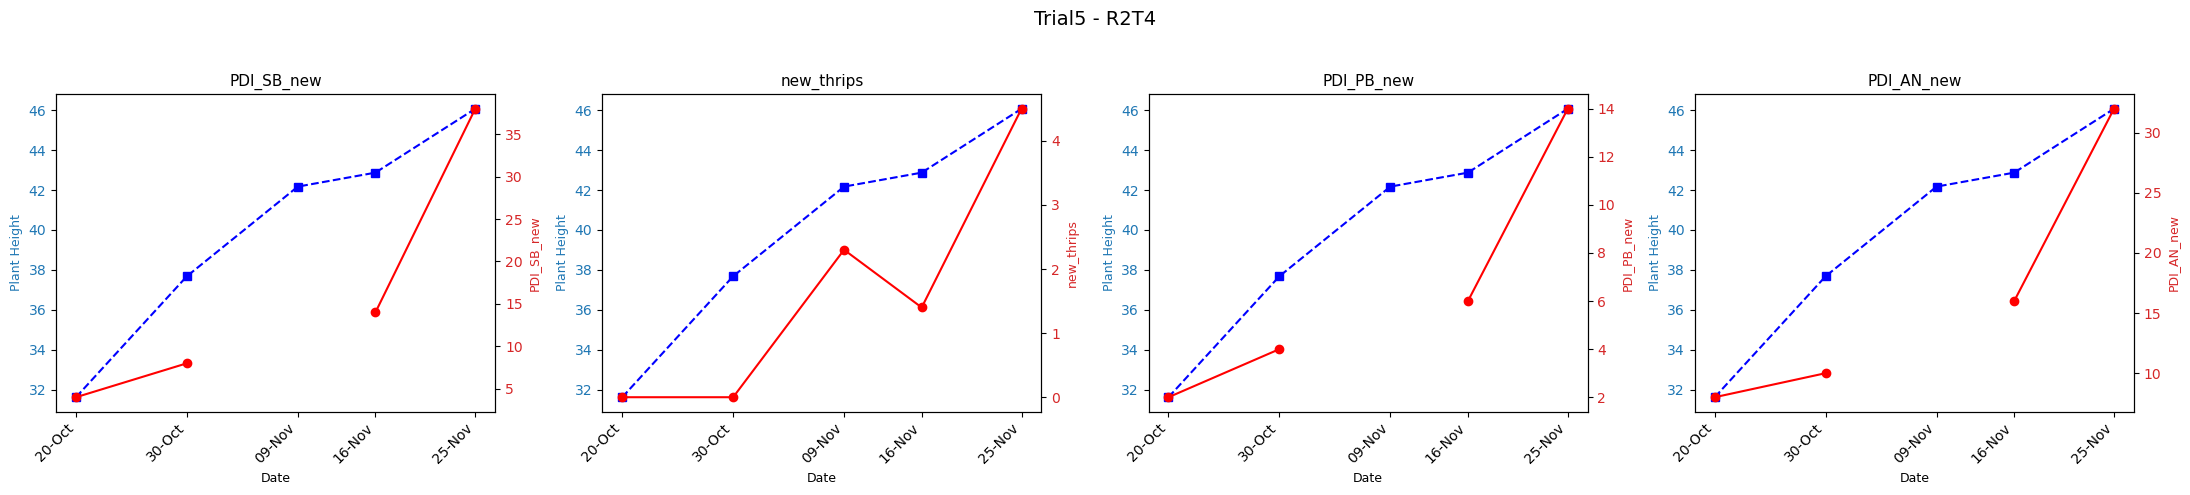

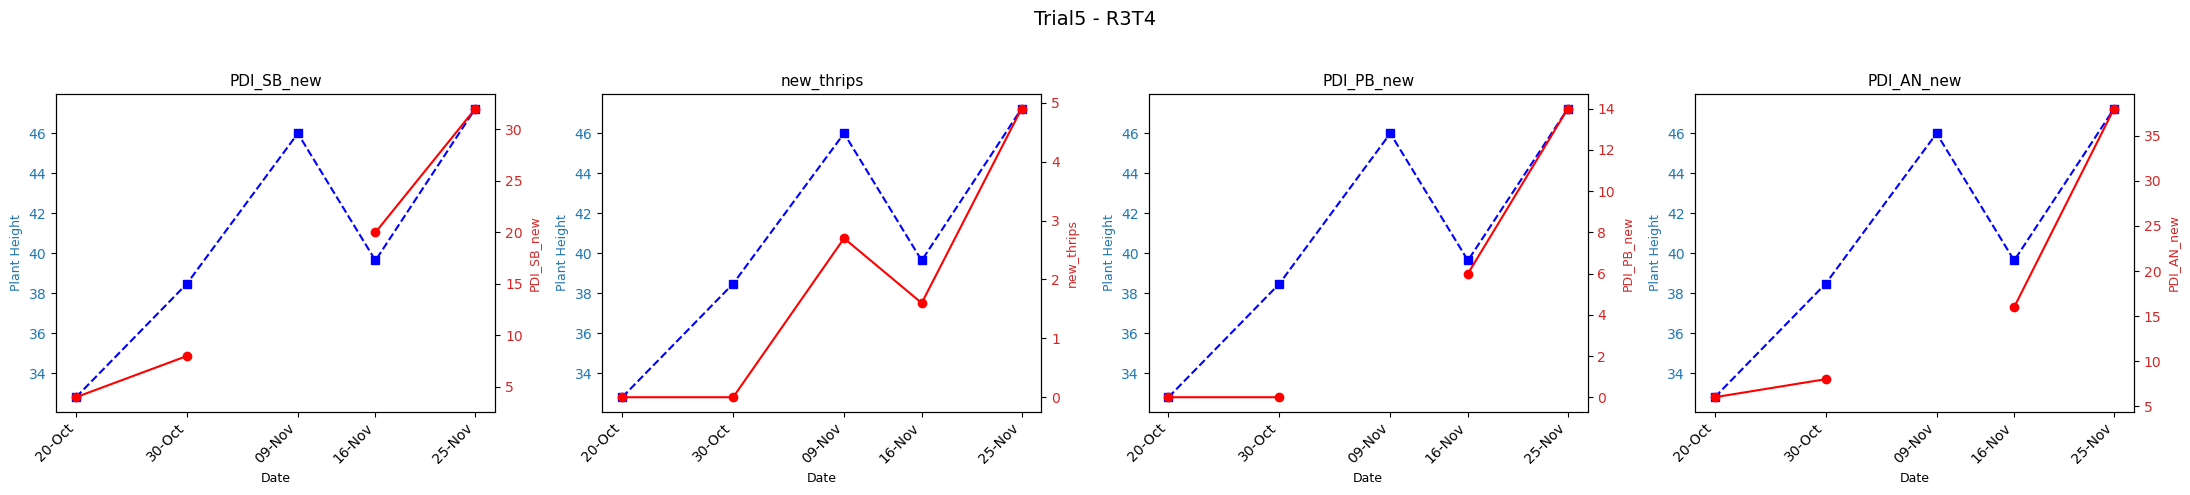

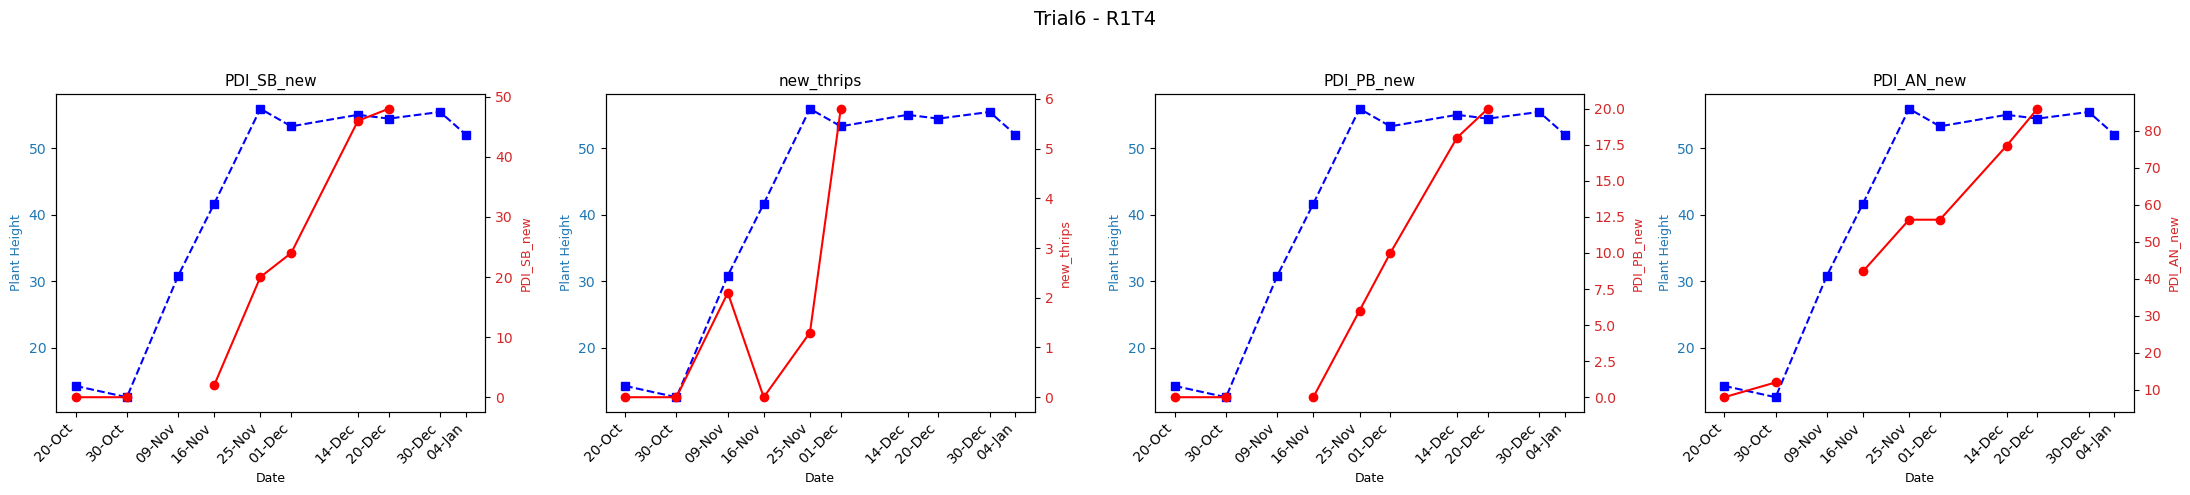

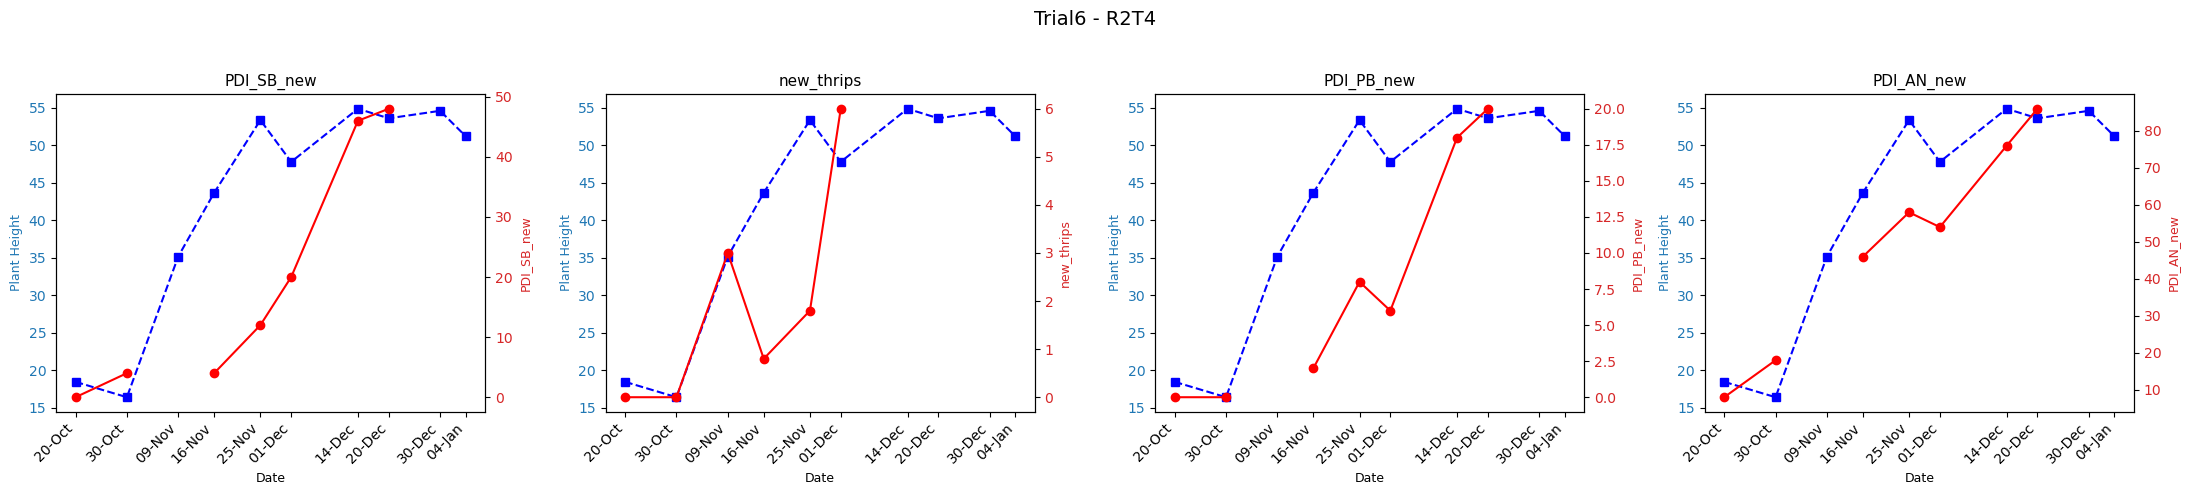

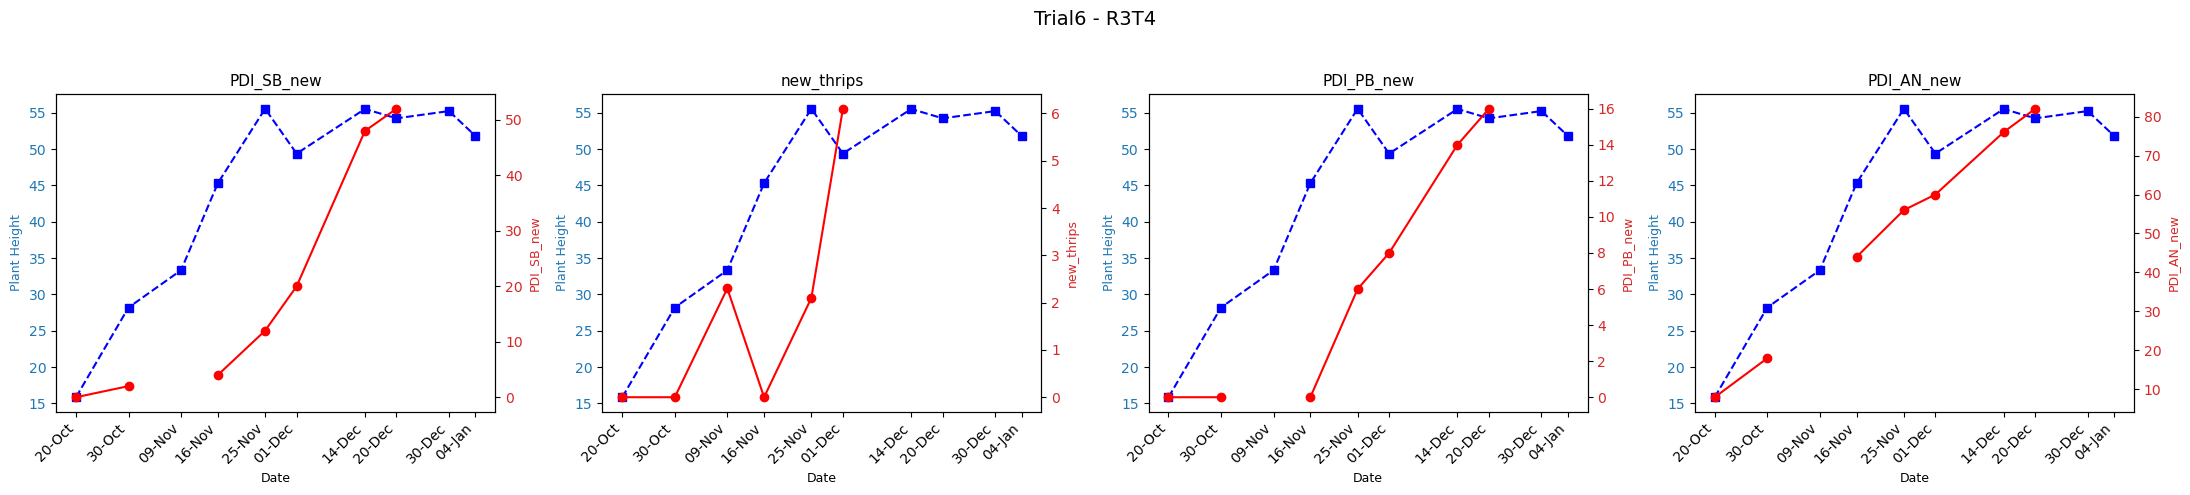

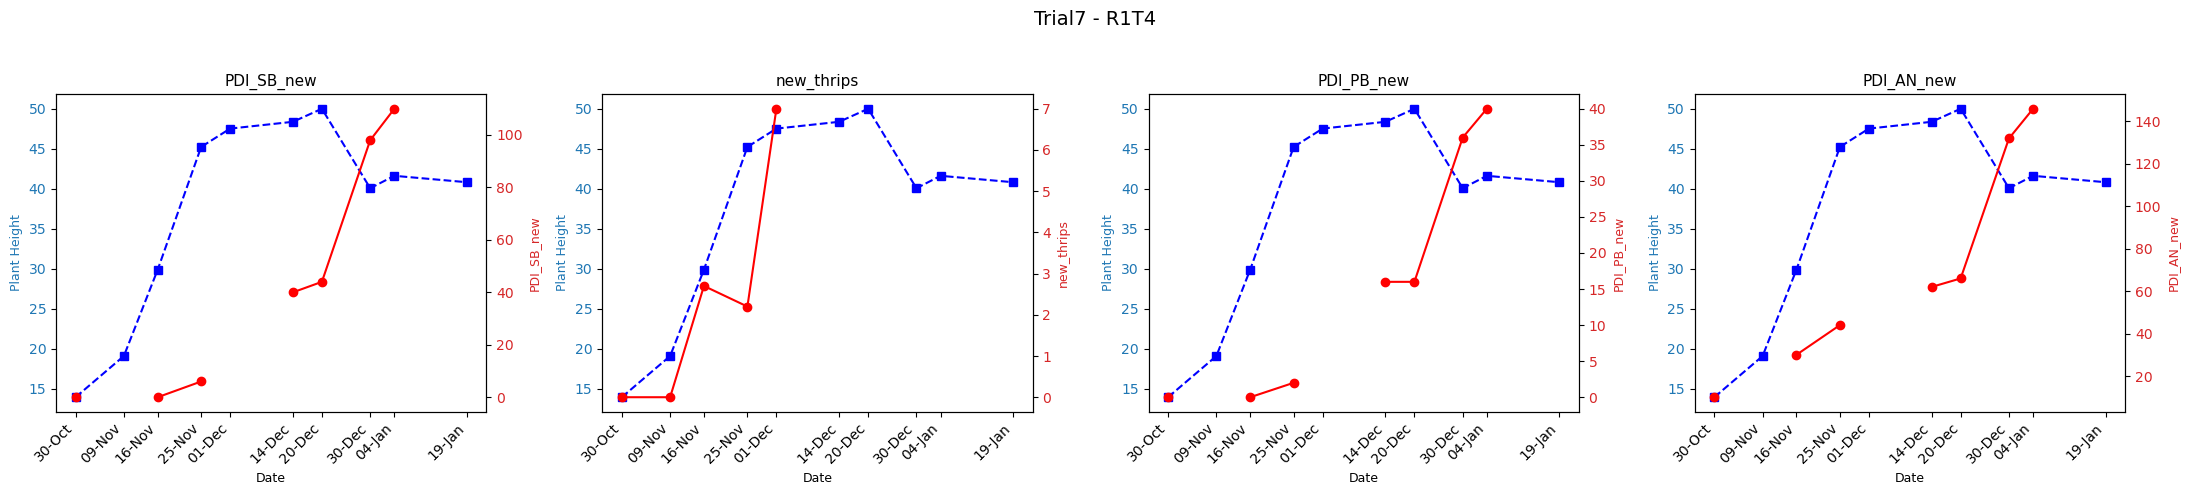

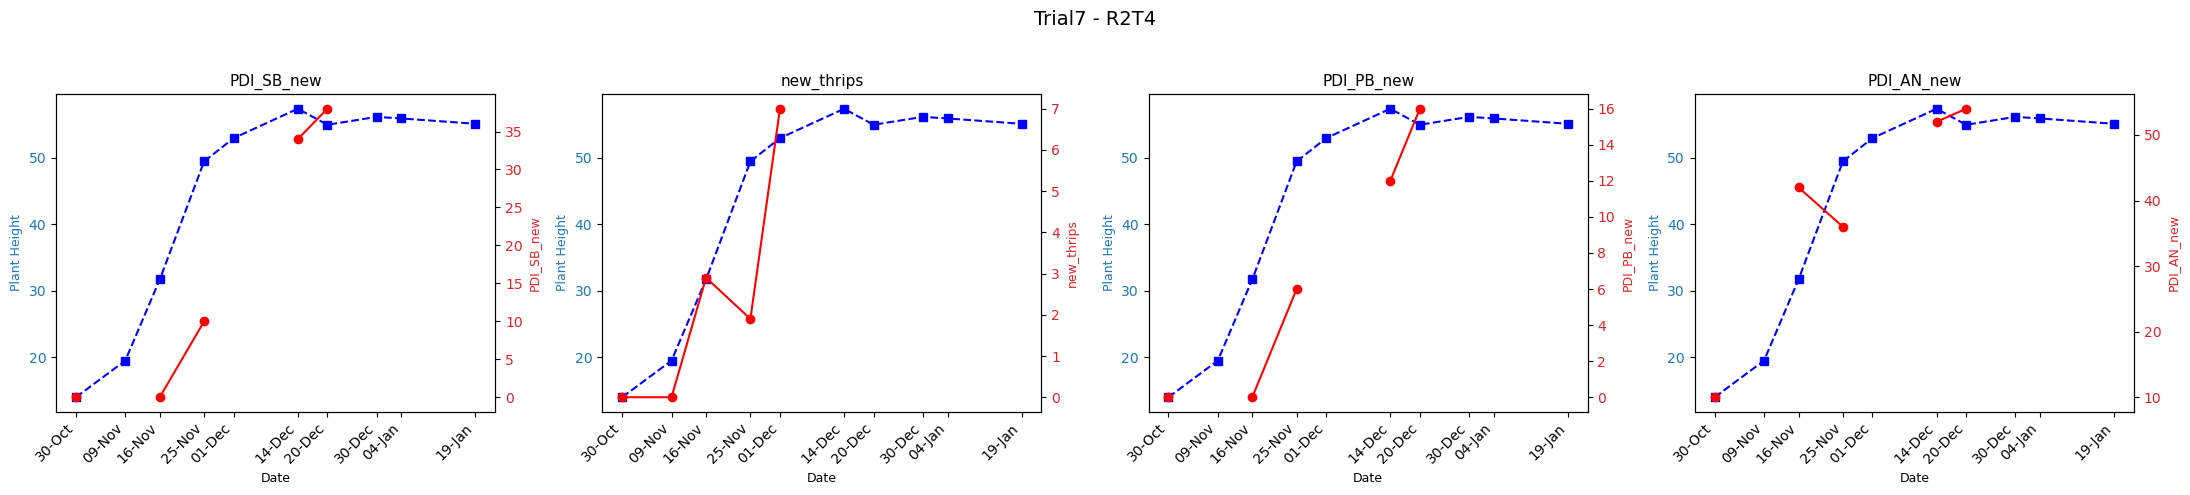

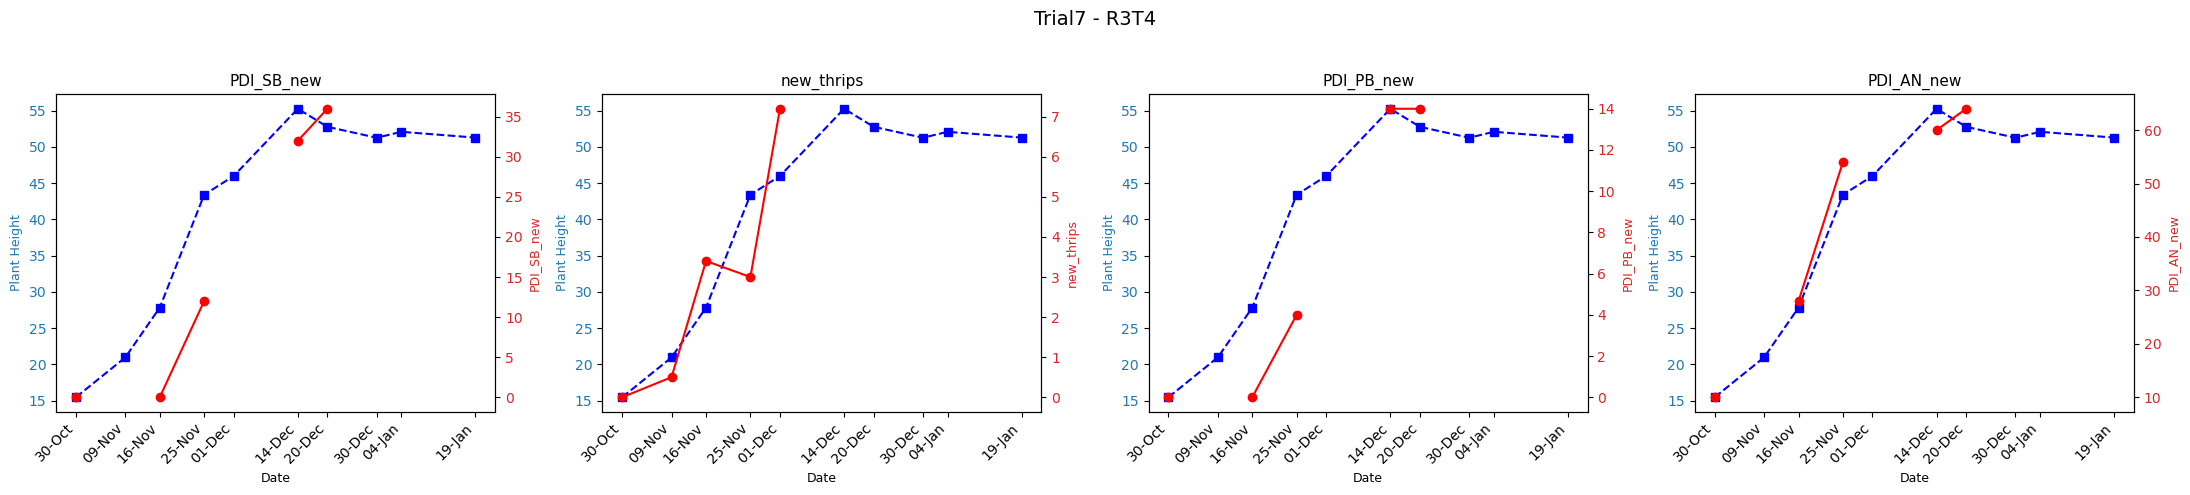

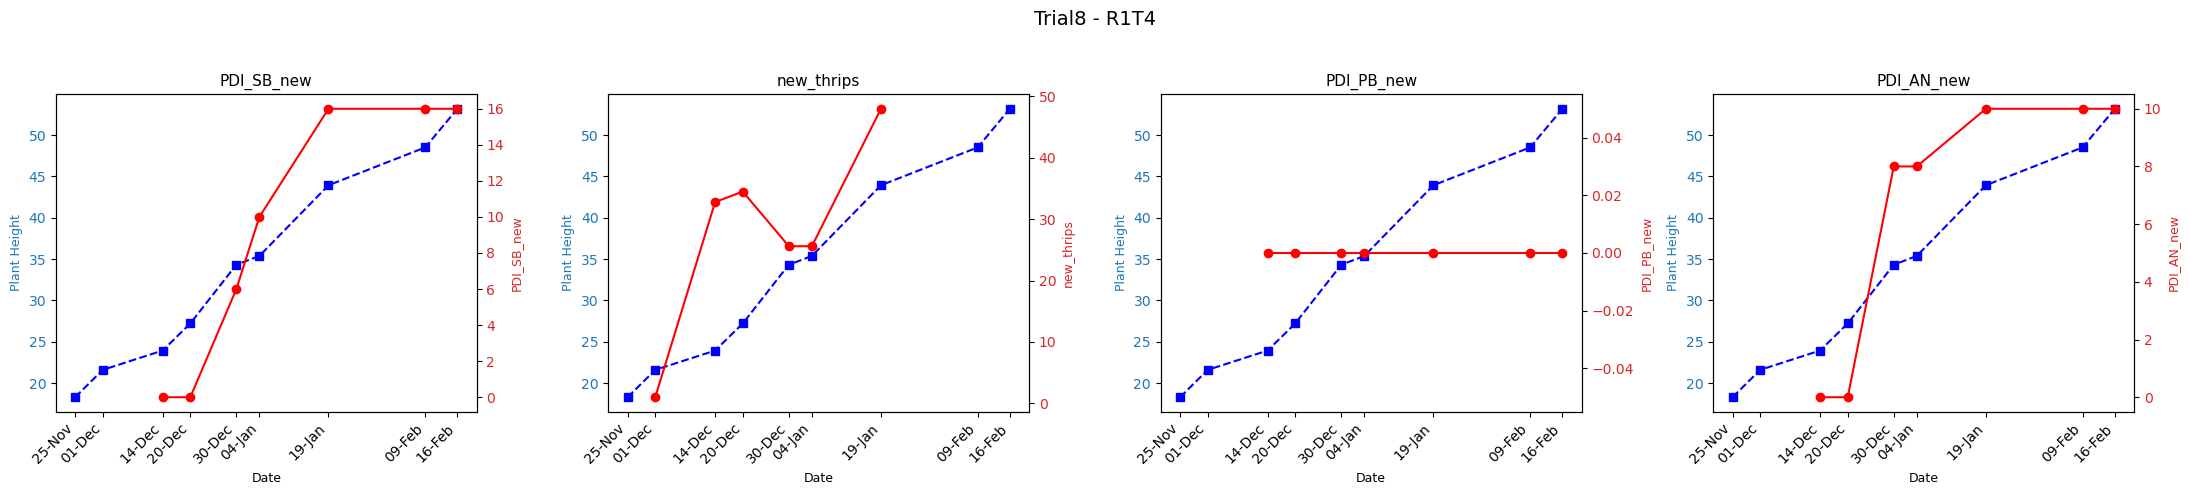

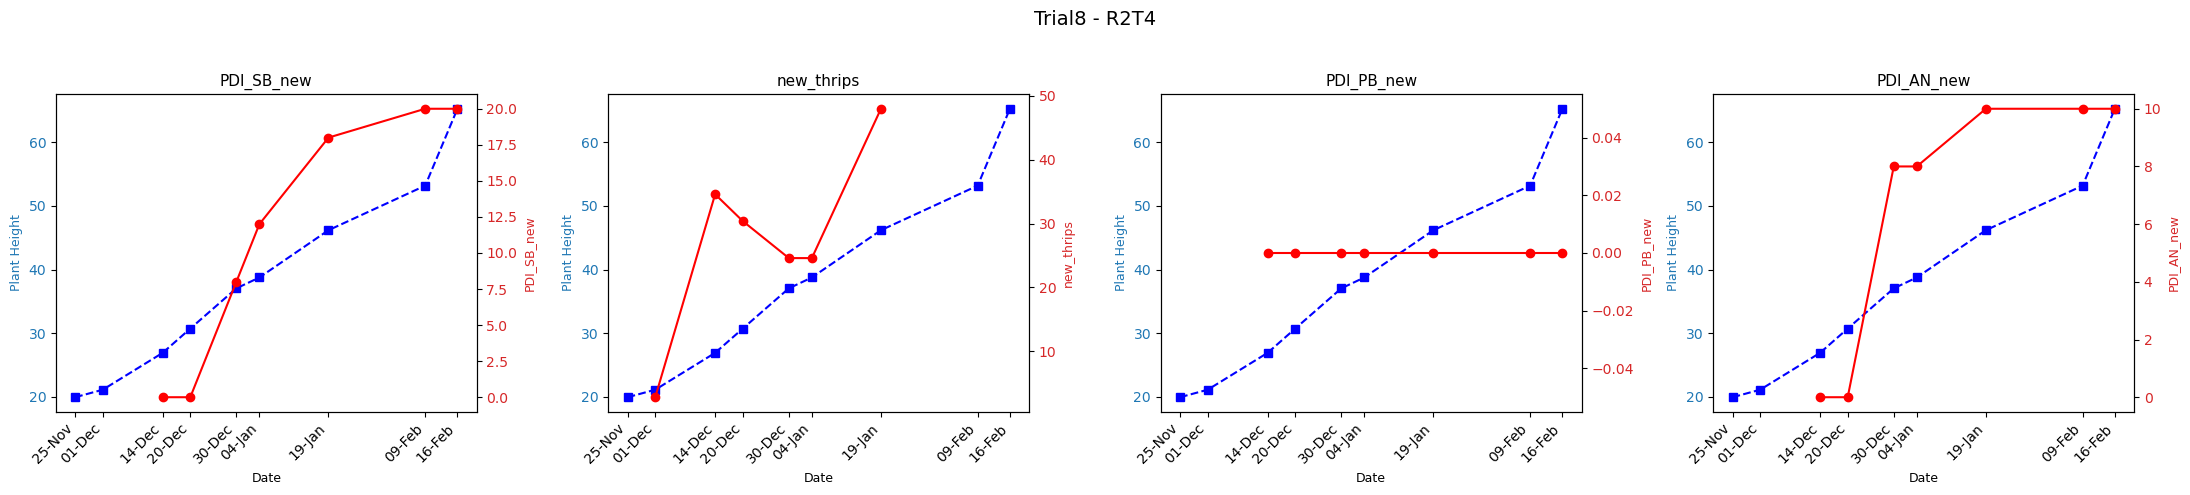

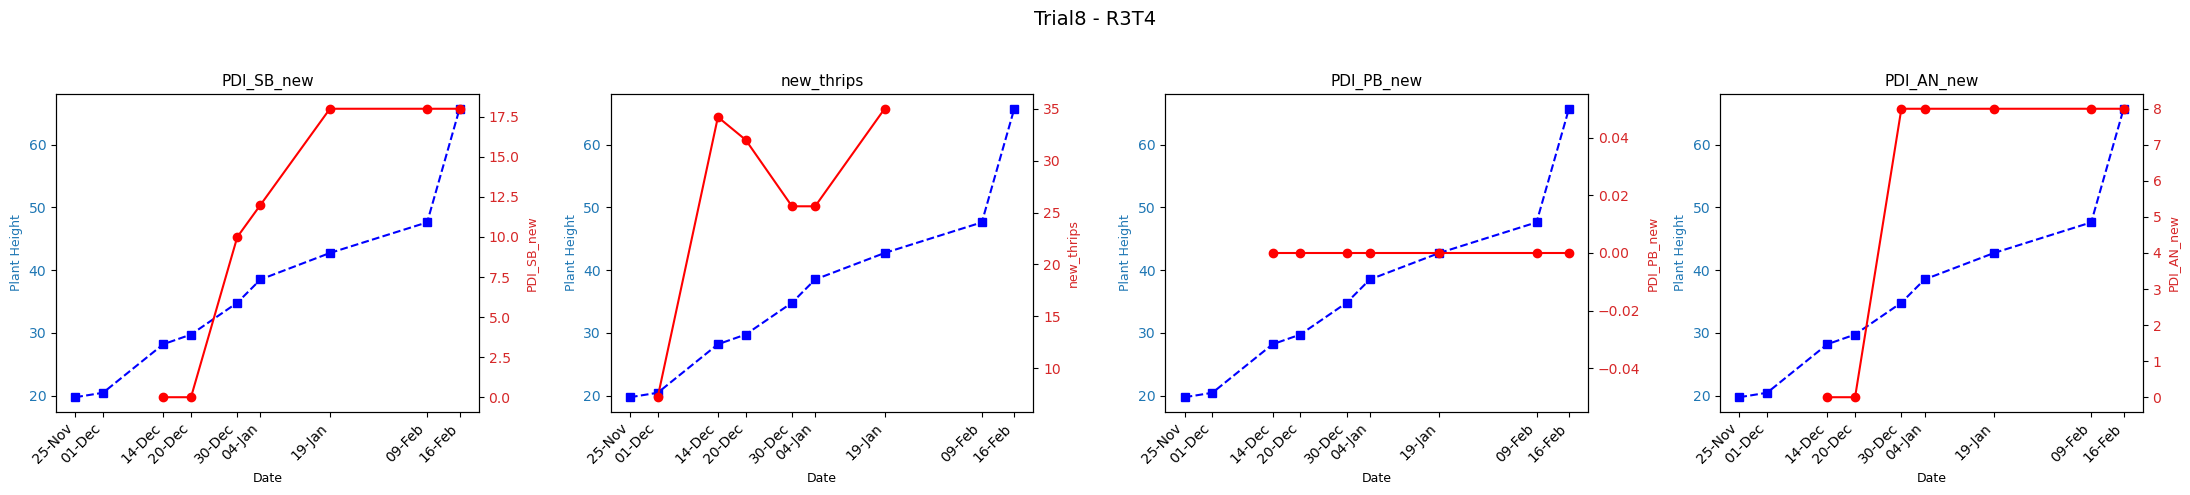

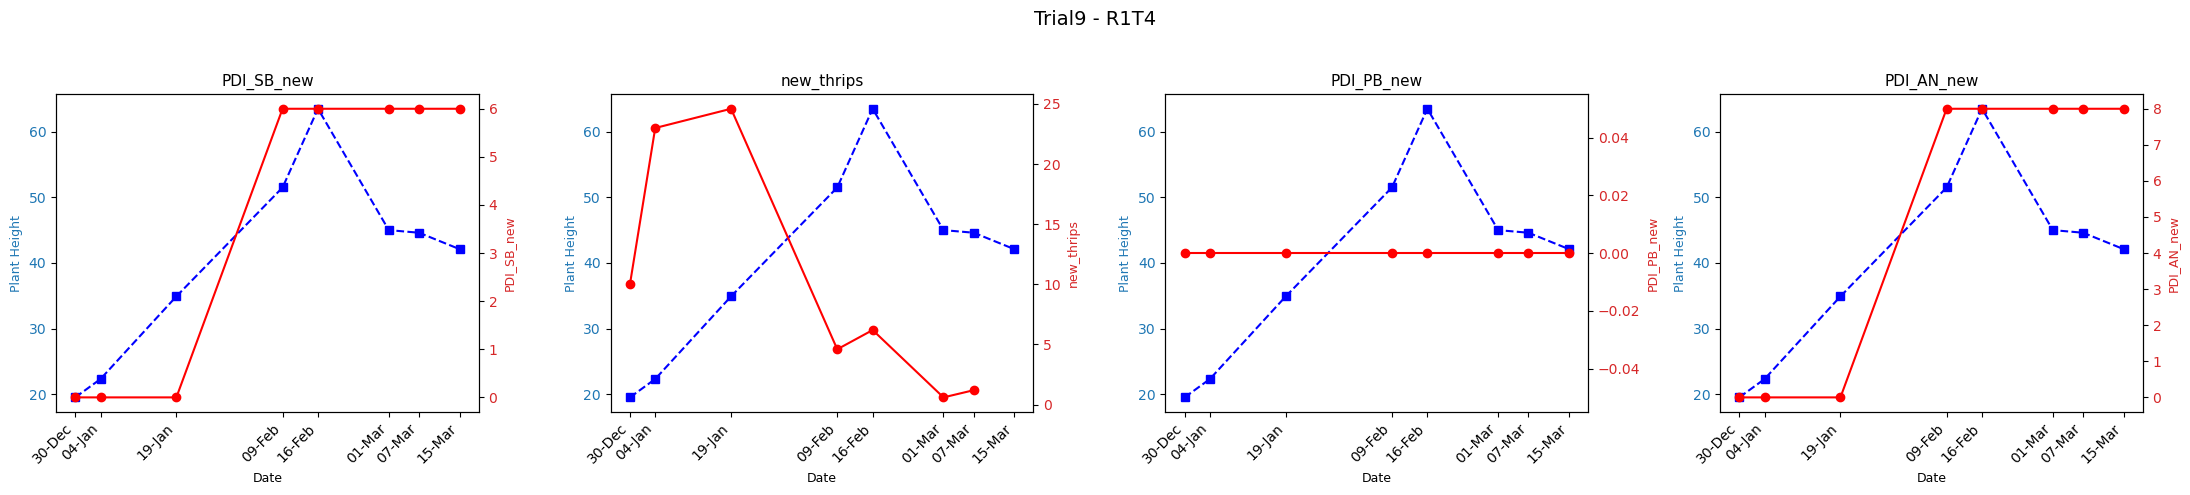

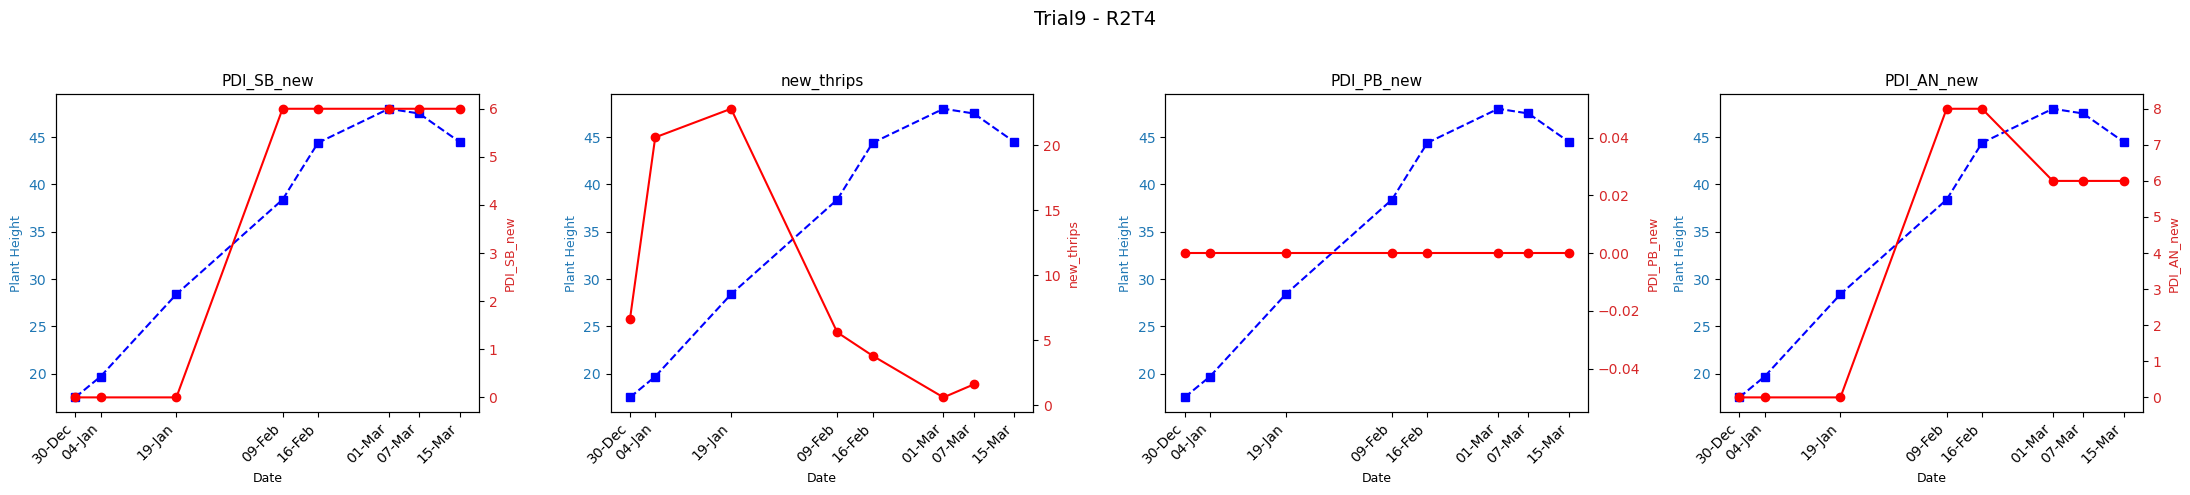

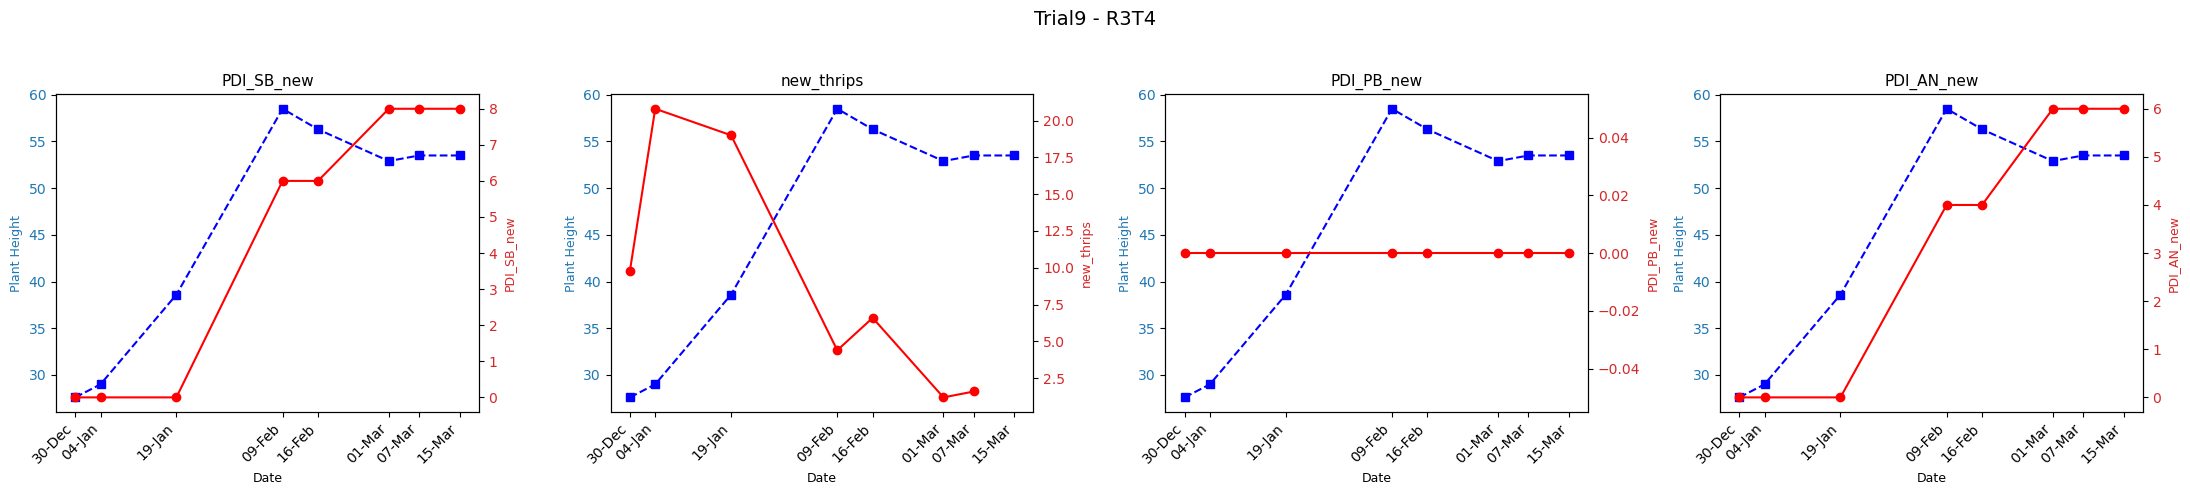

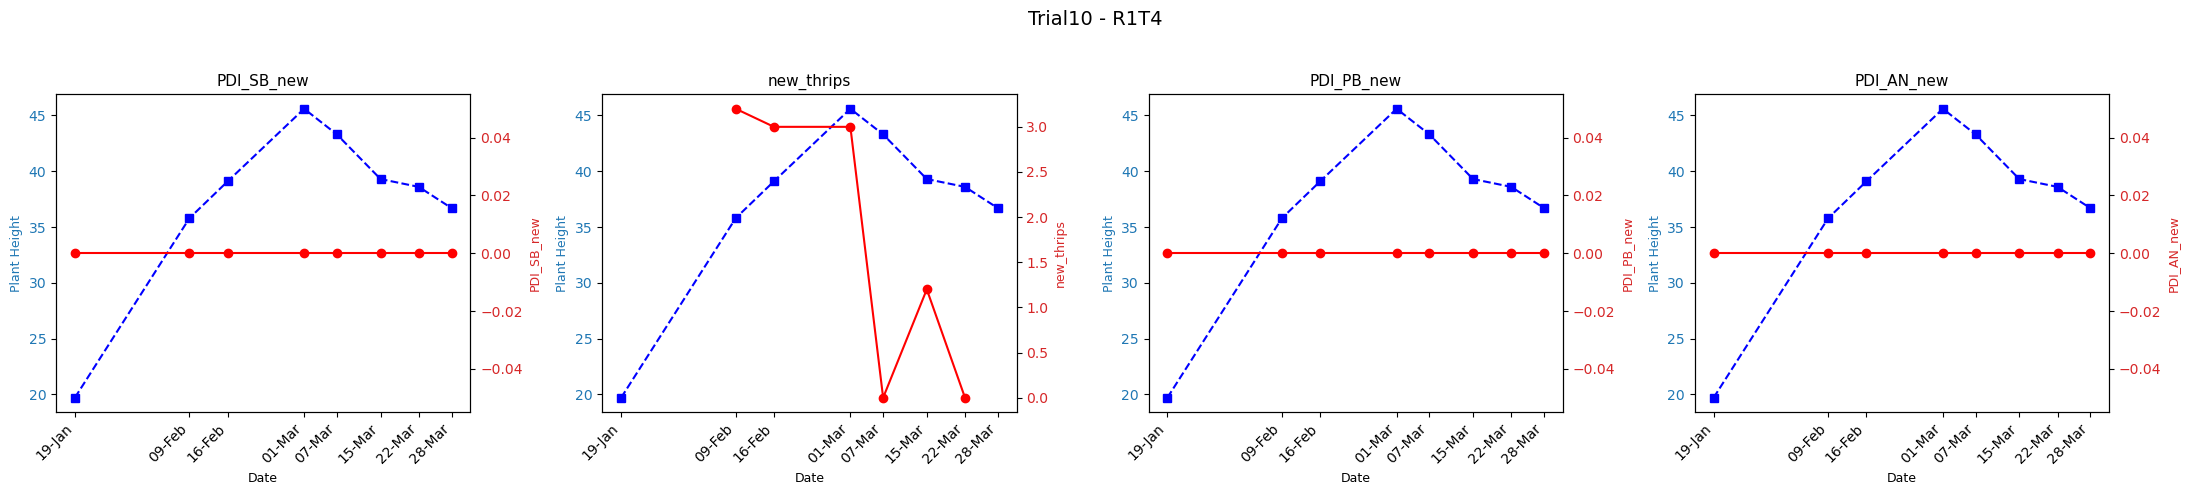

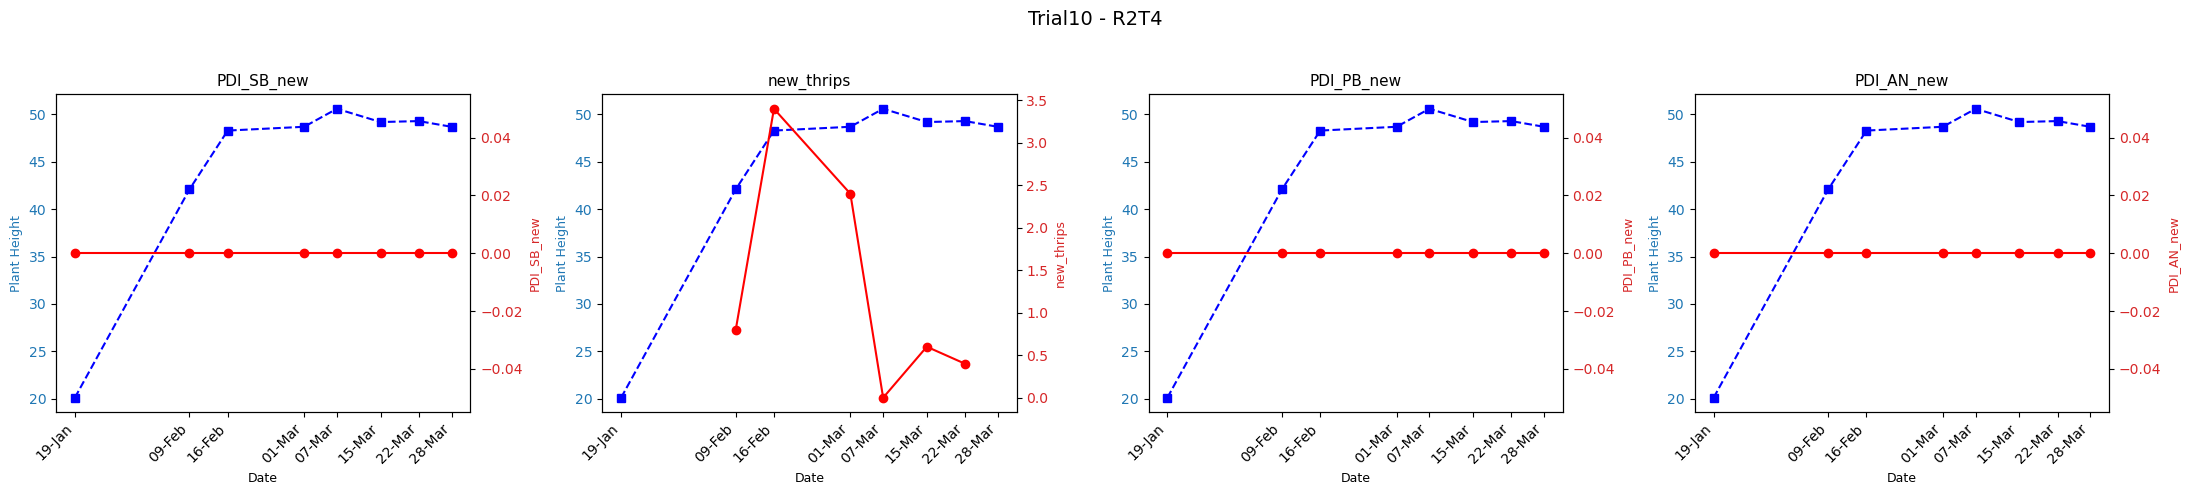

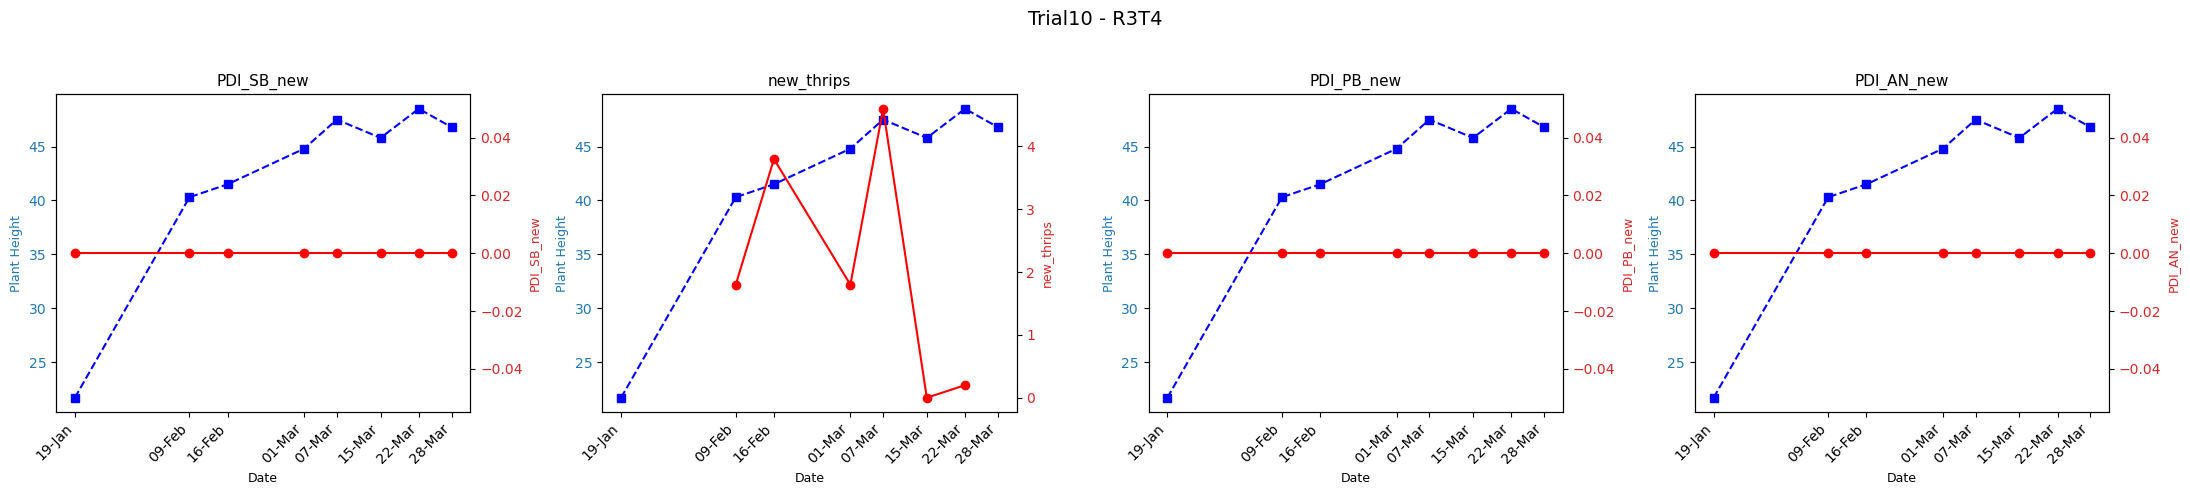

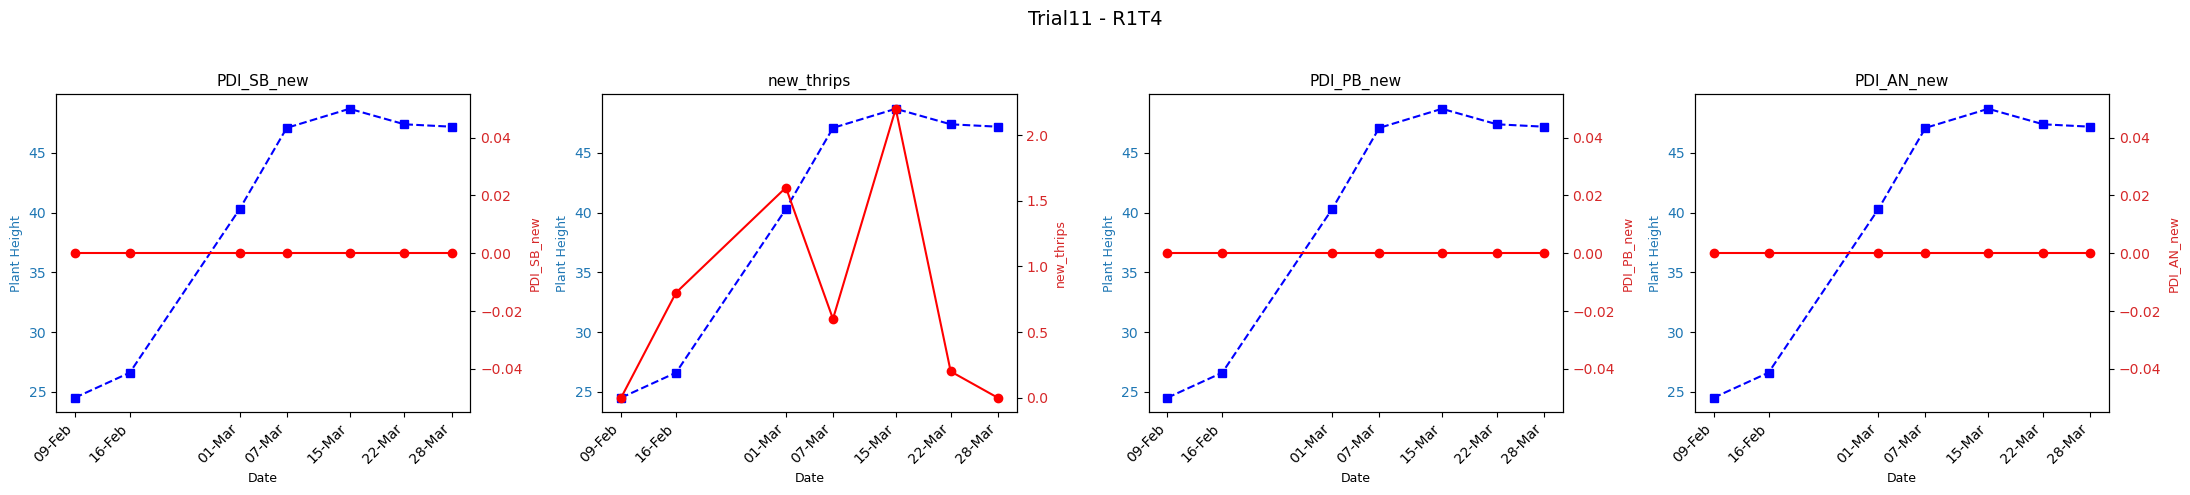

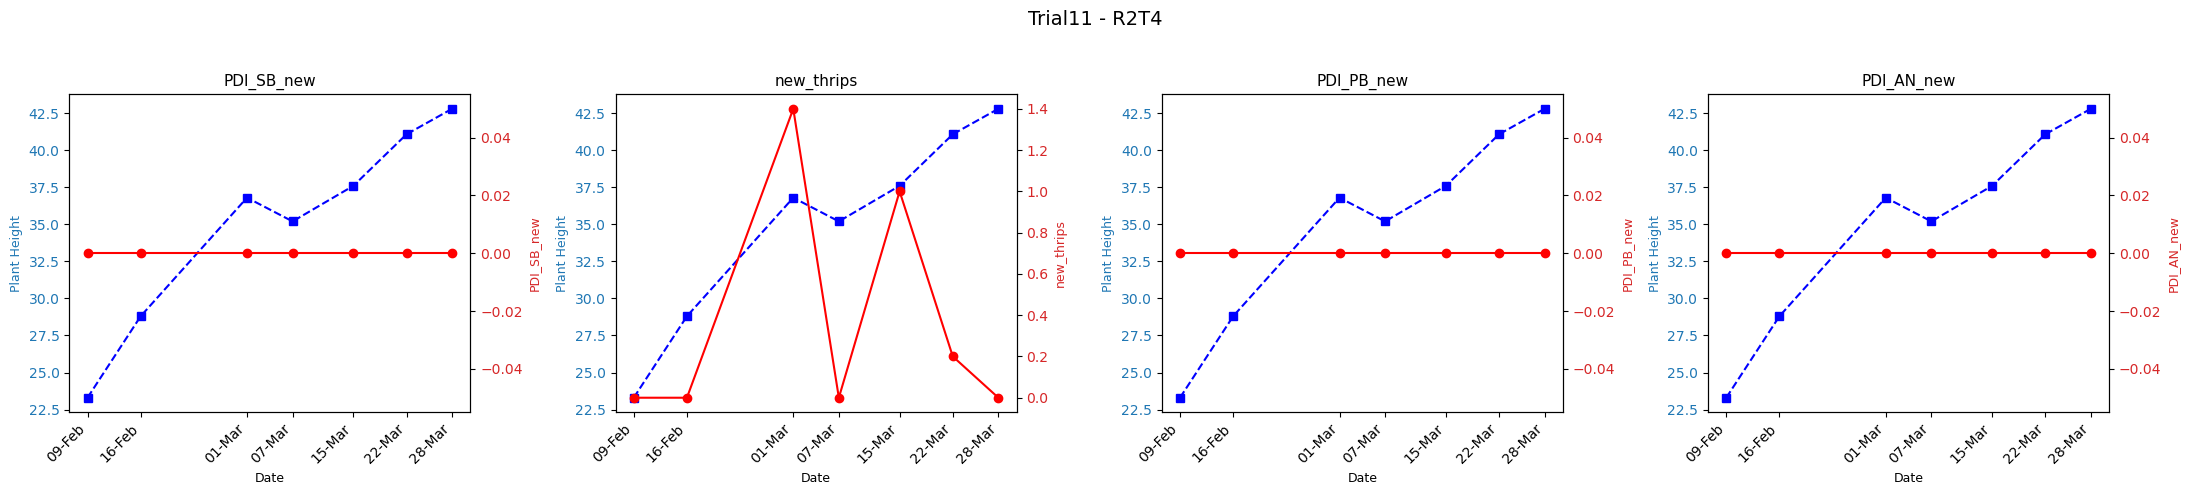

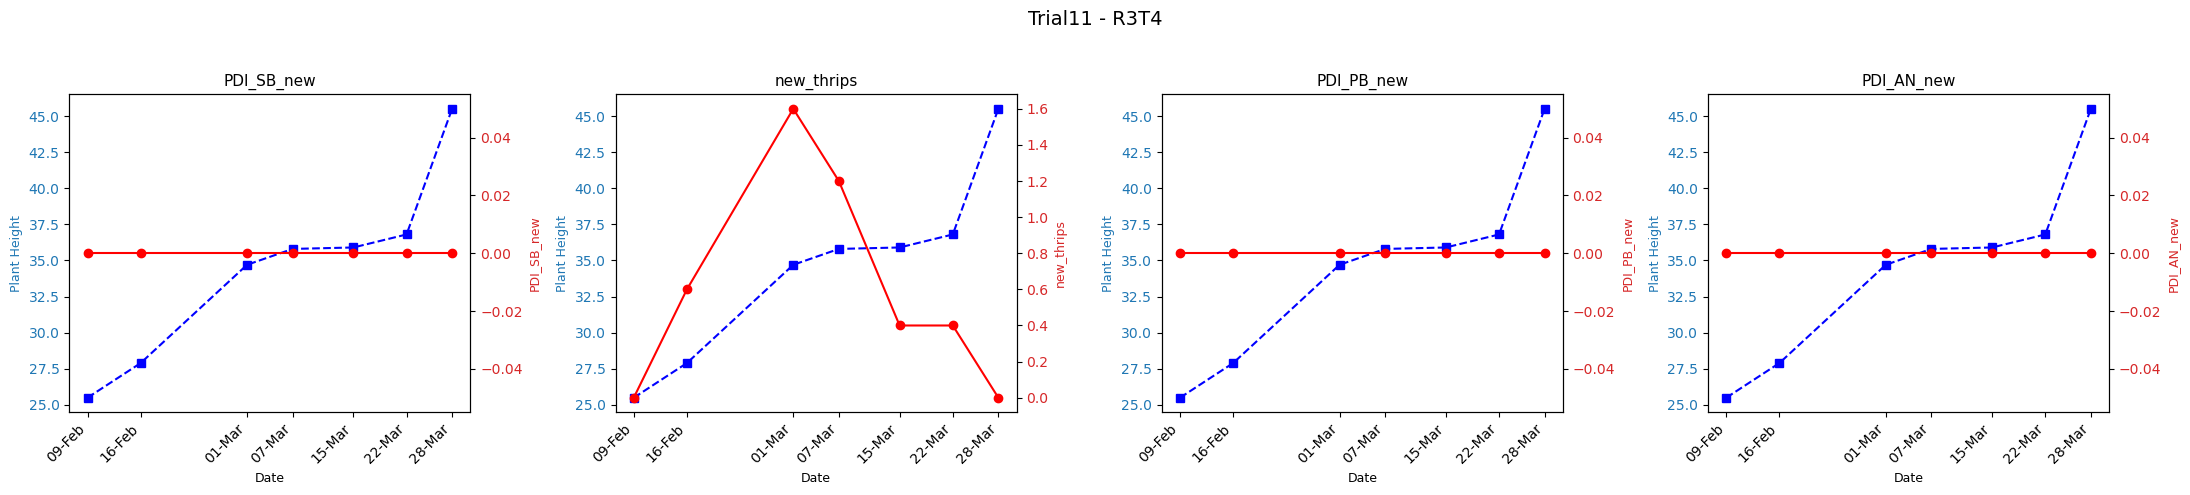

In [5]:
import matplotlib.pyplot as plt
from collections import defaultdict
import matplotlib.dates as mdates

# Disease/pest metrics to plot
disease_metrics = ['PDI_SB_new', 'new_thrips', 'PDI_PB_new', 'PDI_AN_new']

for trial_name, trial_data in combined_data.items():
    for region, records in trial_data.items():
        # Group data by date
        grouped = defaultdict(dict)
        for rec in records:
            date = rec['Date']
            grouped[date].update(rec)

        # Sort dates
        dates = sorted(grouped.keys())
        plant_heights = [grouped[dt].get('Plant_H') for dt in dates]

        # Start a 1-row, 4-column subplot
        fig, axs = plt.subplots(1, 4, figsize=(22, 5), sharex=False)
        fig.suptitle(f"{trial_name} - {region}", fontsize=14)

        for idx, metric in enumerate(disease_metrics):
            y_metric = [grouped[dt].get(metric) for dt in dates]

            ax1 = axs[idx]
            ax1.set_title(metric, fontsize=11)
            ax1.set_xlabel("Date", fontsize=9)
            ax1.set_ylabel("Plant Height", color='tab:blue', fontsize=9)
            ax1.plot(dates, plant_heights, 'b--s', label='Plant_H')
            ax1.tick_params(axis='y', labelcolor='tab:blue')

            # Show only ticks where we have data
            ax1.set_xticks(dates)
            ax1.set_xticklabels([dt.strftime('%d-%b') for dt in dates], rotation=45, ha='right')

            # Right Y-axis for disease metric
            ax2 = ax1.twinx()
            ax2.set_ylabel(metric, color='tab:red', fontsize=9)
            ax2.plot(dates, y_metric, 'r-o', label=metric)
            ax2.tick_params(axis='y', labelcolor='tab:red')

        plt.tight_layout(rect=[0, 0, 1, 0.95])
        plt.show()


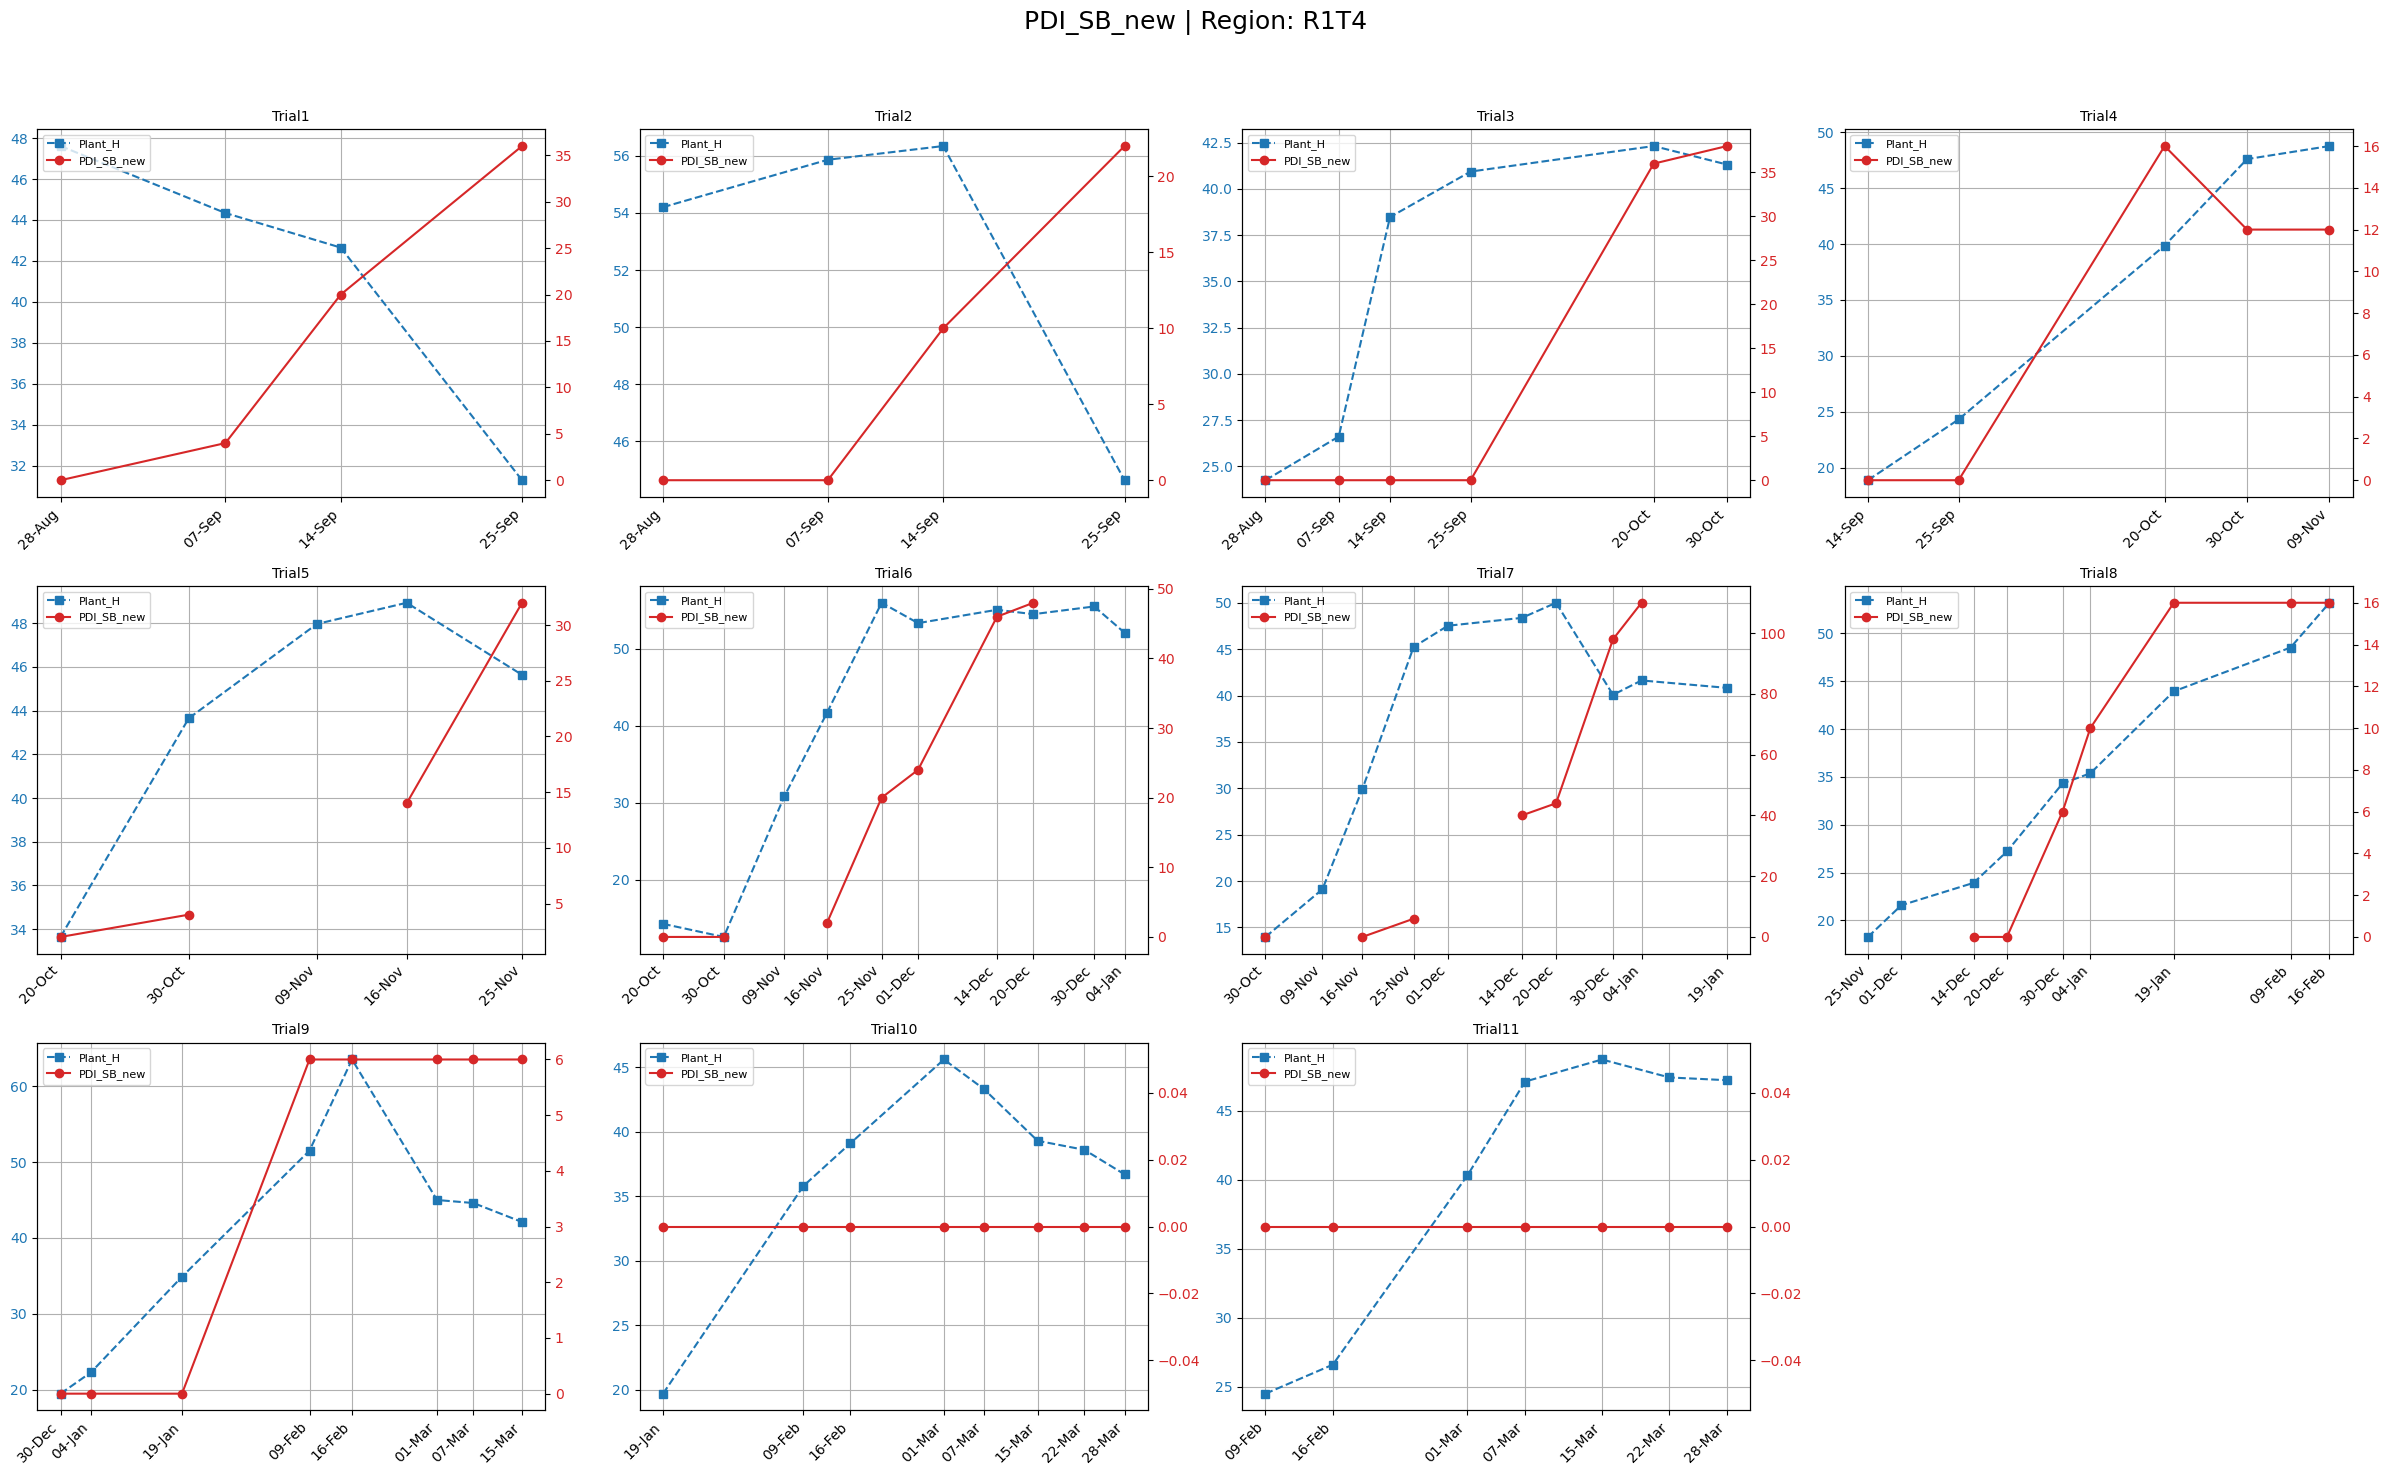

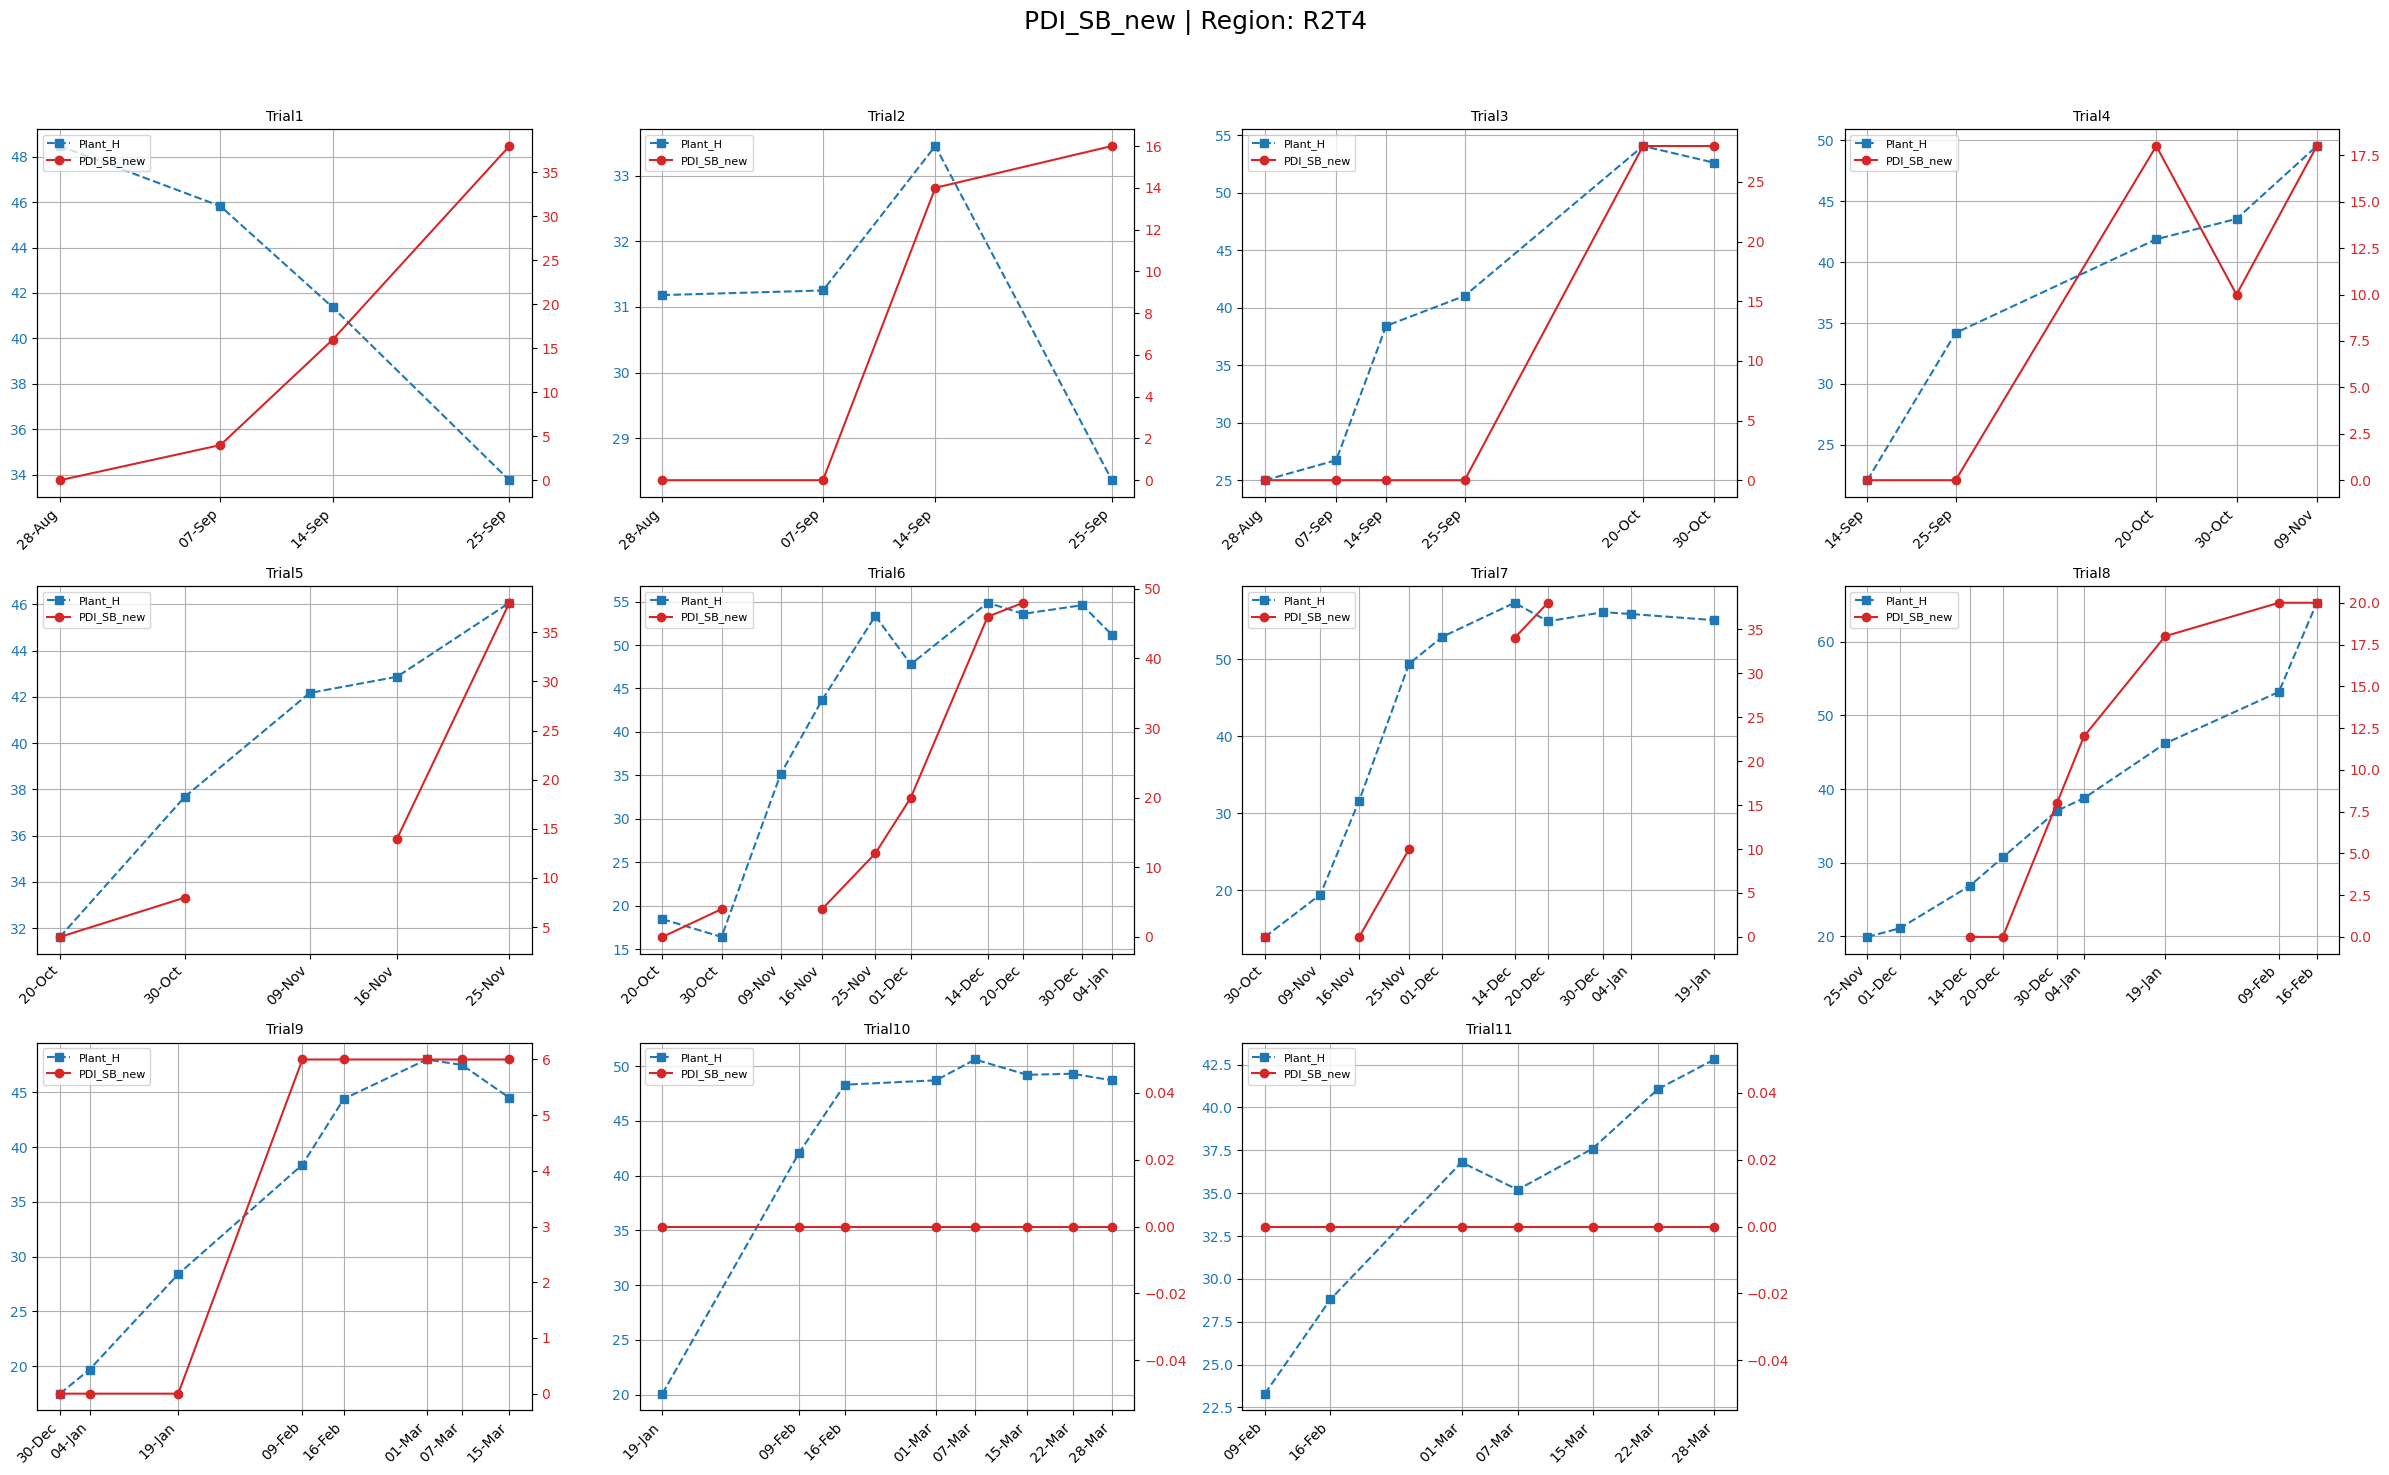

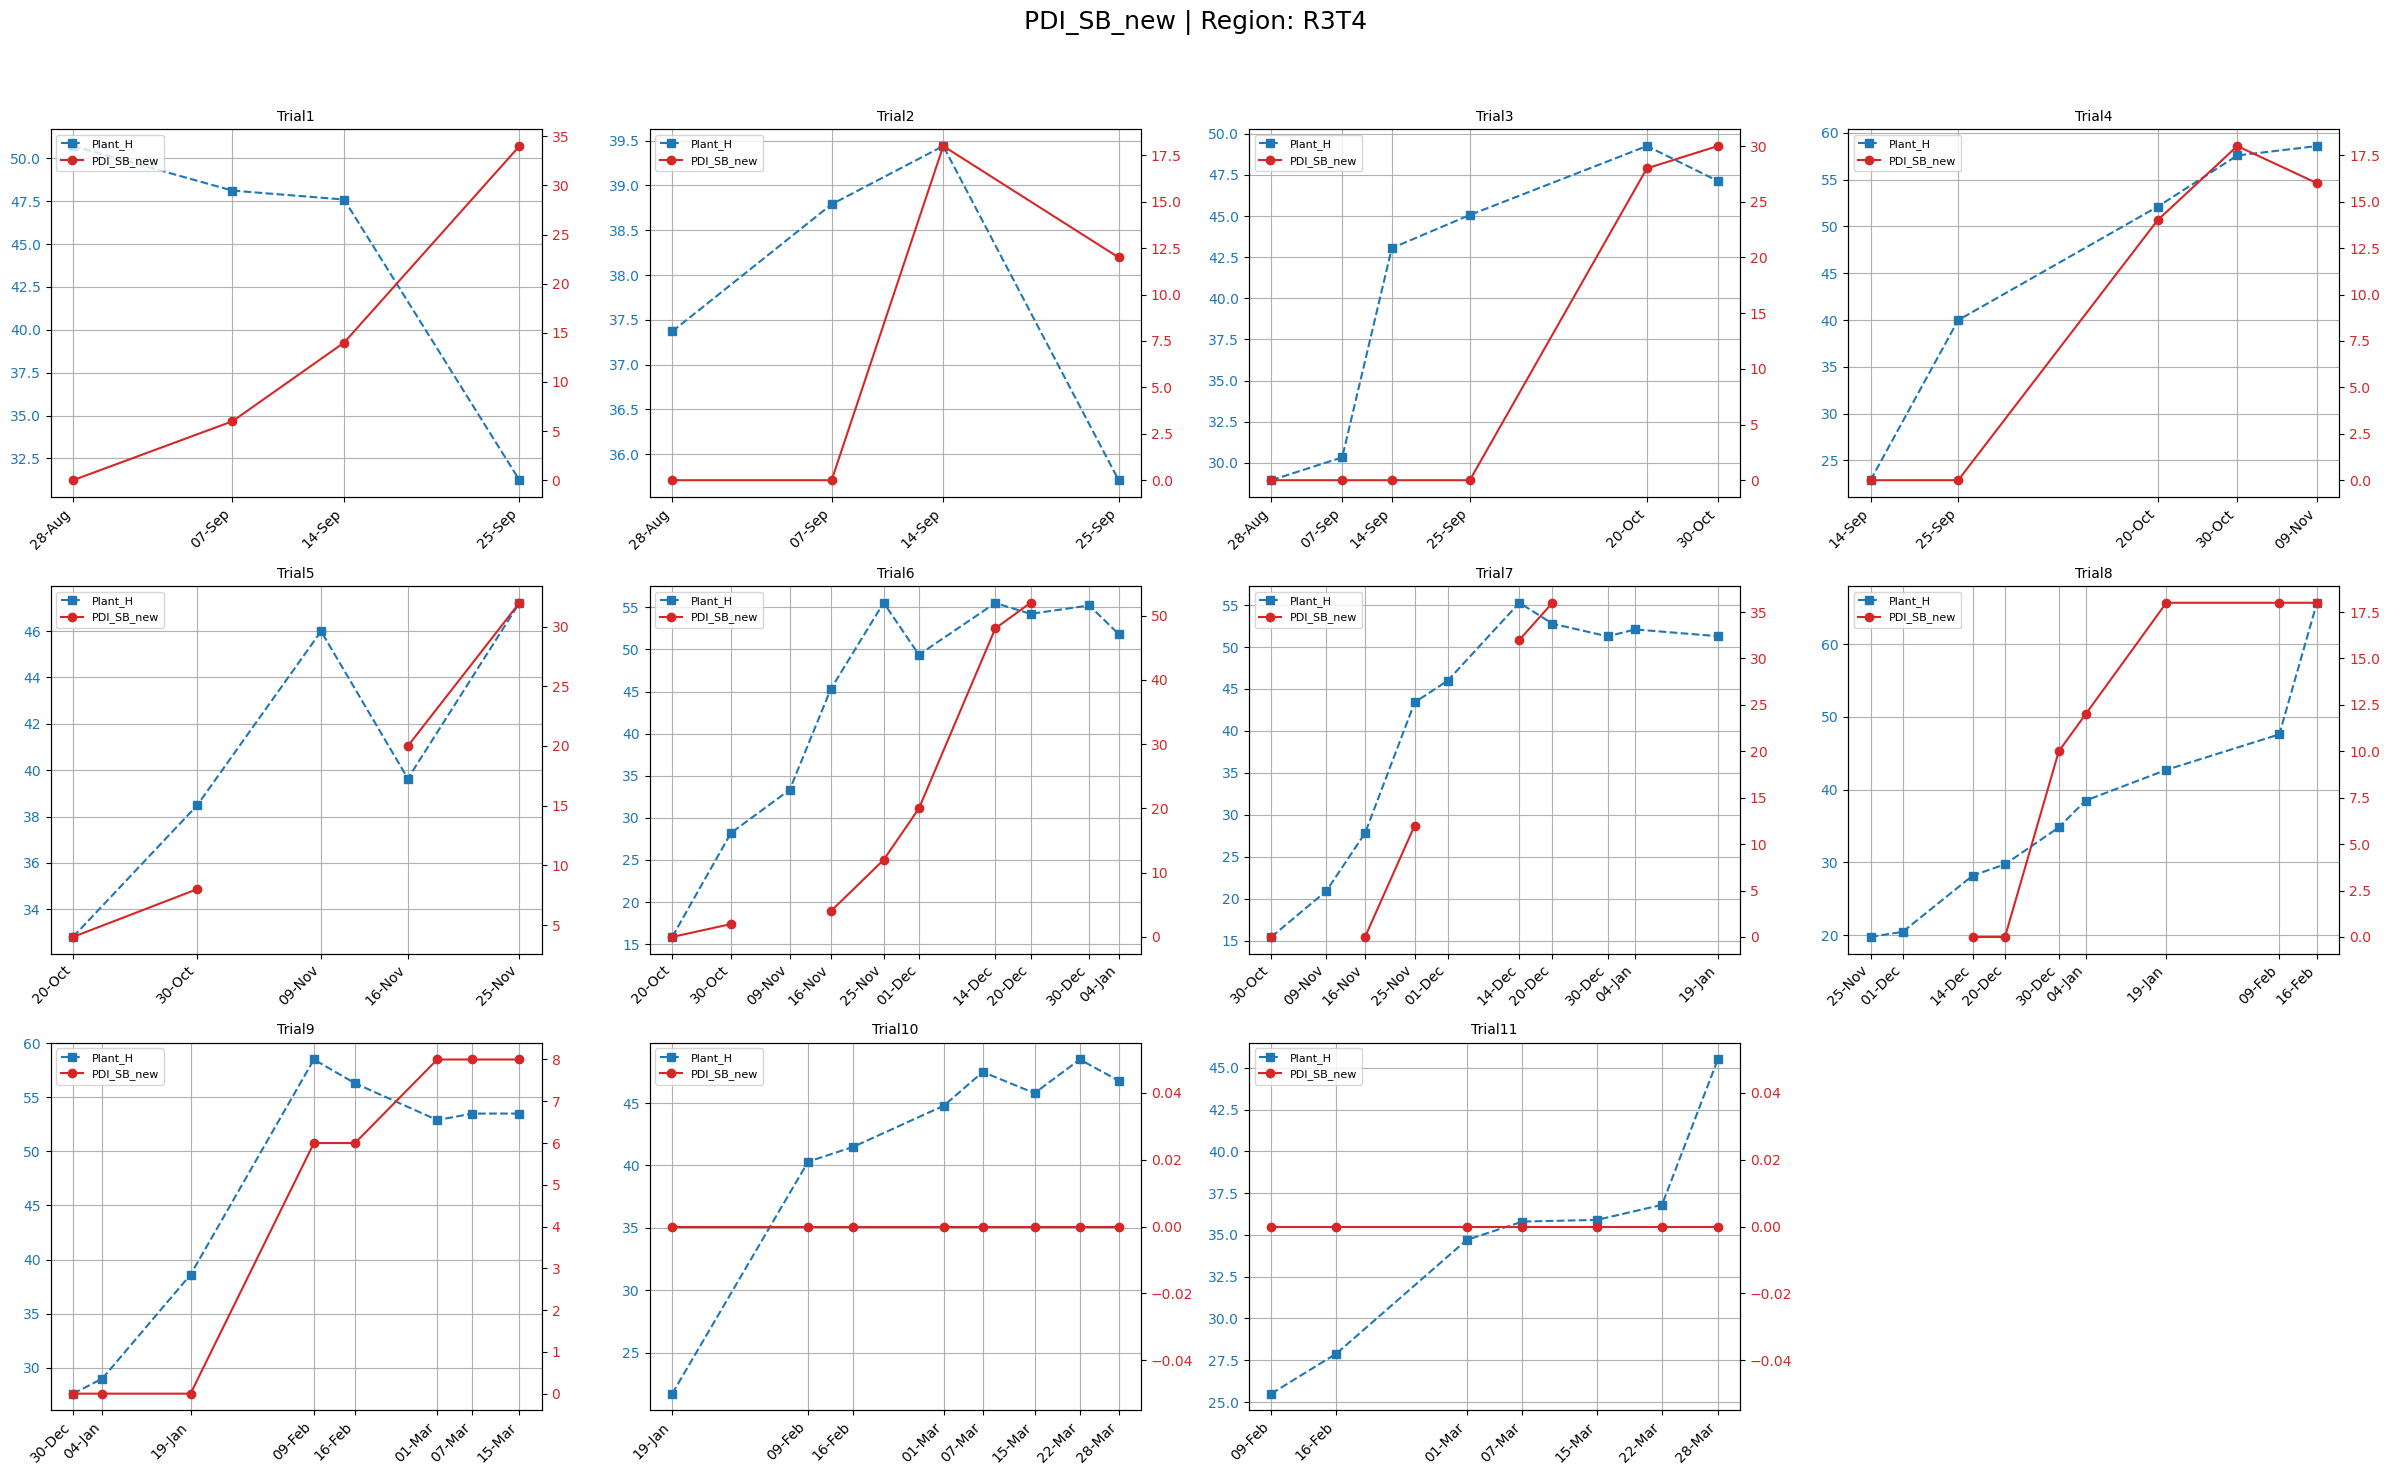

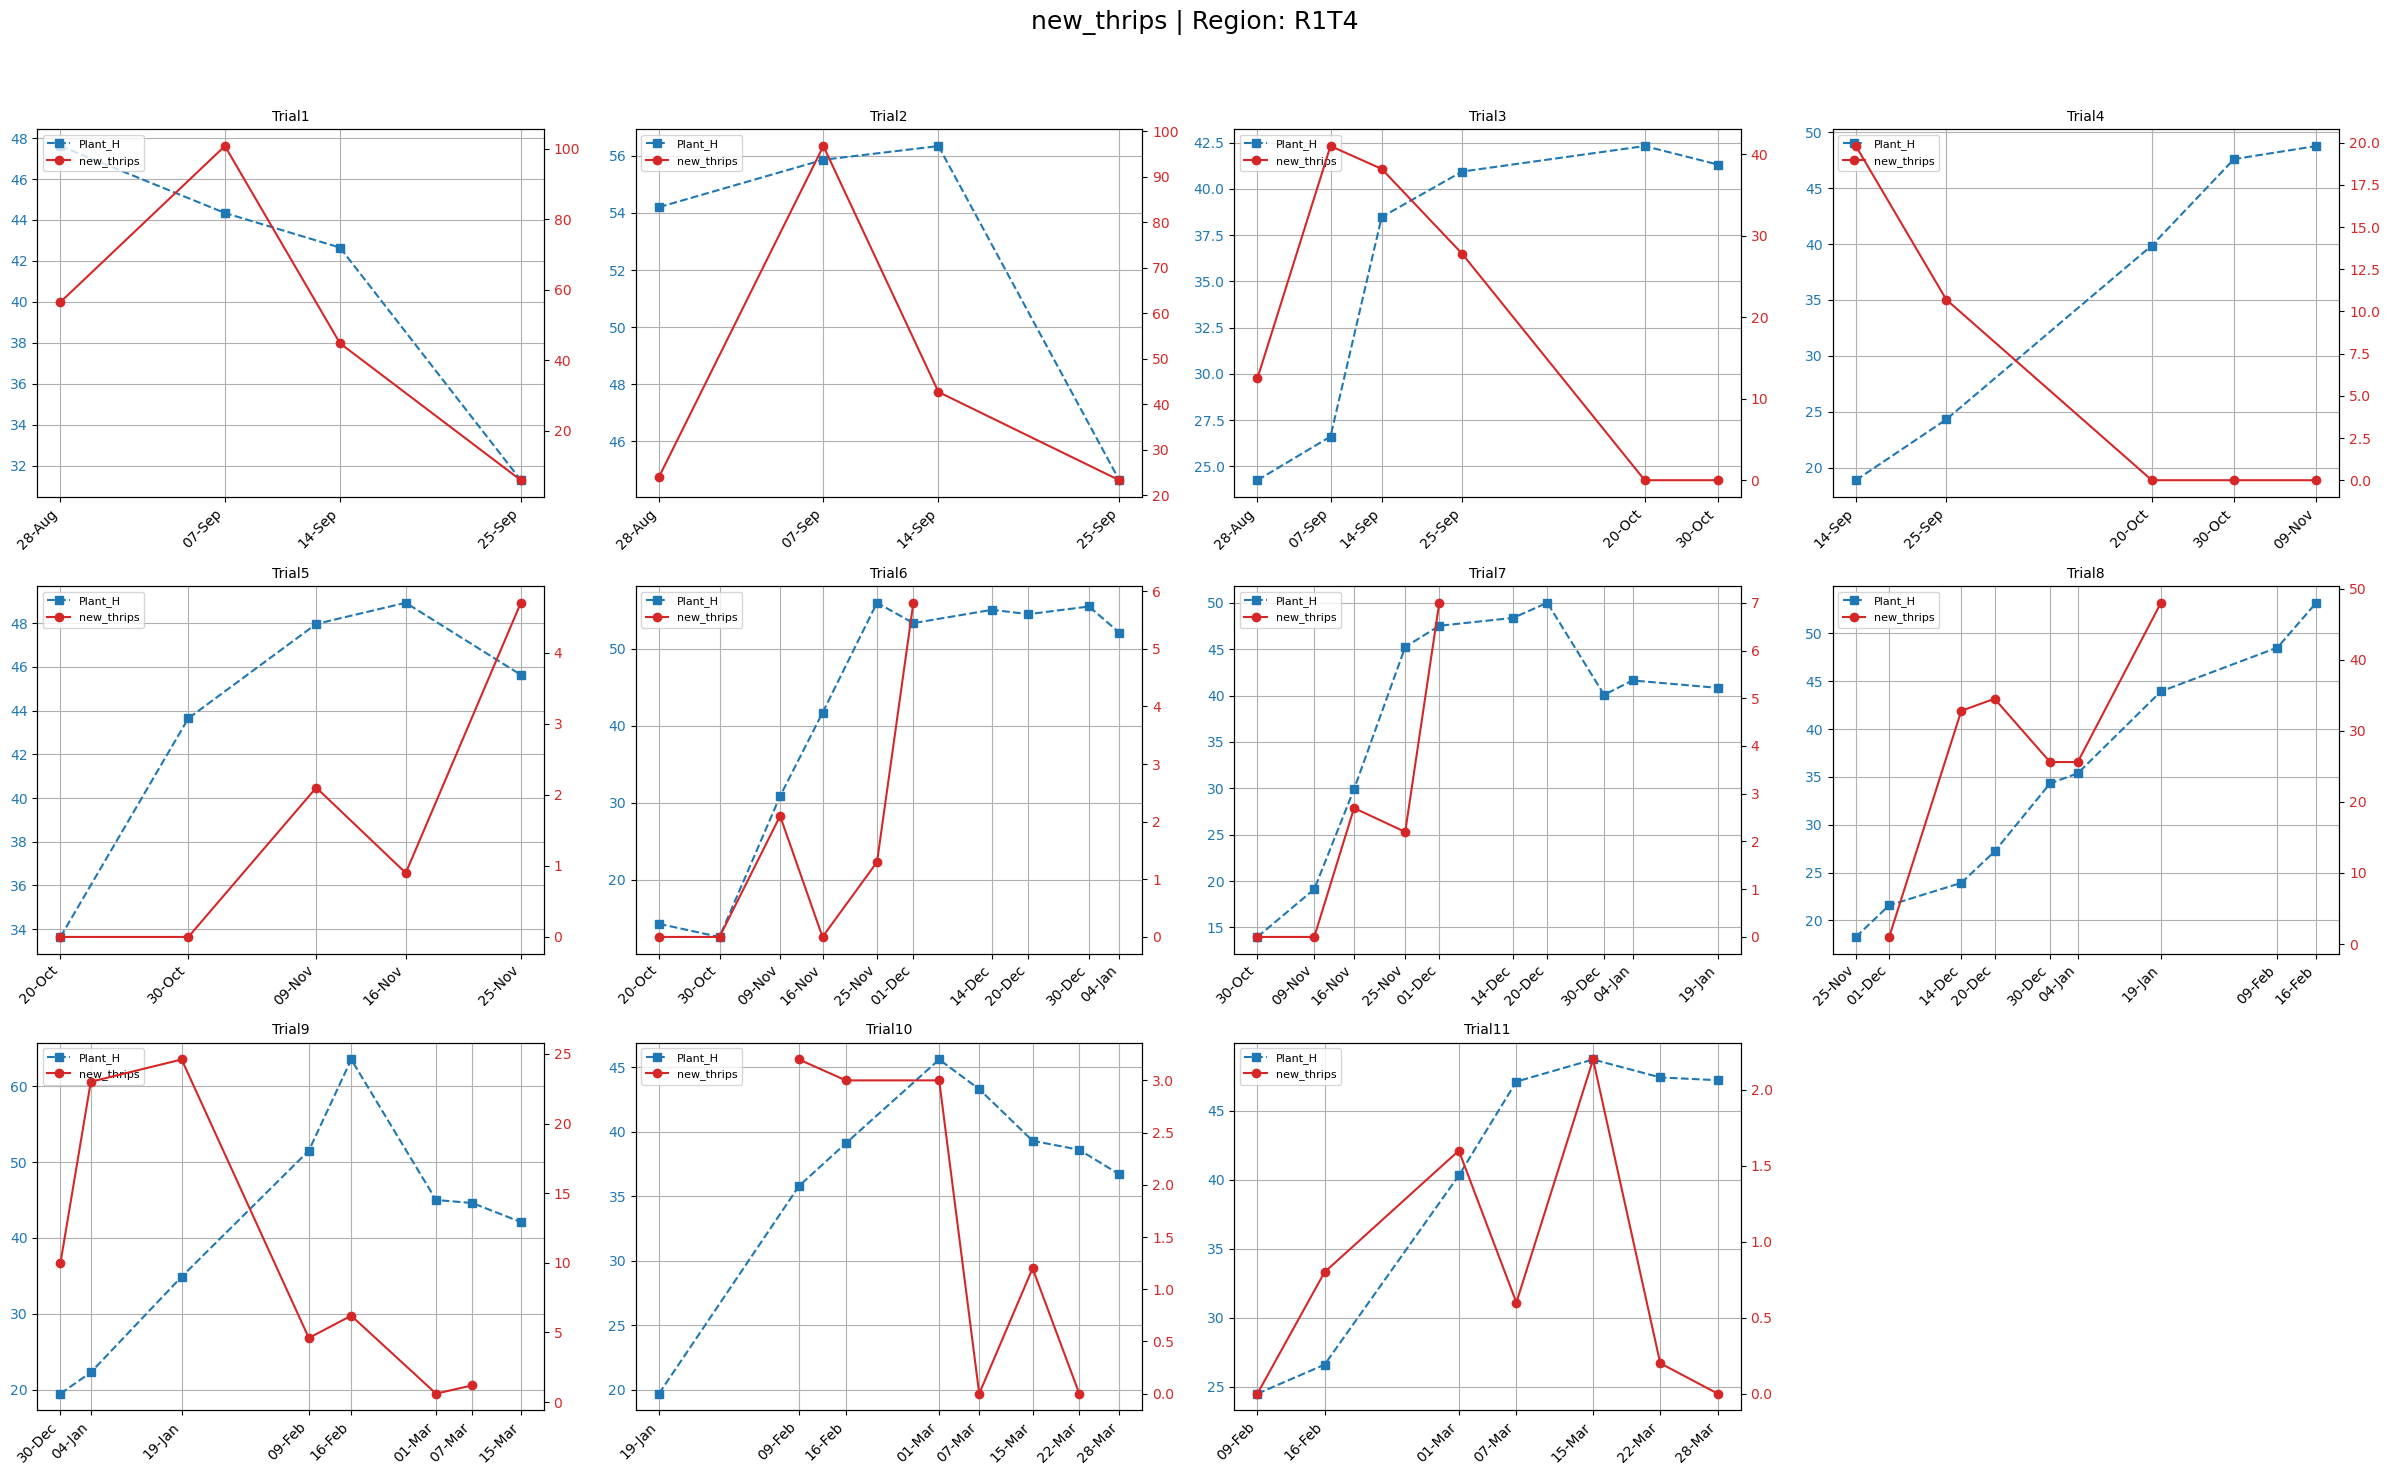

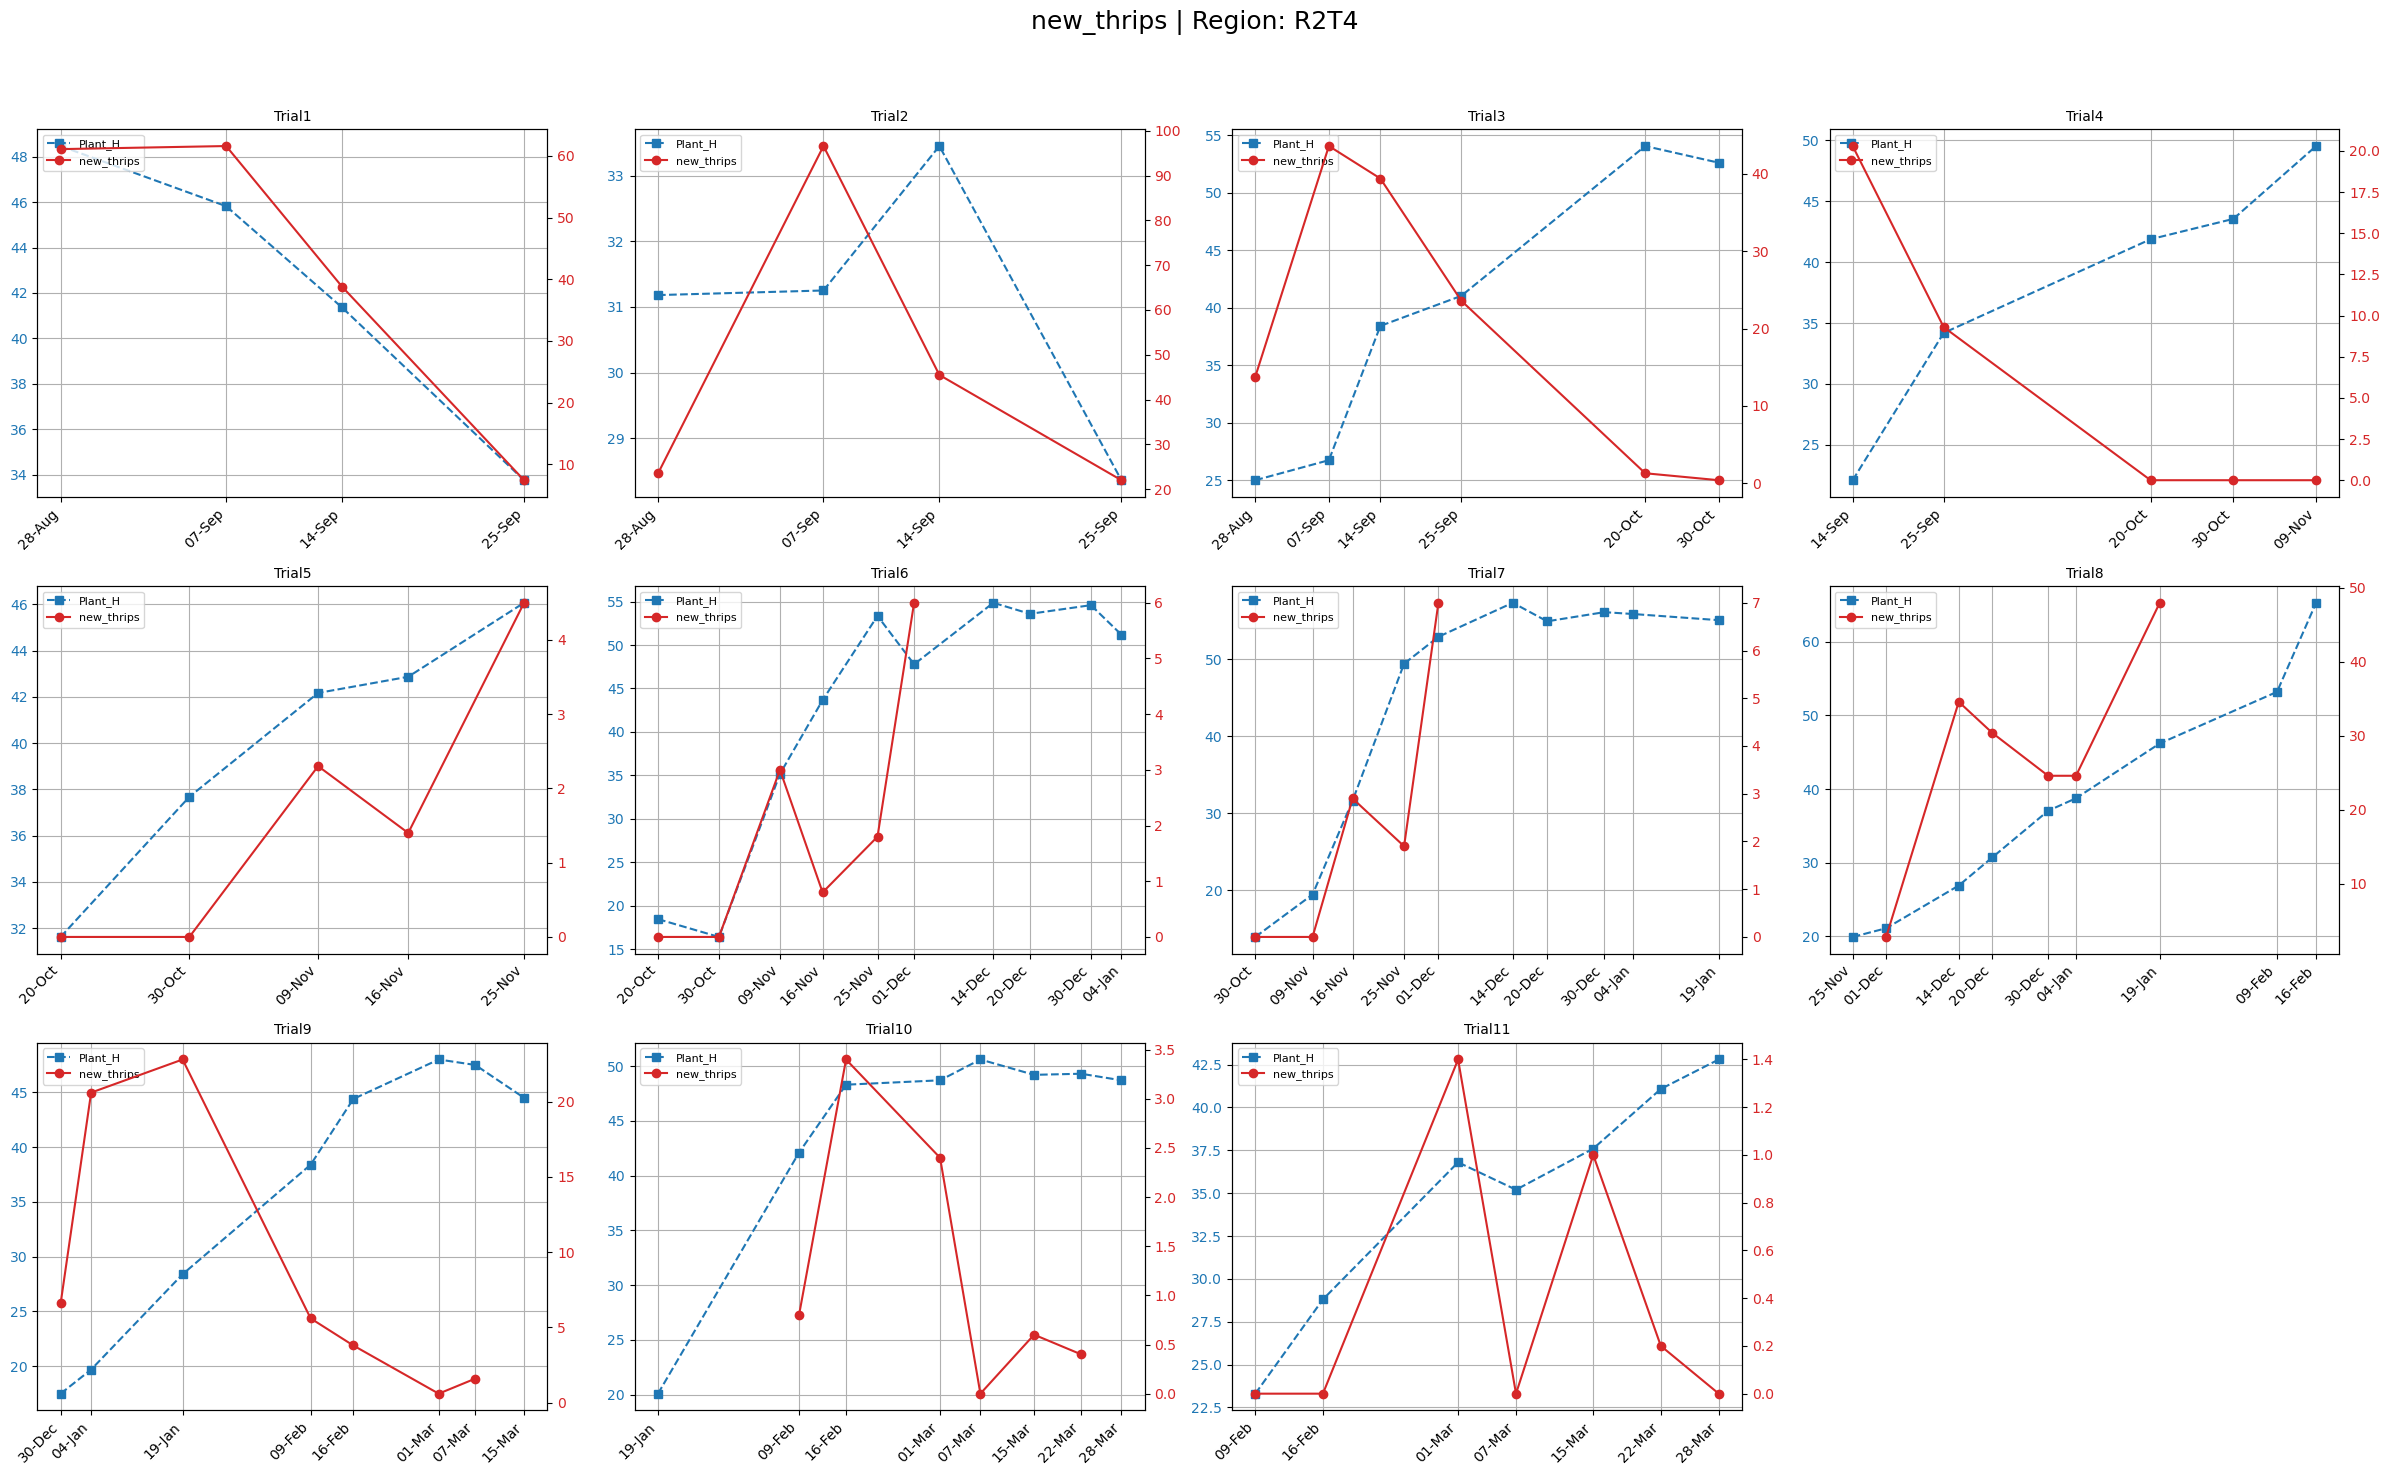

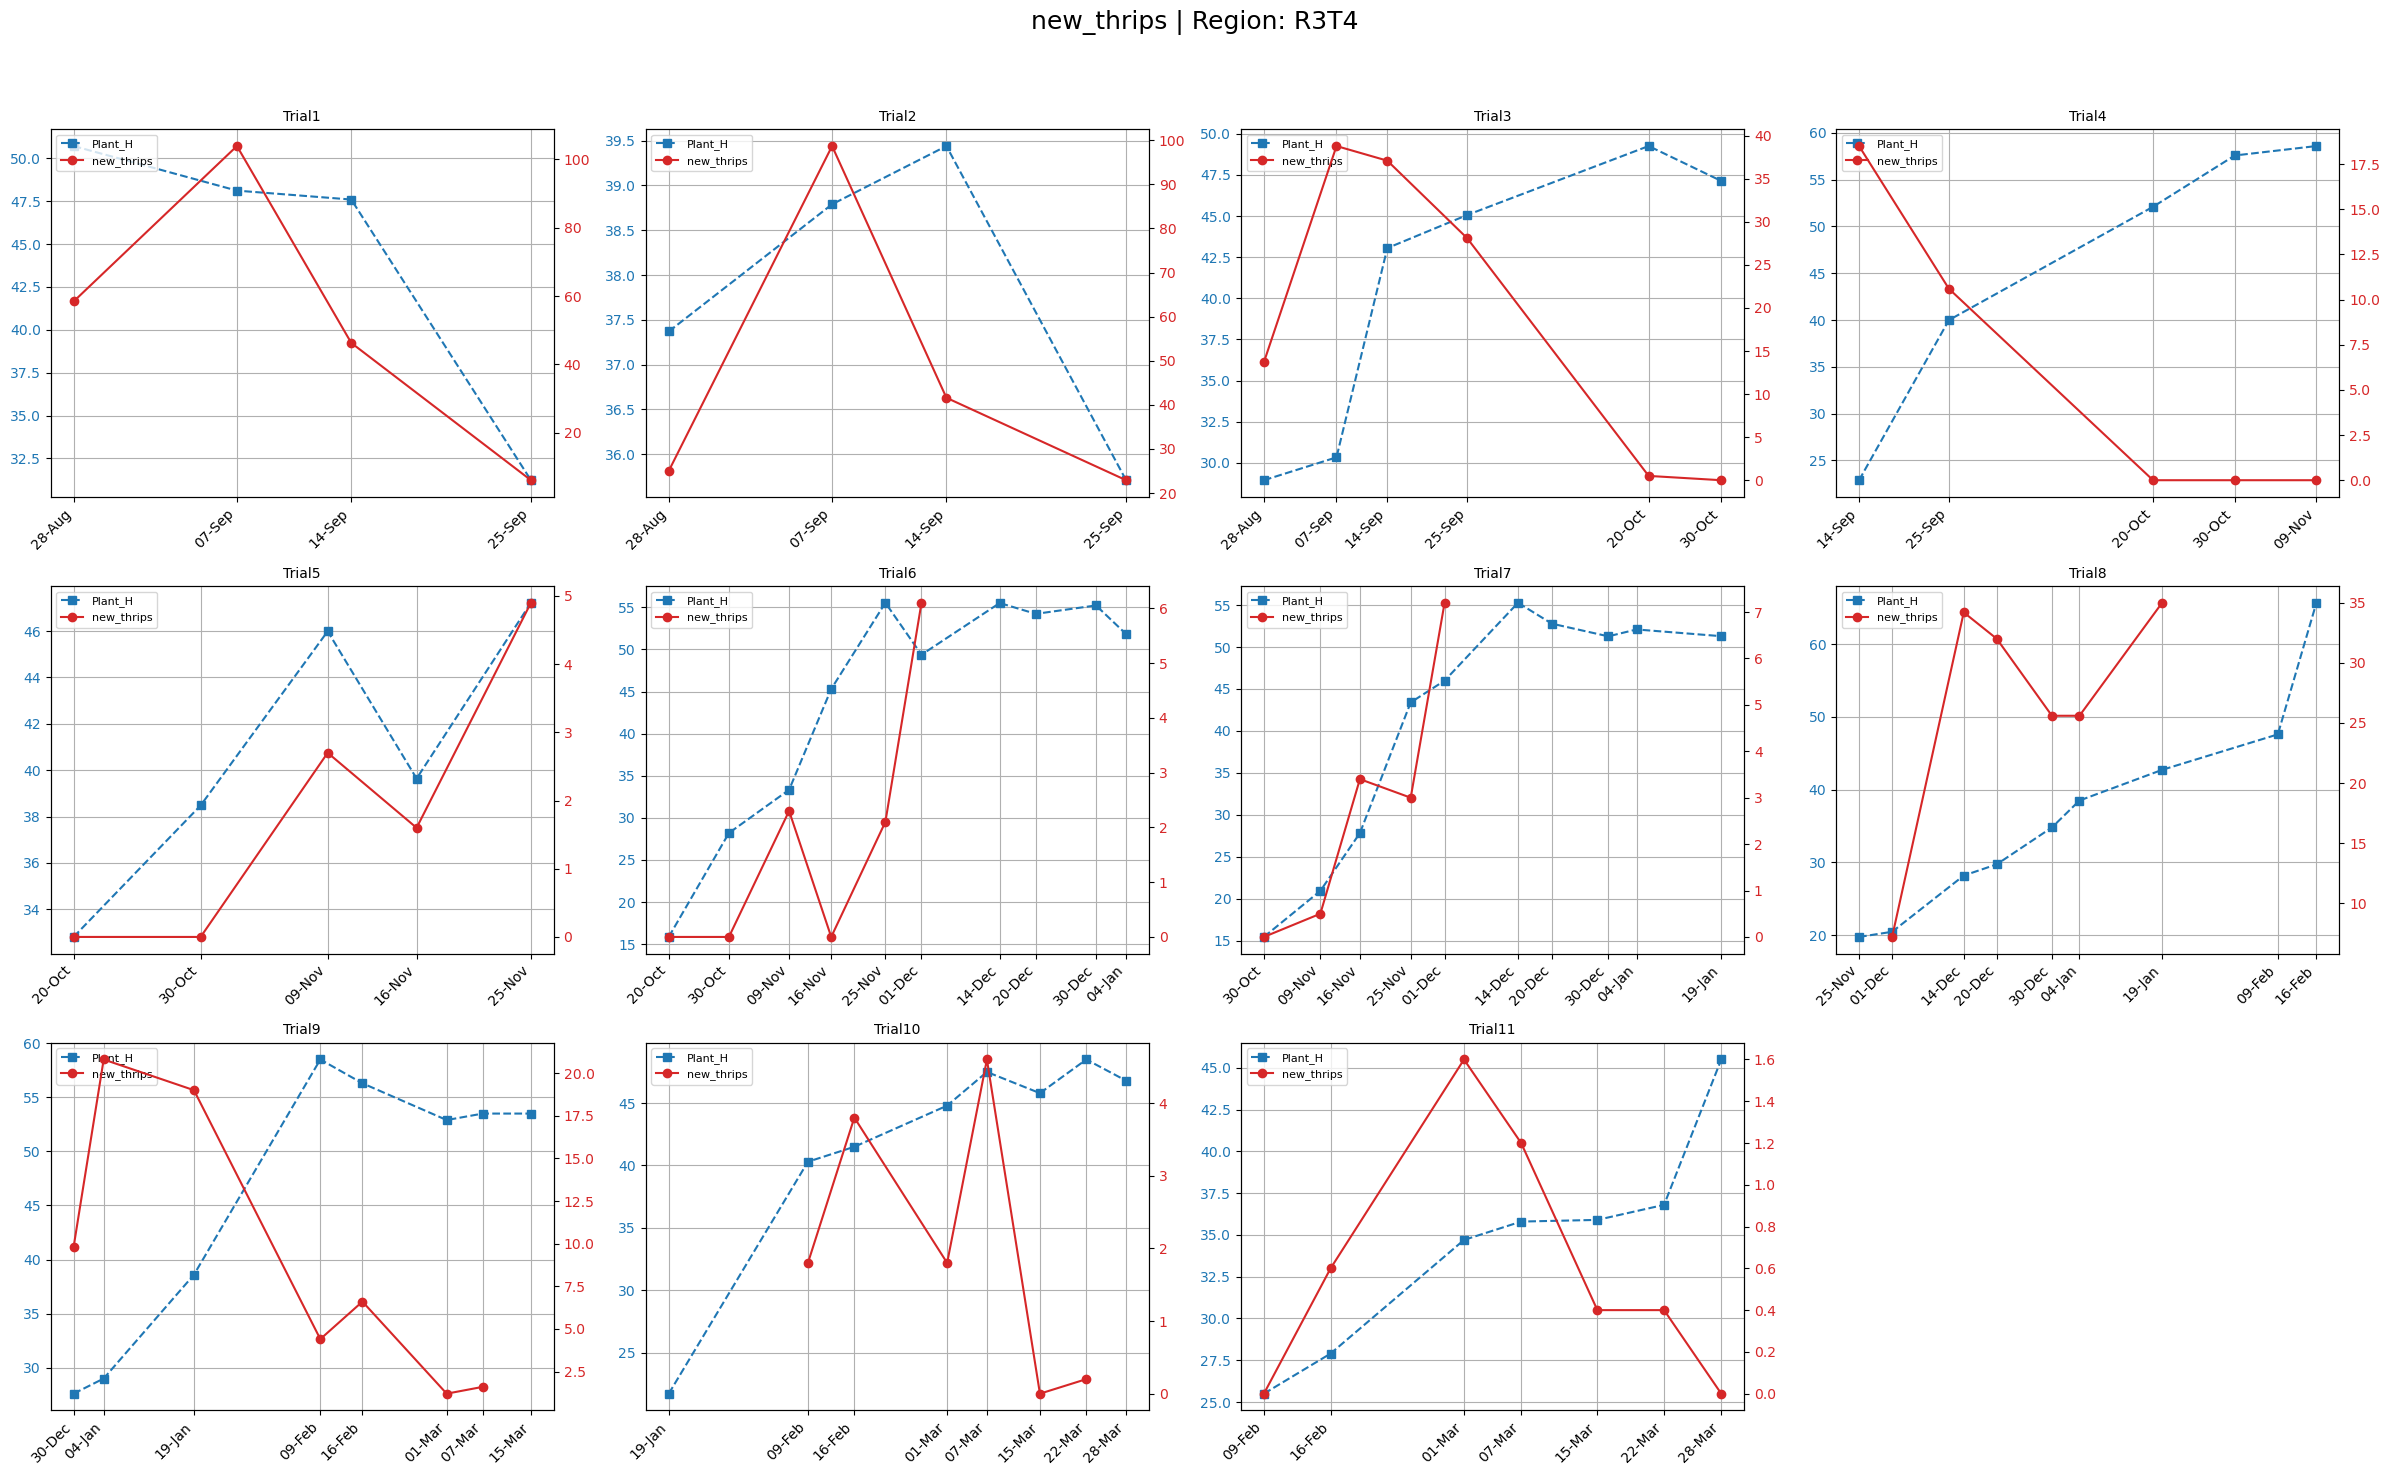

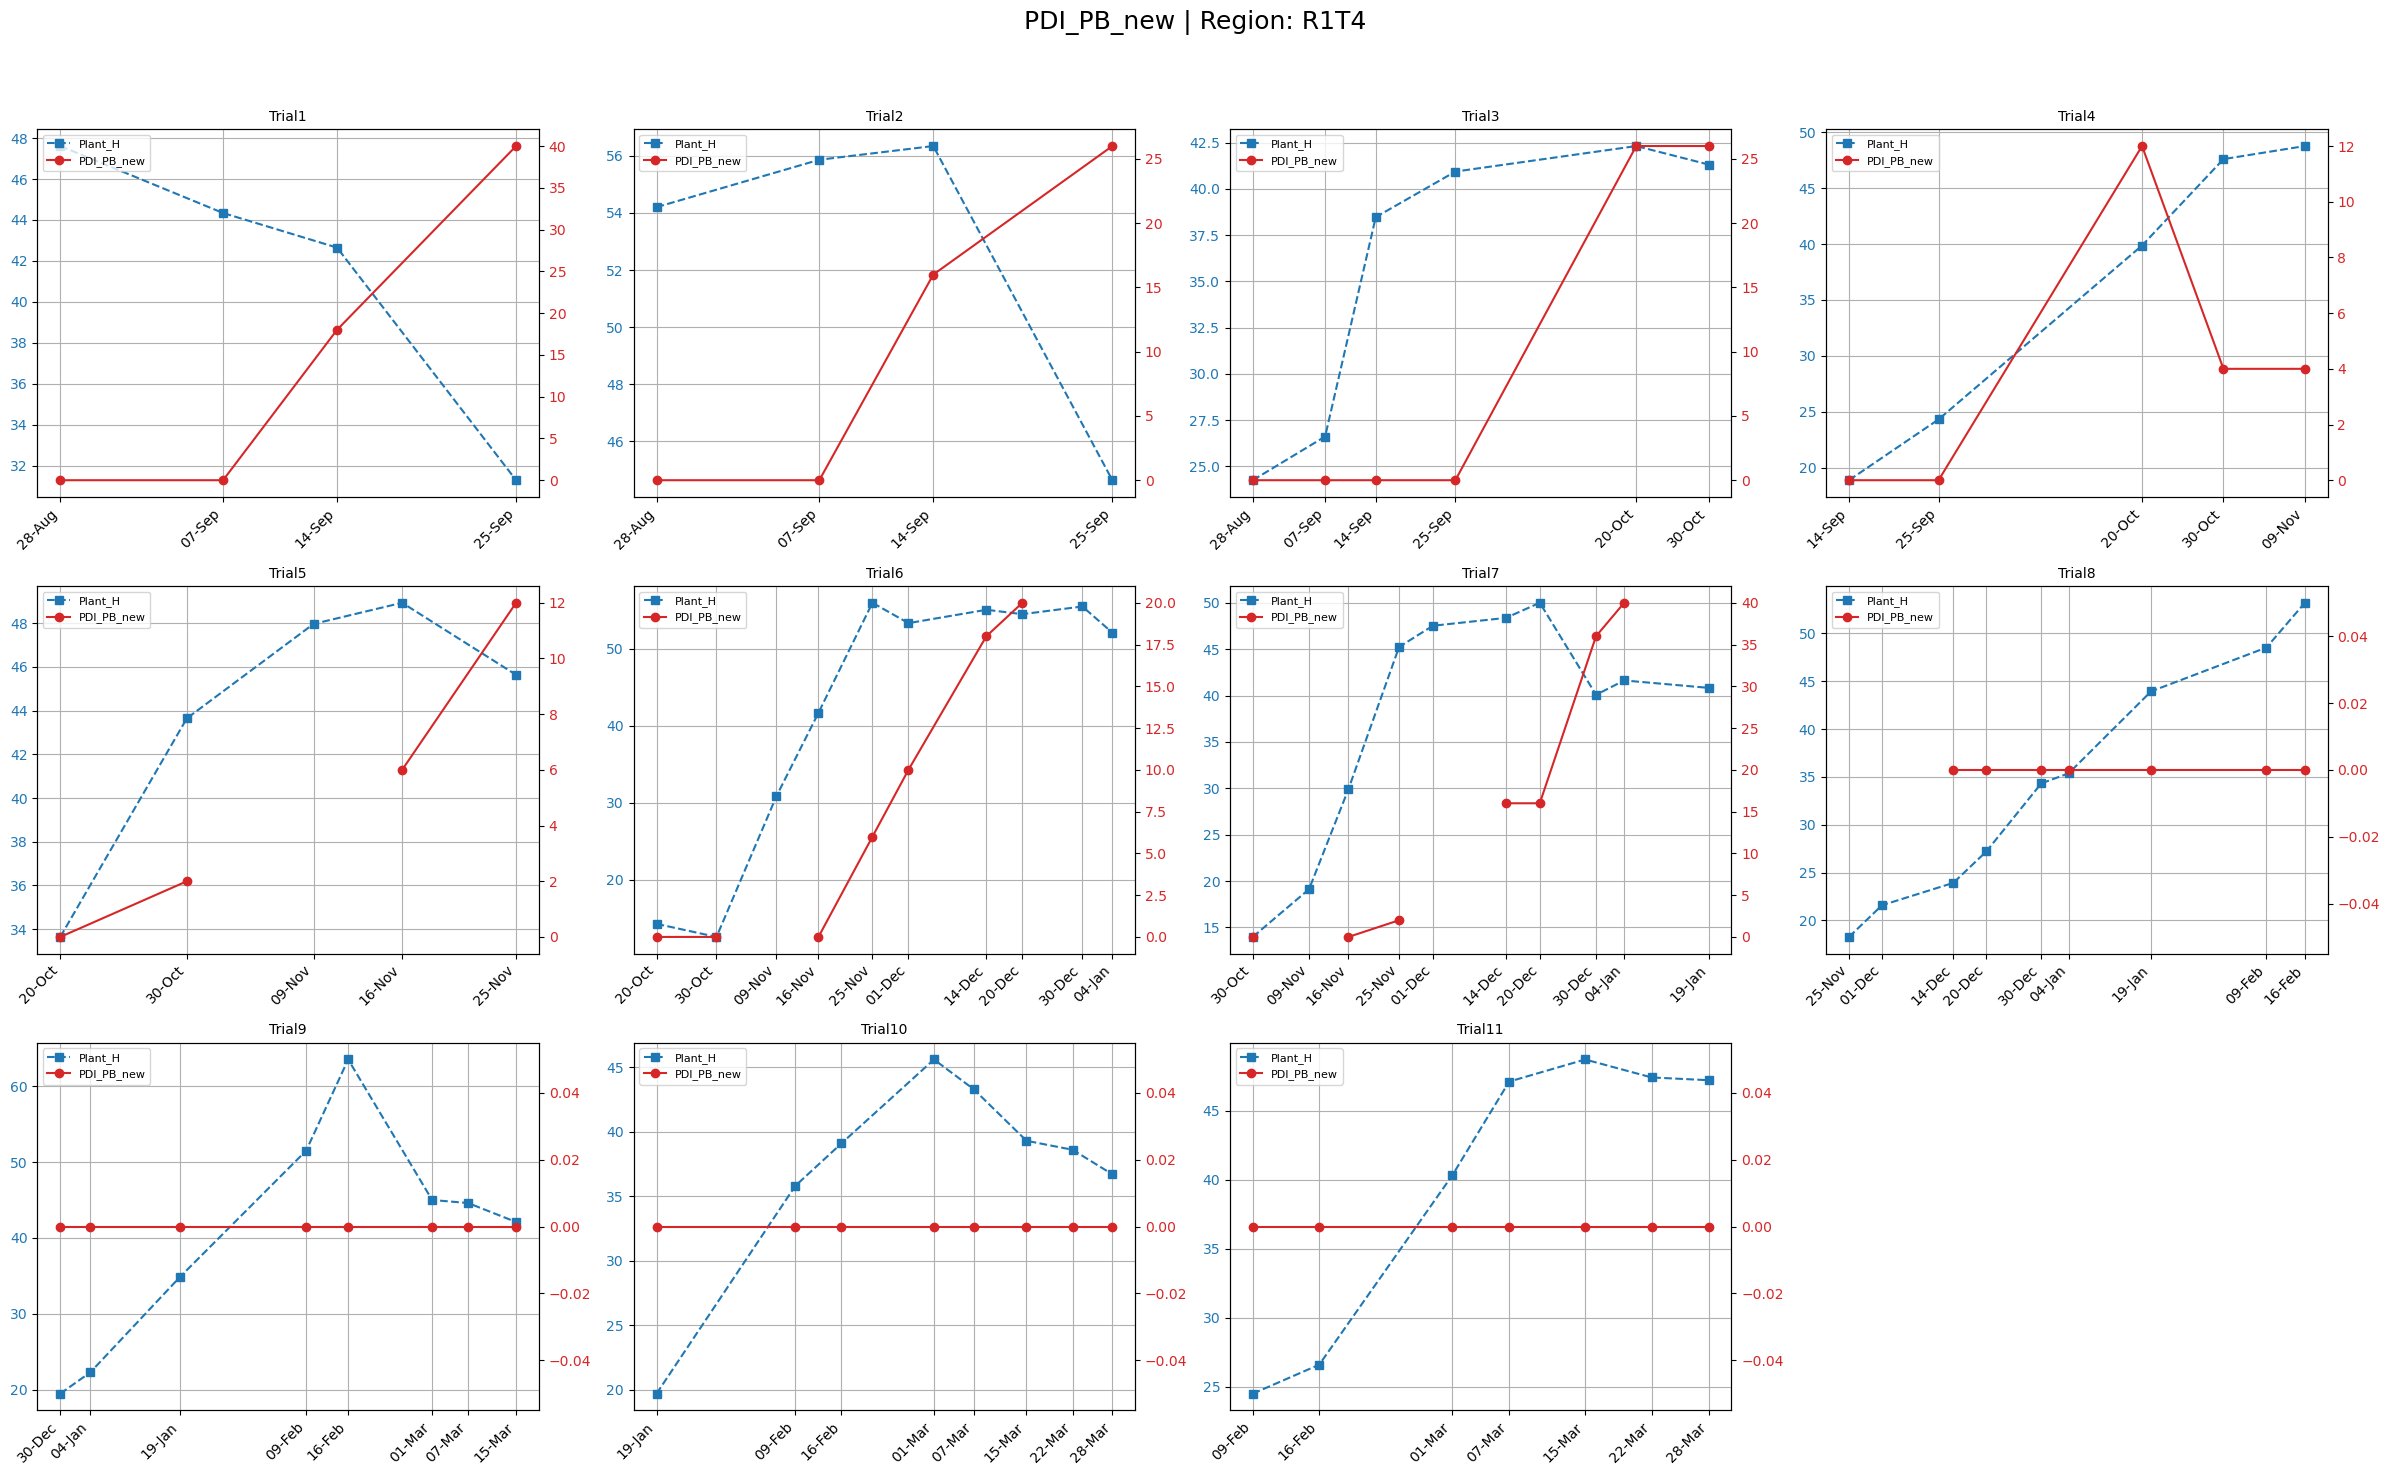

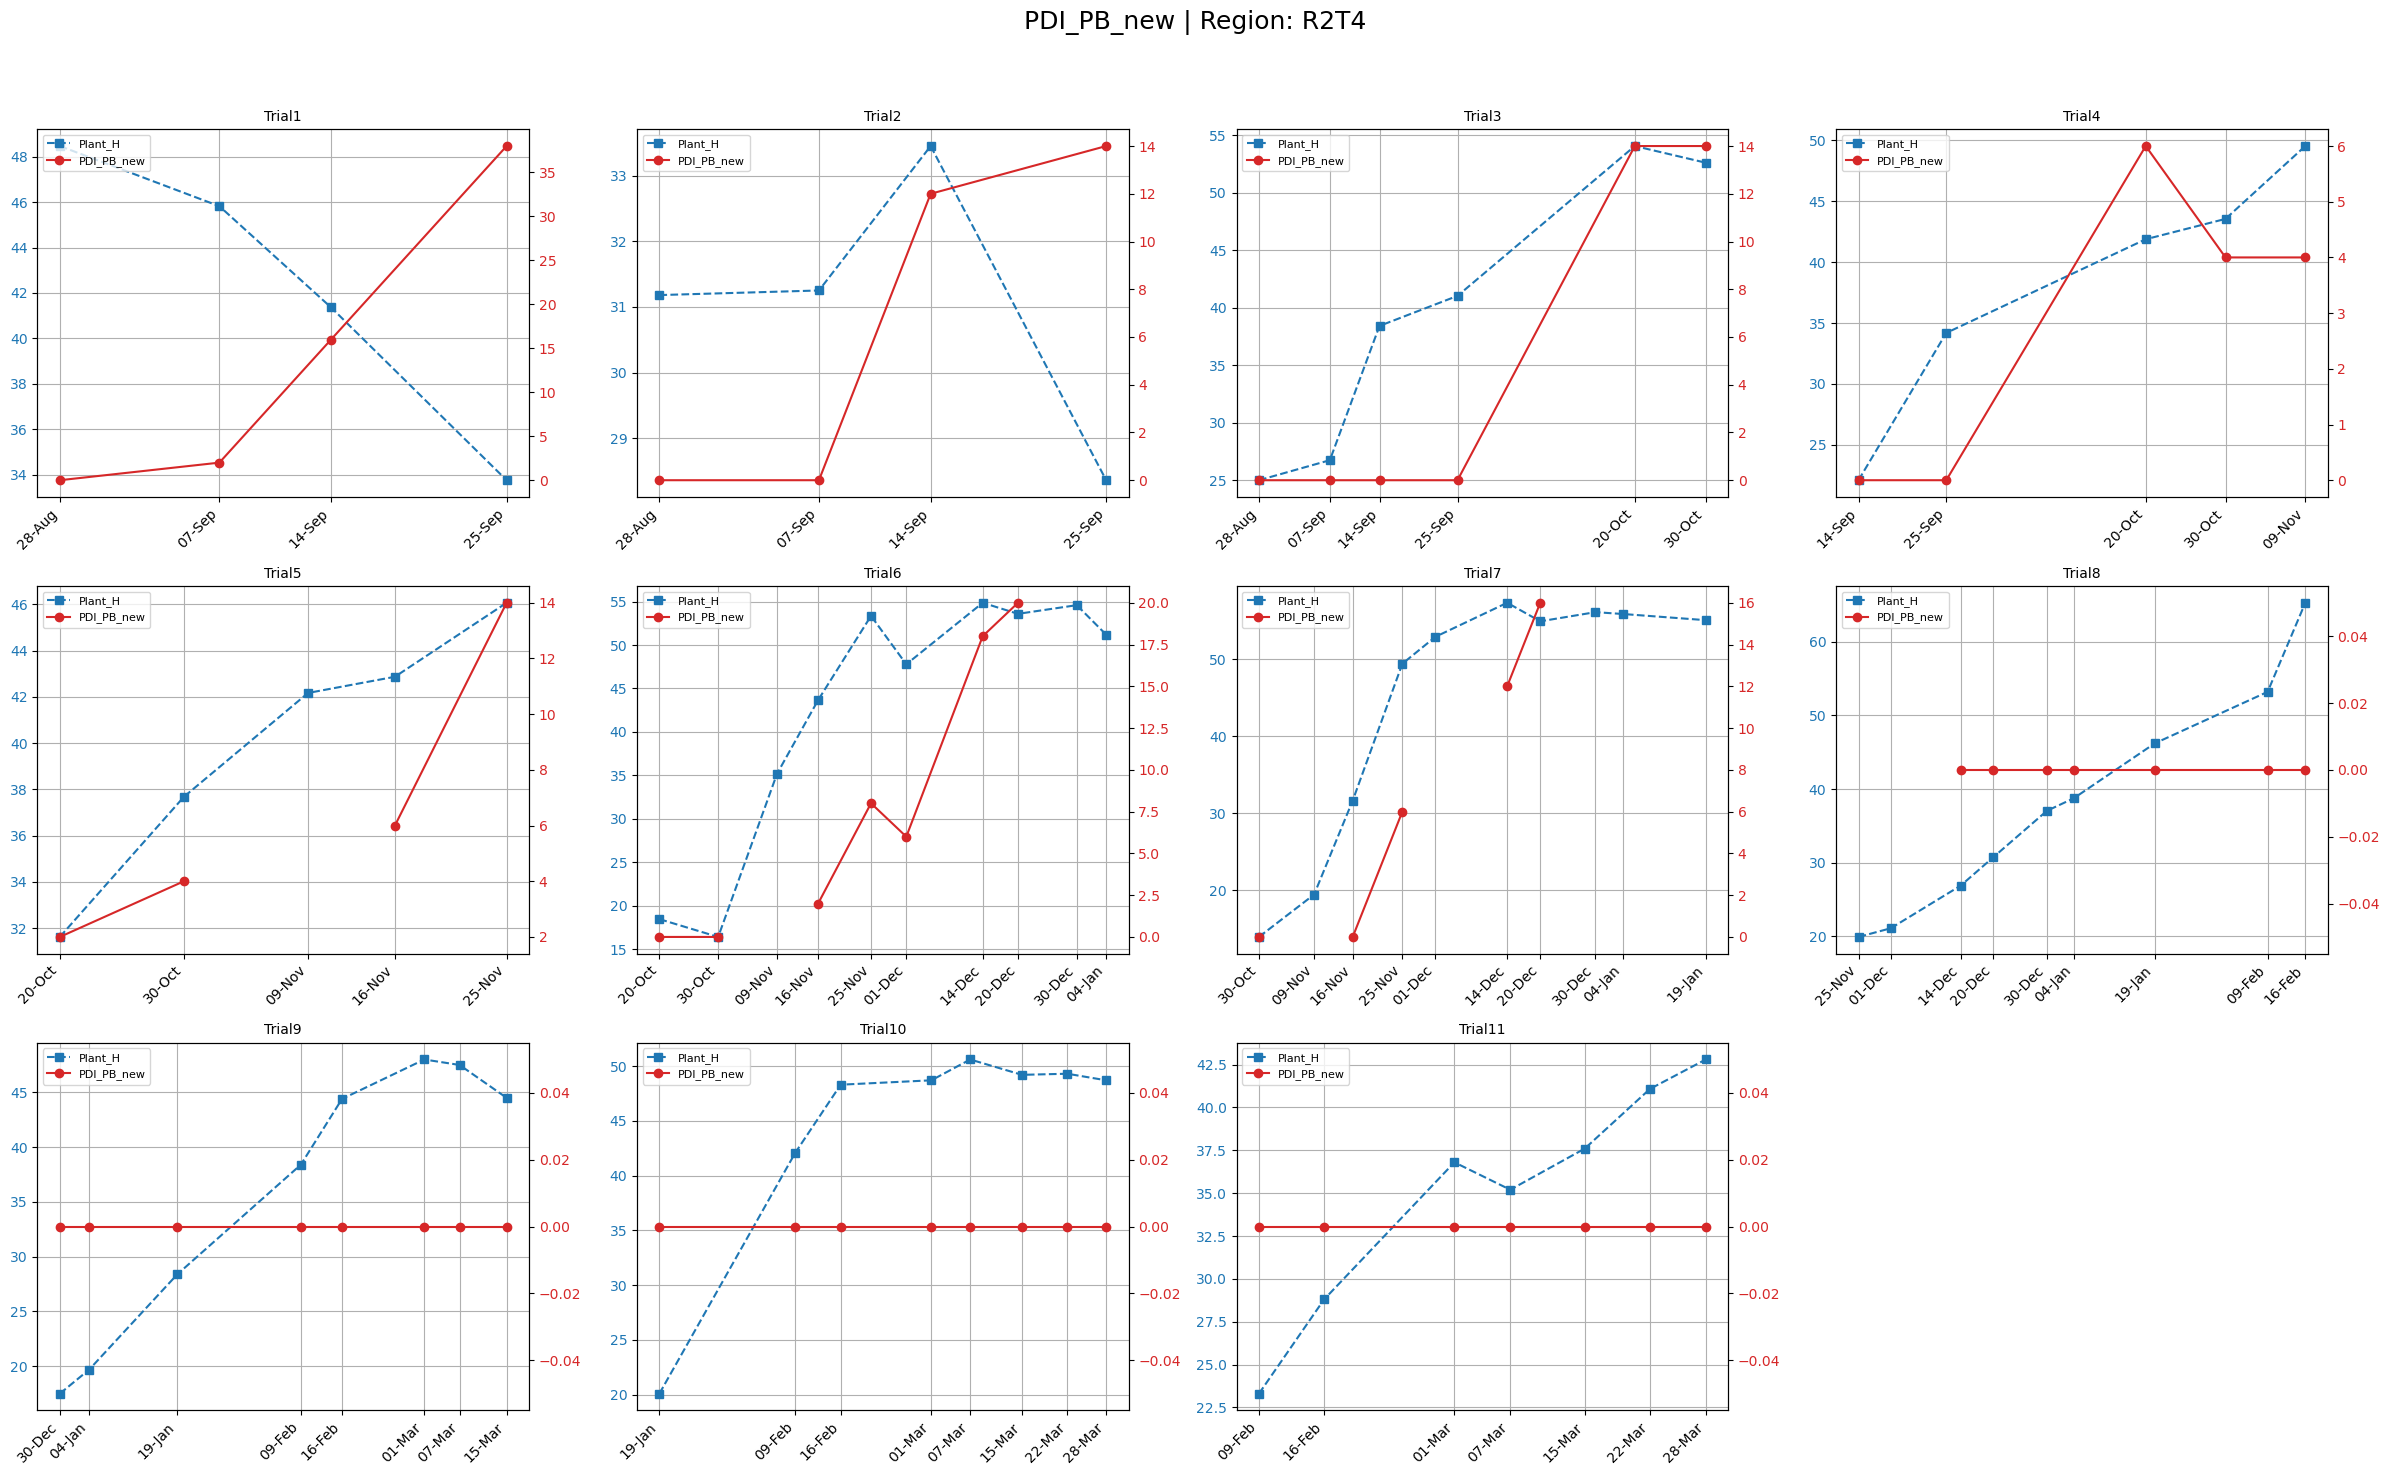

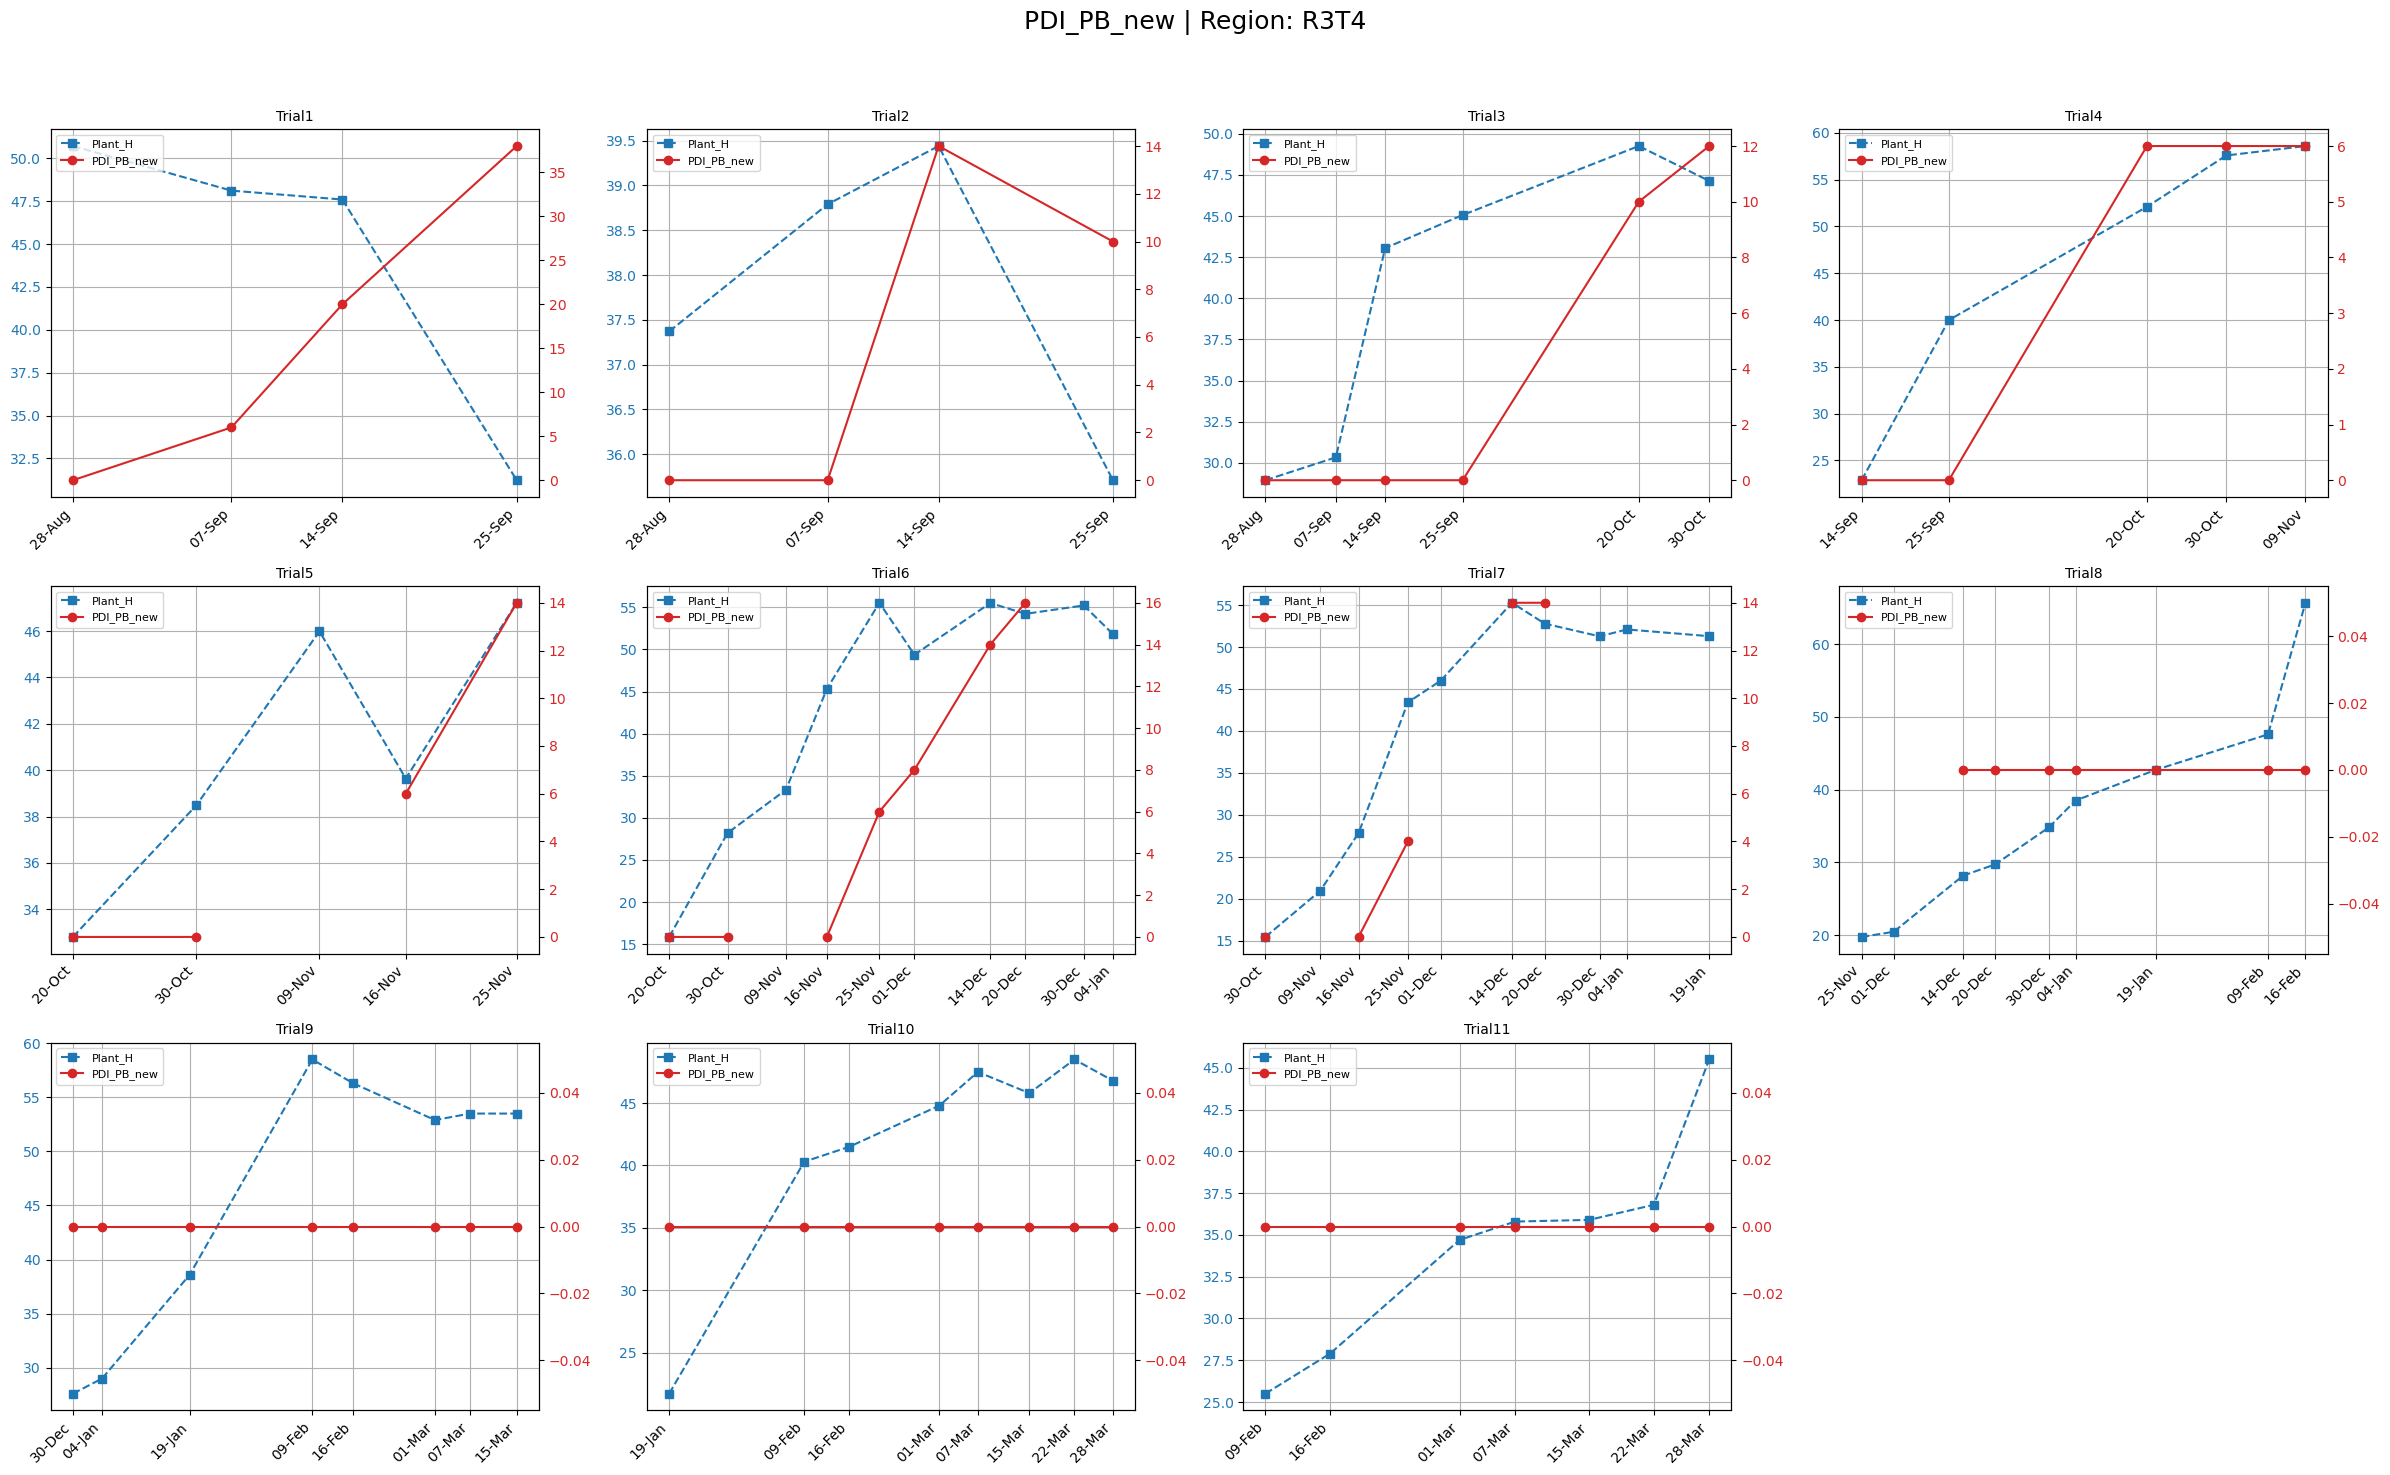

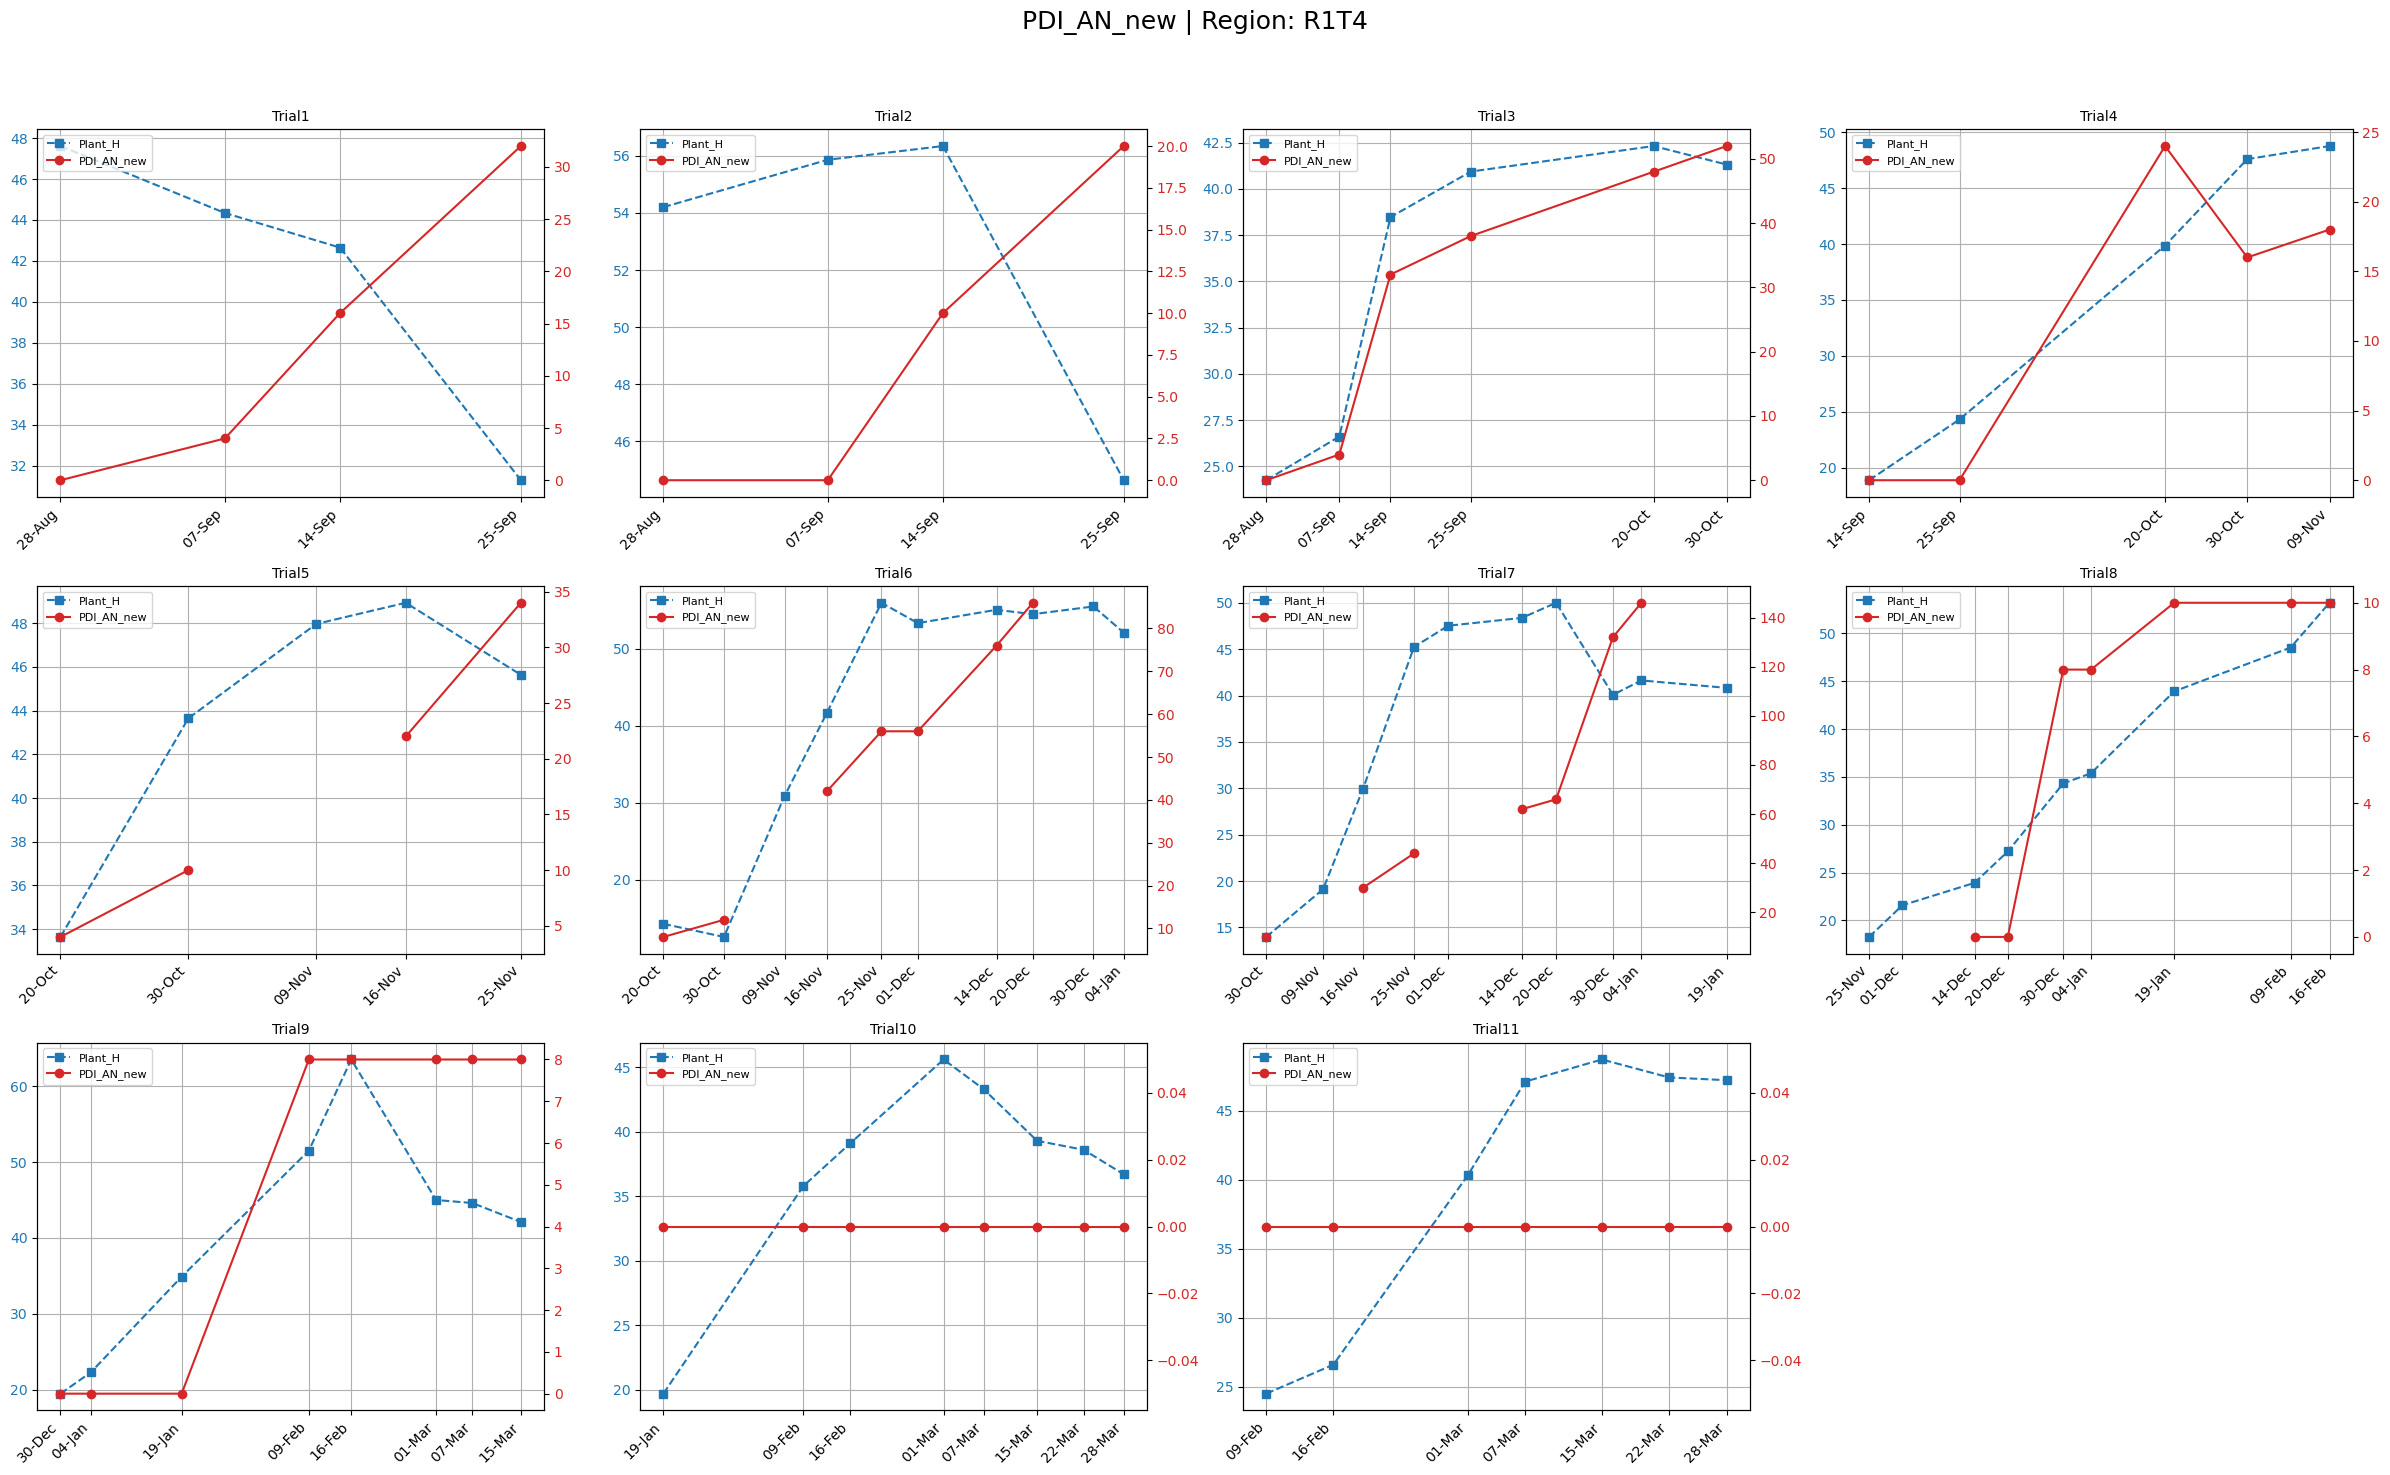

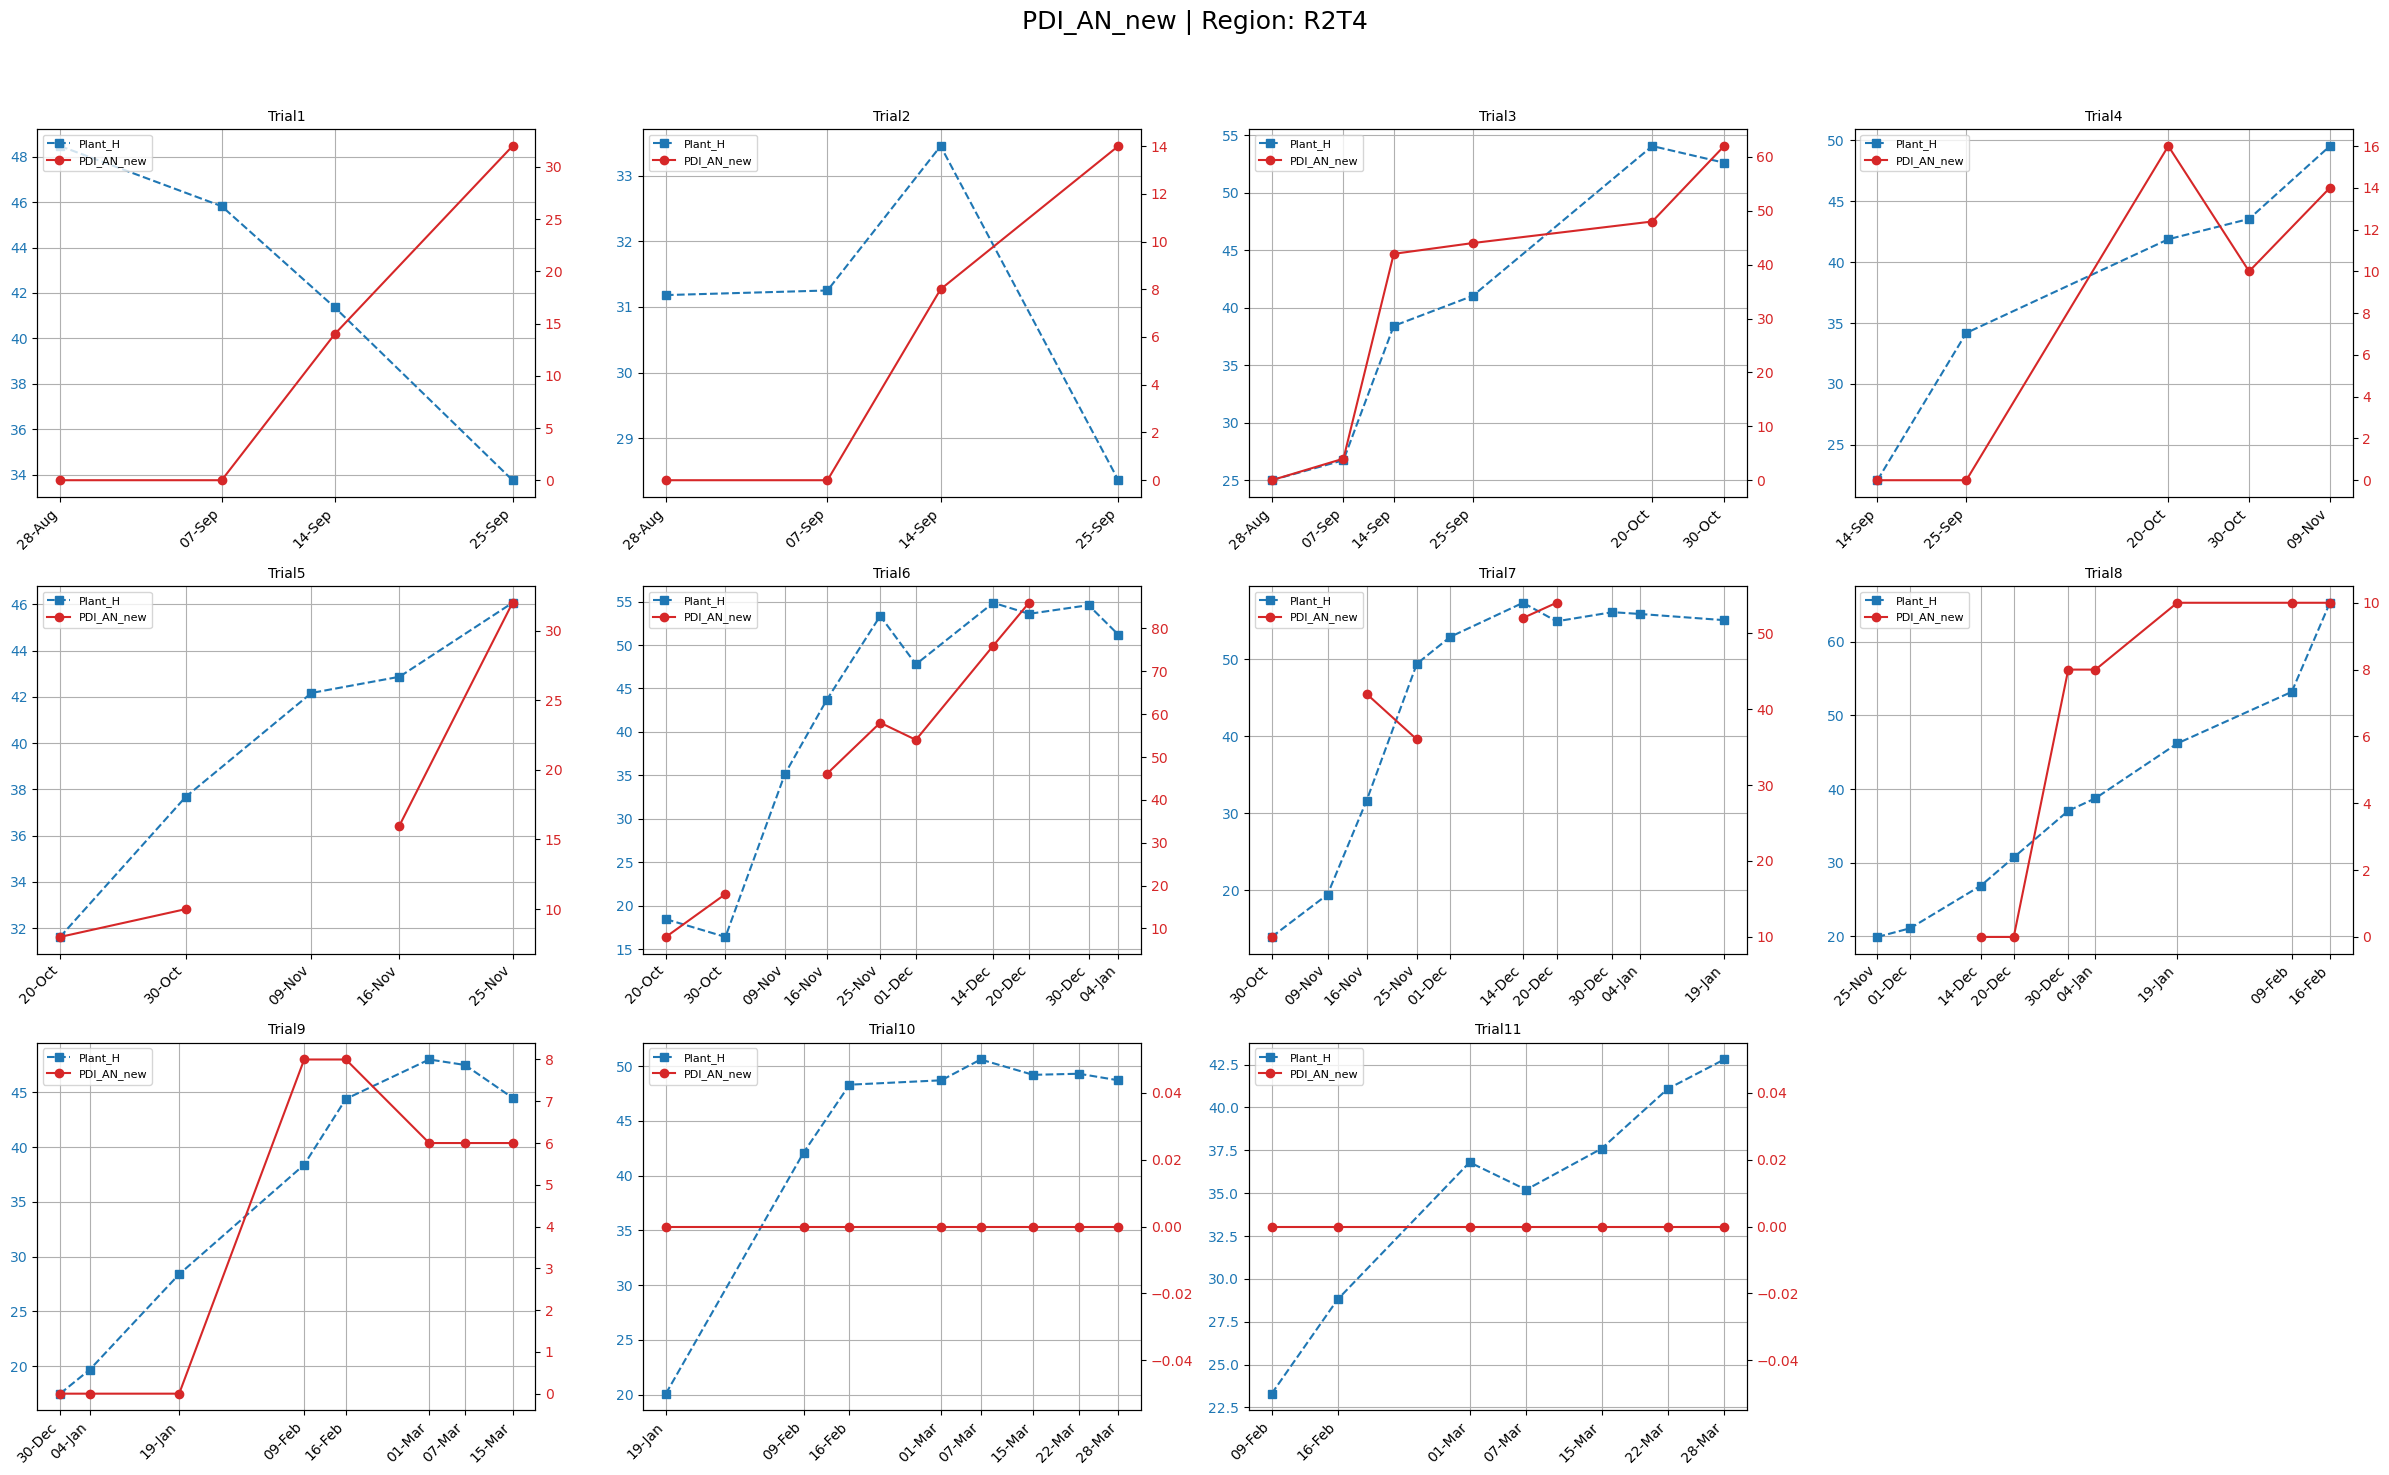

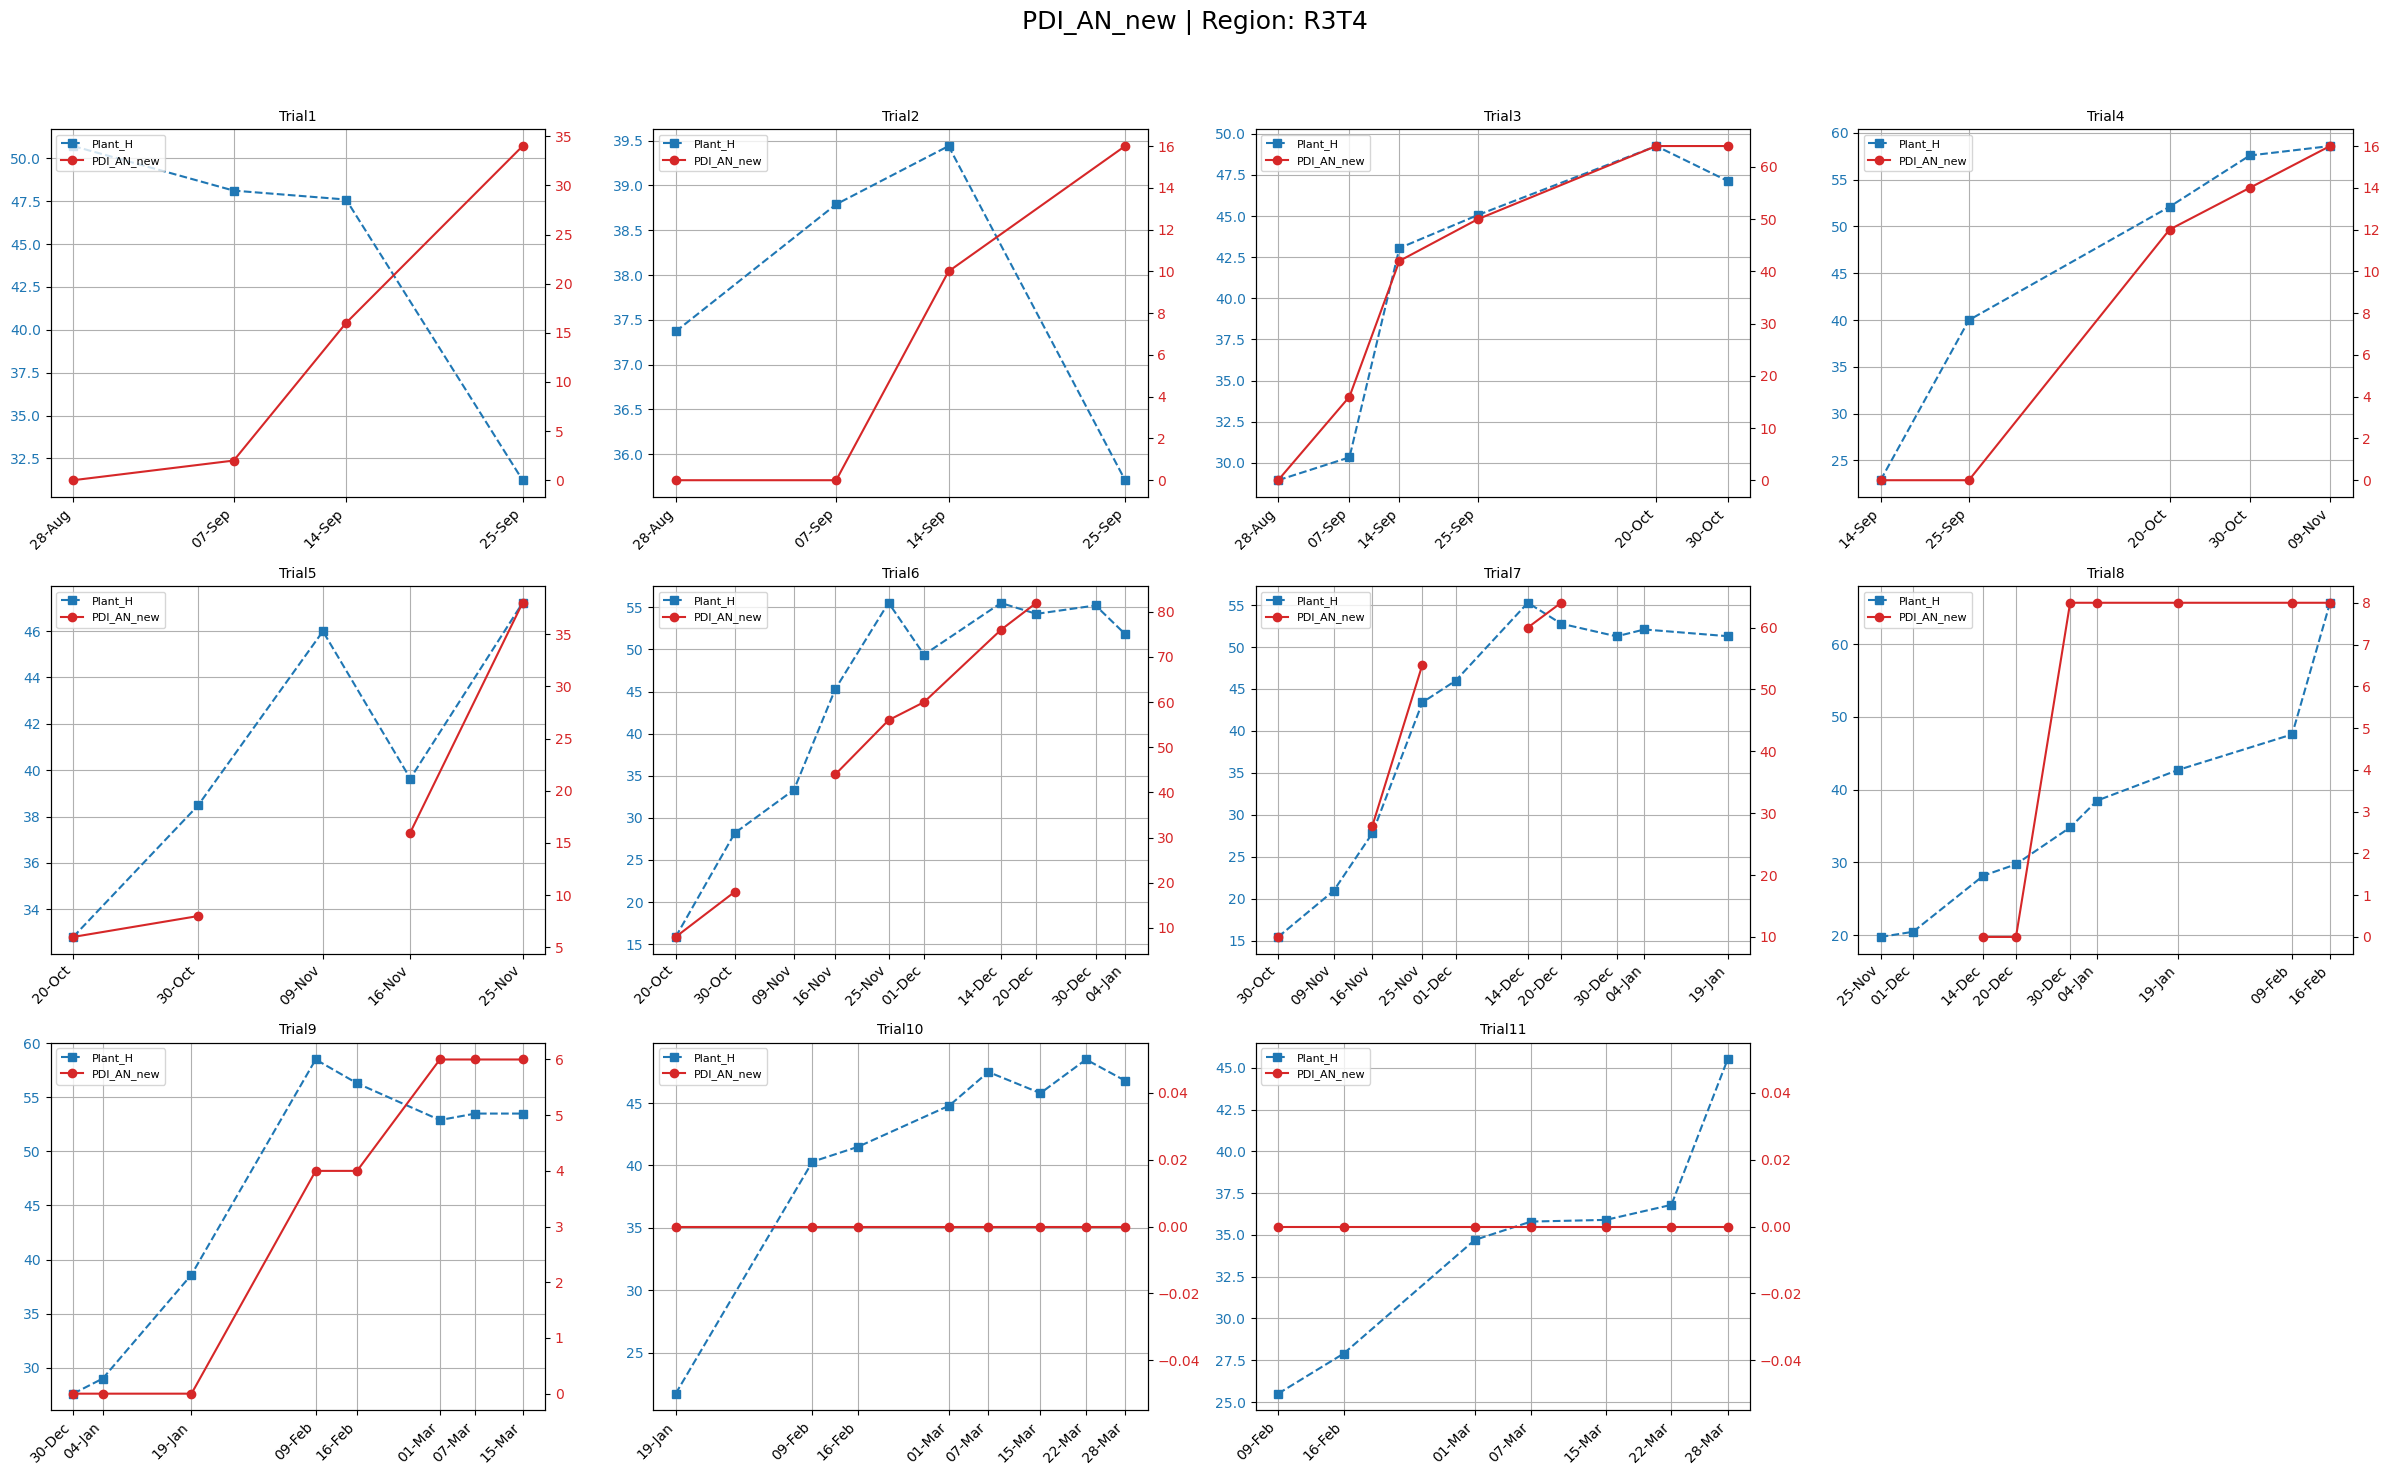

In [8]:
import matplotlib.pyplot as plt
from collections import defaultdict
from datetime import datetime
import math

# Inputs
region_list = ['R1T4', 'R2T4', 'R3T4']
disease_metrics = ['PDI_SB_new', 'new_thrips', 'PDI_PB_new', 'PDI_AN_new']
cols = 4  # 4 subplots per row

for metric in disease_metrics:
    for region in region_list:
        # Get all trials where this region exists
        valid_trials = [
            trial_name for trial_name, trial_data in combined_data.items()
            if region in trial_data and any(isinstance(r.get('Date'), datetime) for r in trial_data[region])
        ]

        if not valid_trials:
            print(f"⚠️ No valid data for {region} - {metric}")
            continue

        num_plots = len(valid_trials)
        rows = math.ceil(num_plots / cols)

        # Create subplots
        fig, axes = plt.subplots(rows, cols, figsize=(6 * cols, 5 * rows), squeeze=False)
        fig.suptitle(f"{metric} | Region: {region}", fontsize=18)

        for idx, trial_name in enumerate(valid_trials):
            row, col = divmod(idx, cols)
            ax1 = axes[row][col]

            records = combined_data[trial_name][region]

            # Group data by date
            grouped = defaultdict(dict)
            for rec in records:
                date = rec['Date']
                grouped[date].update(rec)

            dates = sorted(grouped.keys())
            if not dates:
                continue

            # Extract y-values
            plant_heights = [grouped[dt].get('Plant_H') for dt in dates]
            y_metric = [grouped[dt].get(metric) for dt in dates]

            # Plot Plant Height on left Y
            ax1.plot(dates, plant_heights, linestyle='--', marker='s', color='#1f77b4', label='Plant_H')
            ax1.tick_params(axis='y', labelcolor='#1f77b4')

            # Set X-axis ticks only for available dates
            ax1.set_xticks(dates)
            ax1.set_xticklabels([dt.strftime('%d-%b') for dt in dates], rotation=45, ha='right')

            # Plot disease on right Y
            ax2 = ax1.twinx()
            ax2.plot(dates, y_metric, linestyle='-', marker='o', color='#d62728', label=metric)
            ax2.tick_params(axis='y', labelcolor='#d62728')

            # Combined legend
            lines1, labels1 = ax1.get_legend_handles_labels()
            lines2, labels2 = ax2.get_legend_handles_labels()
            ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=8, loc='upper left')

            ax1.set_title(trial_name, fontsize=10)
            ax1.grid(True)

        # Hide extra subplots if total < rows × cols
        for idx in range(num_plots, rows * cols):
            row, col = divmod(idx, cols)
            fig.delaxes(axes[row][col])

        plt.tight_layout(rect=[0, 0, 1, 0.95])
        plt.show()


In [13]:
import pandas as pd
from collections import defaultdict
from scipy.stats import pearsonr

# Aggregation per date per region
region_data = defaultdict(lambda: defaultdict(dict))

trial_name = 'Trial1'  # choose your trial
region_name = 'R1T4'   # choose your region

for record in combined_data[trial_name][region_name]:
    date = record['Date']
    for key in record:
        if key != 'Date':
            region_data[date][key] = record[key]

# Build DataFrame
df = pd.DataFrame.from_dict(region_data, orient='index').sort_index()
print("\n✅ Aggregated DataFrame:")
print(df)

# Drop rows with missing values (optional, depending on your analysis needs)
df_clean = df.dropna()

# Calculate Pearson correlations
correlations = {}
for col in ['PDI_SB_new', 'new_thrips', 'PDI_PB_new', 'PDI_AN_new']:
    if col in df_clean.columns:
        corr, _ = pearsonr(df_clean['Plant_H'], df_clean[col])
        correlations[col] = corr

print("\n📊 Pearson correlation between Plant Height and Disease Metrics:")
for metric, corr in correlations.items():
    print(f"{metric} vs Plant_H: {corr:.3f}")



✅ Aggregated DataFrame:
            PDI_SB_new  Plant_H  new_thrips  PDI_PB_new  PDI_AN_new
2023-08-28           0    47.61        56.5           0           0
2023-09-07           4    44.34       100.7           0           4
2023-09-14          20    42.65        44.8          18          16
2023-09-25          36    31.29         6.0          40          32

📊 Pearson correlation between Plant Height and Disease Metrics:
PDI_SB_new vs Plant_H: -0.947
new_thrips vs Plant_H: 0.756
PDI_PB_new vs Plant_H: -0.955
PDI_AN_new vs Plant_H: -0.966


In [15]:
import pandas as pd
import numpy as np
from scipy.stats import pearsonr

# -----------------------------
# Step 1: Flatten combined_data
# -----------------------------
flat_data = []

for trial_name, trial_data in combined_data.items():
    for region, entries in trial_data.items():  # region → list of dicts
        for entry in entries:
            flat_entry = {
                'Trial': trial_name,
                'Region': region,
                'Date': entry['Date']
            }
            for key, val in entry.items():
                if key != 'Date':
                    flat_entry[key] = val
            flat_data.append(flat_entry)

df = pd.DataFrame(flat_data)

# -----------------------------
# Step 2: Clean and filter data
# -----------------------------
df = df.apply(pd.to_numeric, errors='ignore')

numeric_df = df.select_dtypes(include=[np.number])
numeric_df = numeric_df.loc[:, numeric_df.std() != 0]  # remove constant cols

# -----------------------------
# Step 3: Loop through all metrics
# -----------------------------
target_metrics = ['PDI_SB_new', 'new_thrips', 'PDI_PB_new', 'PDI_AN_new']
results = []

for metric in target_metrics:
    if metric not in numeric_df.columns:
        continue

    print(f"\n--- Correlation for: {metric} ---")
    for col in numeric_df.columns:
        if col == metric:
            continue

        x = numeric_df[metric].replace([np.inf, -np.inf], np.nan)
        y = numeric_df[col].replace([np.inf, -np.inf], np.nan)
        valid = x.notna() & y.notna()

        if valid.sum() > 2:
            try:
                corr, pval = pearsonr(x[valid], y[valid])
                print(f"{col:25s} : Correlation = {corr:+.3f}, p-value = {pval:.4f}")
                results.append({
                    'Metric': metric,
                    'Variable': col,
                    'Correlation': round(corr, 4),
                    'P-value': round(pval, 6)
                })
            except Exception as e:
                print(f"{col:25s} : Error - {e}")



--- Correlation for: PDI_SB_new ---
Date                      : Correlation = -0.100, p-value = 0.1601
Plant_H                   : Correlation = +0.378, p-value = 0.0000

--- Correlation for: new_thrips ---
Date                      : Correlation = -0.458, p-value = 0.0000
Plant_H                   : Correlation = +0.033, p-value = 0.6612

--- Correlation for: PDI_PB_new ---
Date                      : Correlation = -0.280, p-value = 0.0001
Plant_H                   : Correlation = +0.218, p-value = 0.0021

--- Correlation for: PDI_AN_new ---
Date                      : Correlation = -0.204, p-value = 0.0041
Plant_H                   : Correlation = +0.340, p-value = 0.0000


/tmp/ipykernel_18586/2472324468.py:28: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df = df.apply(pd.to_numeric, errors='ignore')


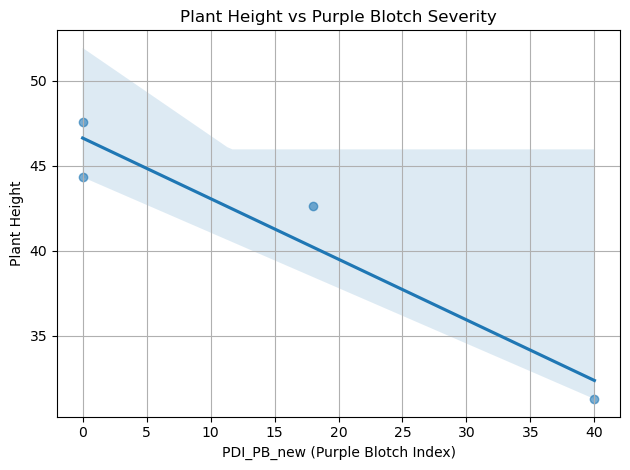

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.regplot(data=df_clean, x='PDI_PB_new', y='Plant_H', scatter_kws={'alpha':0.6})
plt.title('Plant Height vs Purple Blotch Severity')
plt.xlabel('PDI_PB_new (Purple Blotch Index)')
plt.ylabel('Plant Height')
plt.grid(True)
plt.tight_layout()
plt.show()

In [17]:
import pandas as pd
import numpy as np
from scipy.stats import pearsonr

# -----------------------------
# Step 1: Flatten combined_data
# -----------------------------
flat_data = []

for trial_name, trial_data in combined_data.items():
    for region, entries in trial_data.items():  # region → list of dicts
        for entry in entries:
            flat_entry = {
                'Trial': trial_name,
                'Region': region,
                'Date': entry['Date']
            }
            for key, val in entry.items():
                if key != 'Date':
                    flat_entry[key] = val
            flat_data.append(flat_entry)

df = pd.DataFrame(flat_data)

# -----------------------------
# Step 2: Clean data
# -----------------------------
df = df.apply(pd.to_numeric, errors='ignore')

# -----------------------------
# Step 3: Correlation per (Trial, Region)
# -----------------------------
target_metrics = ['PDI_SB_new', 'new_thrips', 'PDI_PB_new', 'PDI_AN_new']
results = []

grouped = df.groupby(['Trial', 'Region'])

for (trial, region), group in grouped:
    for metric in target_metrics:
        if metric not in group.columns or 'Plant_H' not in group.columns:
            continue

        x = group[metric].replace([np.inf, -np.inf], np.nan)
        y = group['Plant_H'].replace([np.inf, -np.inf], np.nan)
        valid = x.notna() & y.notna()

        if valid.sum() > 2:
            try:
                corr, pval = pearsonr(x[valid], y[valid])
                results.append({
                    'Trial': trial,
                    'Region': region,
                    'Metric': metric,
                    'Correlation': round(corr, 4),
                    'P-value': round(pval, 6)
                })
            except Exception as e:
                results.append({
                    'Trial': trial,
                    'Region': region,
                    'Metric': metric,
                    'Correlation': np.nan,
                    'P-value': np.nan,
                    'Error': str(e)
                })

# -----------------------------
# Step 4: Display or export
# -----------------------------
results_df = pd.DataFrame(results)
pd.set_option('display.max_rows', 100)
print(results_df)

# Optional: Save to CSV
# results_df.to_csv("trial_region_correlation_results.csv", index=False)


      Trial Region      Metric  Correlation   P-value
0    Trial1   R1T4  PDI_SB_new      -0.9470  0.053026
1    Trial1   R1T4  new_thrips       0.7559  0.244056
2    Trial1   R1T4  PDI_PB_new      -0.9549  0.045099
3    Trial1   R1T4  PDI_AN_new      -0.9660  0.034009
4    Trial1   R2T4  PDI_SB_new      -0.9963  0.003671
..      ...    ...         ...          ...       ...
127  Trial9   R2T4  PDI_AN_new       0.8760  0.004338
128  Trial9   R3T4  PDI_SB_new       0.9041  0.002046
129  Trial9   R3T4  new_thrips      -0.7605  0.047141
130  Trial9   R3T4  PDI_PB_new          NaN       NaN
131  Trial9   R3T4  PDI_AN_new       0.8742  0.004519

[132 rows x 5 columns]


/tmp/ipykernel_18586/2749289250.py:28: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df = df.apply(pd.to_numeric, errors='ignore')
/tmp/ipykernel_18586/2749289250.py:49: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, pval = pearsonr(x[valid], y[valid])


In [18]:
sig_corr = results_df[results_df['P-value'] < 0.05]
print(sig_corr.sort_values(by='Correlation'))

      Trial Region      Metric  Correlation   P-value
4    Trial1   R2T4  PDI_SB_new      -0.9963  0.003671
6    Trial1   R2T4  PDI_PB_new      -0.9922  0.007831
7    Trial1   R2T4  PDI_AN_new      -0.9858  0.014227
69   Trial4   R3T4  new_thrips      -0.9829  0.002683
3    Trial1   R1T4  PDI_AN_new      -0.9660  0.034009
8    Trial1   R3T4  PDI_SB_new      -0.9646  0.035353
65   Trial4   R2T4  new_thrips      -0.9629  0.008517
2    Trial1   R1T4  PDI_PB_new      -0.9549  0.045099
61   Trial4   R1T4  new_thrips      -0.9444  0.015613
129  Trial9   R3T4  new_thrips      -0.7605  0.047141
90   Trial6   R2T4  PDI_PB_new       0.7694  0.043142
84   Trial6   R1T4  PDI_SB_new       0.7738  0.041203
115  Trial8   R2T4  PDI_AN_new       0.8011  0.030362
116  Trial8   R3T4  PDI_SB_new       0.8025  0.029842
123  Trial9   R1T4  PDI_AN_new       0.8424  0.008661
120  Trial9   R1T4  PDI_SB_new       0.8424  0.008661
54   Trial3   R2T4  PDI_PB_new       0.8600  0.028014
52   Trial3   R2T4  PDI_SB_n

/tmp/ipykernel_18586/3822318904.py:10: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/dimple/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


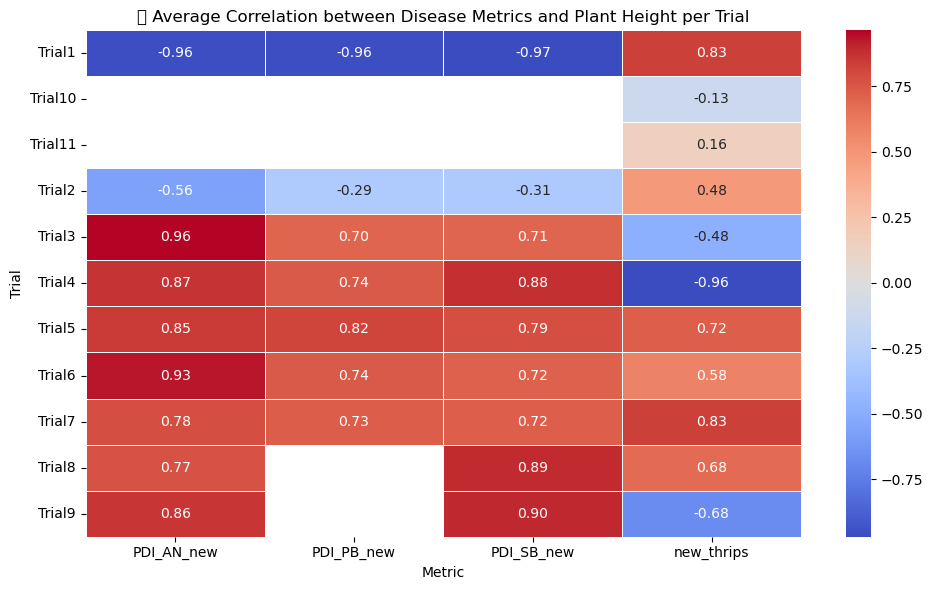

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

# Pivot to Trial × Metric heatmap (aggregating mean correlation)
pivot_df = results_df.pivot_table(index='Trial', columns='Metric', values='Correlation')

plt.figure(figsize=(10, 6))
sns.heatmap(pivot_df, annot=True, cmap='coolwarm', center=0, fmt=".2f", linewidths=0.5)
plt.title('📊 Average Correlation between Disease Metrics and Plant Height per Trial')
plt.tight_layout()
plt.show()


/tmp/ipykernel_18586/686815599.py:30: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df = df.apply(pd.to_numeric, errors='ignore')
/tmp/ipykernel_18586/686815599.py:50: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, pval = pearsonr(x[valid], y[valid])
/tmp/ipykernel_18586/686815599.py:74: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/dimple/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


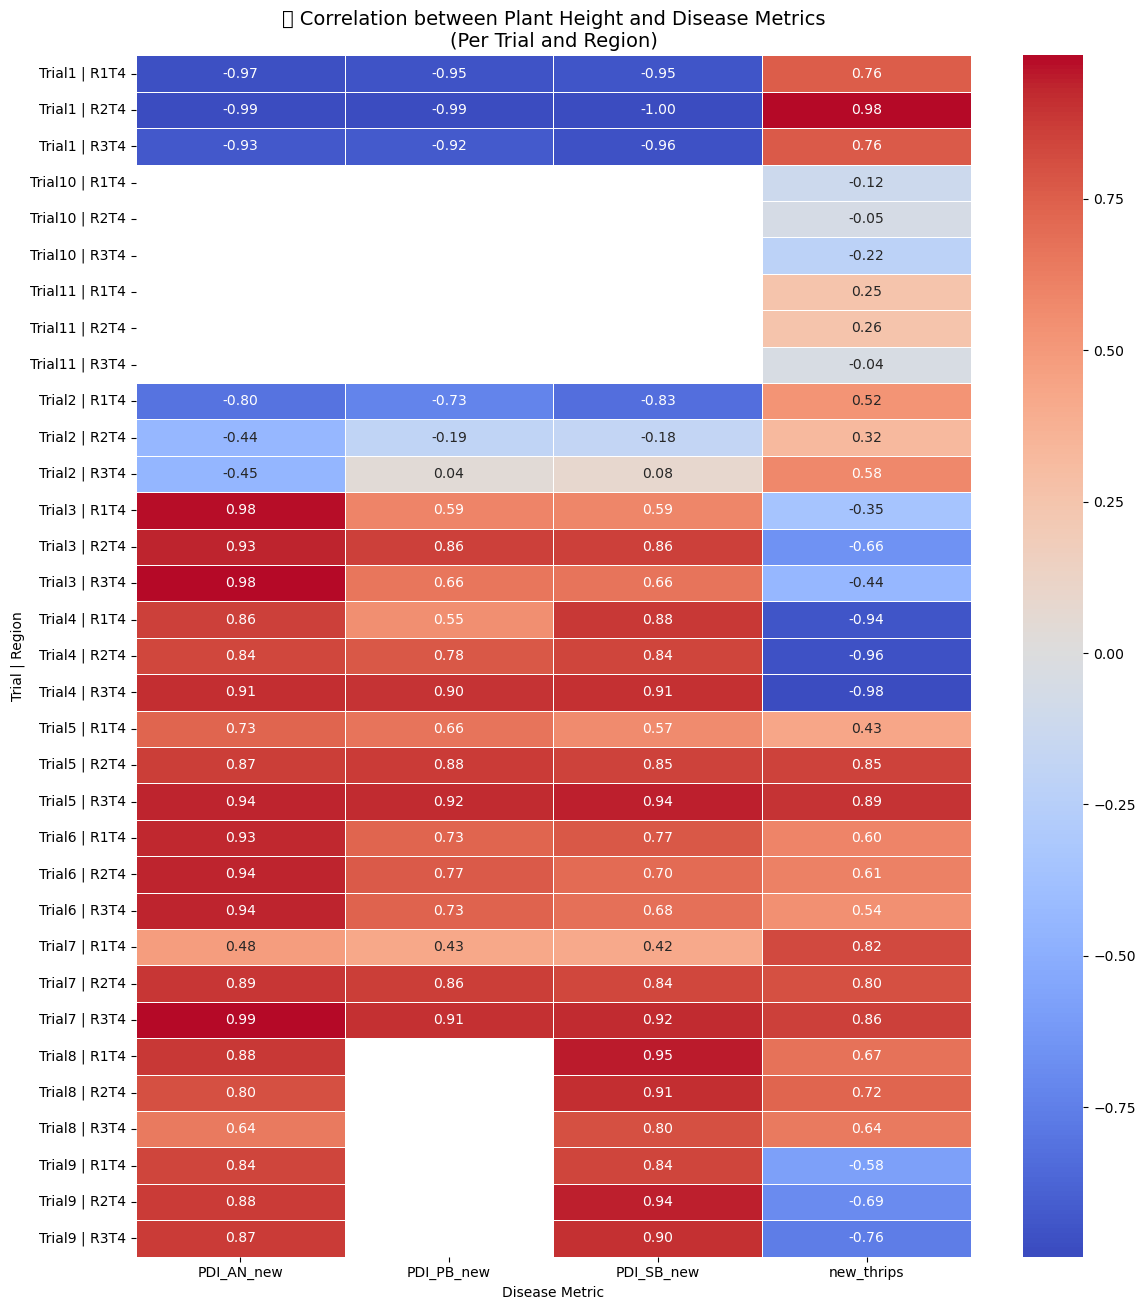

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

# ----------------------------------------
# Step 1: Flatten combined_data
# ----------------------------------------
flat_data = []

for trial_name, trial_data in combined_data.items():
    for region, entries in trial_data.items():  # region maps to a list of dicts
        for entry in entries:
            flat_entry = {
                'Trial': trial_name,
                'Region': region,
                'Date': entry.get('Date')
            }
            for key, val in entry.items():
                if key != 'Date':
                    flat_entry[key] = val
            flat_data.append(flat_entry)

df = pd.DataFrame(flat_data)

# ----------------------------------------
# Step 2: Clean and prepare
# ----------------------------------------
df = df.apply(pd.to_numeric, errors='ignore')
target_metrics = ['PDI_SB_new', 'new_thrips', 'PDI_PB_new', 'PDI_AN_new']

# ----------------------------------------
# Step 3: Compute correlation by (Trial, Region)
# ----------------------------------------
results = []

grouped = df.groupby(['Trial', 'Region'])

for (trial, region), group in grouped:
    group = group.copy()
    group = group.apply(pd.to_numeric, errors='coerce')
    
    for metric in target_metrics:
        if metric in group.columns and 'Plant_H' in group.columns:
            x = group['Plant_H'].replace([np.inf, -np.inf], np.nan)
            y = group[metric].replace([np.inf, -np.inf], np.nan)
            valid = x.notna() & y.notna()
            if valid.sum() > 2:
                corr, pval = pearsonr(x[valid], y[valid])
                results.append({
                    'Trial': trial,
                    'Region': region,
                    'Metric': metric,
                    'Correlation': round(corr, 4),
                    'P-value': round(pval, 6)
                })

results_df = pd.DataFrame(results)

# ----------------------------------------
# Step 4: Pivot and Heatmap
# ----------------------------------------
# Create one row per (Trial, Region), one column per metric
results_df['Trial_Region'] = results_df['Trial'] + ' | ' + results_df['Region']
pivot_df = results_df.pivot(index='Trial_Region', columns='Metric', values='Correlation')

# Plot heatmap
plt.figure(figsize=(12, max(6, len(pivot_df) * 0.4)))
sns.heatmap(pivot_df, annot=True, cmap='coolwarm', center=0, fmt=".2f", linewidths=0.5)
plt.title("📊 Correlation between Plant Height and Disease Metrics\n(Per Trial and Region)", fontsize=14)
plt.xlabel("Disease Metric")
plt.ylabel("Trial | Region")
plt.tight_layout()
plt.show()

/tmp/ipykernel_18586/1570847296.py:56: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/dimple/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


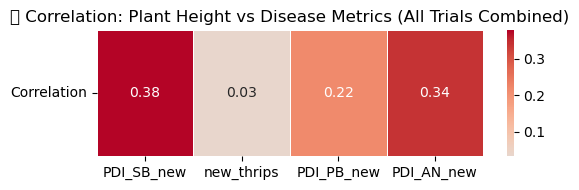

In [21]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

# ----------------------------------------
# Step 1: Flatten combined_data
# ----------------------------------------
flat_data = []

for trial_name, trial_data in combined_data.items():
    for region, entries in trial_data.items():  # region maps to list of dicts
        for entry in entries:
            flat_entry = {
                'Trial': trial_name,
                'Region': region,
                'Date': entry.get('Date')
            }
            for key, val in entry.items():
                if key != 'Date':
                    flat_entry[key] = val
            flat_data.append(flat_entry)

df = pd.DataFrame(flat_data)

# ----------------------------------------
# Step 2: Clean and Filter
# ----------------------------------------
df = df.apply(pd.to_numeric, errors='coerce')
df = df.dropna(subset=['Plant_H'])

# ----------------------------------------
# Step 3: Compute correlations with Plant_H
# ----------------------------------------
target_metrics = ['PDI_SB_new', 'new_thrips', 'PDI_PB_new', 'PDI_AN_new']
corrs = {}

for metric in target_metrics:
    if metric in df.columns:
        x = df['Plant_H'].replace([np.inf, -np.inf], np.nan)
        y = df[metric].replace([np.inf, -np.inf], np.nan)
        valid = x.notna() & y.notna()
        if valid.sum() > 2:
            corr, _ = pearsonr(x[valid], y[valid])
            corrs[metric] = round(corr, 4)

# ----------------------------------------
# Step 4: Plot Heatmap
# ----------------------------------------
corr_df = pd.DataFrame.from_dict(corrs, orient='index', columns=['Correlation'])
plt.figure(figsize=(6, 2))
sns.heatmap(corr_df.T, annot=True, cmap='coolwarm', center=0, fmt=".2f", linewidths=0.5)
plt.title("📊 Correlation: Plant Height vs Disease Metrics (All Trials Combined)", fontsize=12)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()